# Init

In [6]:
!pip install -q huggingface_hub
!pip -q install -U unsloth transformers accelerate sentencepiece evaluate bert-score rouge_score


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.3/76.3 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 165.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 130.3 MB/s eta 0:00:00
   ━━━━━━━━

In [1]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from google.colab import userdata
gmail_pwd = userdata.get('GMAIL')

def send_training_complete_email(
    sender_email,
    sender_password,
    receiver_email,
    subject="Model Training Complete",
    message="Your model training has finished successfully."
):
    msg = MIMEMultipart()
    msg["From"] = sender_email
    msg["To"] = receiver_email
    msg["Subject"] = subject

    msg.attach(MIMEText(message, "plain"))

    try:
        server = smtplib.SMTP("smtp.gmail.com", 587)
        server.starttls()
        server.login(sender_email, sender_password)
        server.send_message(msg)
        server.quit()

        print("Notification email sent successfully!")

    except Exception as e:
        print("Failed to send email:", e)

In [2]:
from transformers.utils import logging as hf_logging
import warnings

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=FutureWarning)

In [7]:
import unsloth
import evaluate

from unsloth import FastLanguageModel
from huggingface_hub import login
from google.colab import userdata
import torch

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)


/usr/local/lib/python3.13/dist-packages/unsloth/__init__.py:1531: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


Exception: cannot import name 'is_jmespath_available' from 'transformers.utils' (/usr/local/lib/python3.13/dist-packages/transformers/utils/__init__.py)

In [ ]:
import os, textwrap, pathlib, subprocess
from google.colab import userdata
HF_TOKEN = userdata.get("HF_TOKEN")
assert HF_TOKEN, "HF_TOKEN missing in Colab Secrets"

# 1) Create a tiny askpass script that prints credentials for git
askpass_path = "/content/git_askpass.sh"
pathlib.Path(askpass_path).write_text(textwrap.dedent("""\
#!/bin/sh
case "$1" in
  *Username*) echo "hf_user" ;;
  *Password*) echo "$HF_TOKEN" ;;
  *) echo "" ;;
esac
"""))
subprocess.run(["chmod", "+x", askpass_path], check=True)

# 2) Export env vars for this session
os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["GIT_ASKPASS"] = askpass_path
os.environ["GIT_TERMINAL_PROMPT"] = "0"

# 3) Now git clone works (private repo)
subprocess.run(["rm", "-rf", "urban_planning_llm"])
subprocess.run(["git", "clone", "https://huggingface.co/datasets/UlyssesLynne/urban_planning_llm"], check=True)


In [ ]:
import pandas as pd
# Metadata
data_folder = "/content/urban_planning_llm"
datasets = {
    "highD_instructions": "highD_instructions_final.json",
    "ngsim_instructions": "ngsim_instructions_final.json",
    "road_network_instructions": "road_networks_instructions_final.json",
    "tlc_trip_instructions": "tlc_trip_instructions_final.json",
    "urban_flow_prediction_survey_instructions": "urban_flow_prediction_survey_instructions_final.json"
}
MODEL_REGISTRY = {
    "llama3": {
        "8b":  "meta-llama/Meta-Llama-3.1-8B-Instruct",
        "70b": "meta-llama/Meta-Llama-3.1-70B-Instruct",
    },
    "qwen": {
        "7b":  "Qwen/Qwen2.5-7B-Instruct",
        "14b": "Qwen/Qwen2.5-14B-Instruct",
    },
    "t5": {
        "base":  "t5-base",
        "large": "t5-large",
    },
    "bert": {
        "base":  "google-bert/bert-base-uncased",
        "large": "google-bert/bert-large-uncased",
    },
}

# Prepare Dataset

In [4]:
# Read Instructions
import json

def read_instructions(file_path):
    with open(file_path, 'r') as file:
        instructions = json.load(file)
    return instructions["instructions"]

def get_instruction_list(file_path):
  instruction_list = read_instructions(file_path)
  mc_def = read_instructions(f"{data_folder}/{datasets['highD_instructions']}")[0]["Task_Definition"]
  mc_pos = instruction_list[0]["Positive Example"]
  mc_neg = instruction_list[0]["Negative Example"]
  sa_def = read_instructions(f"{data_folder}/{datasets['highD_instructions']}")[1]["Task_Definition"]
  sa_pos = instruction_list[1]["Positive Example"]
  sa_neg = instruction_list[1]["Negative Example"]

  return {"mc_task_def": mc_def, "mc_pos": mc_pos, "mc_neg": mc_neg, "sa_task_def": sa_def, "sa_pos":sa_pos, "sa_neg":sa_neg}

def read_all_instructions():
  result = []
  for i in datasets:
    result.append(get_instruction_list(f"{data_folder}/{datasets[i]}"))
  return result

def merge_instructions(json_list):
  mc_task_def = json_list[0]["mc_task_def"]
  sa_task_def = json_list[0]["sa_task_def"]

  mc_pos = []
  mc_neg = []
  sa_pos = []
  sa_neg = []

  for i in range(len(json_list)):
    mc_pos += json_list[i]["mc_pos"]
    mc_neg += json_list[i]["mc_neg"]
    sa_pos += json_list[i]["sa_pos"]
    sa_neg += json_list[i]["sa_neg"]
  return {
      "mc_task_def": mc_task_def,
      "sa_task_def": sa_task_def,
      "mc_pos": mc_pos,
      "mc_neg": mc_neg,
      "sa_pos": sa_pos,
      "sa_neg": sa_neg
  }


In [5]:
json_list = read_all_instructions()
full_dataset = merge_instructions(json_list)

NameError: name 'datasets' is not defined

## Check things

In [ ]:
print(len(json_list[0]["mc_pos"]))

1315


In [ ]:
print(json_list[0]["mc_pos"][0])

{'Fact': 'The highD dataset is collected from six drone-monitored German highways.', 'Question': 'Where was the highD dataset collected?', 'Selections': {'A': 'Urban streets in New York City', 'B': 'Six highway locations in Germany', 'C': 'Rural roads in France', 'D': 'Freeways in California'}, 'Output': 'B', 'Explanation': 'The highD dataset was collected from six drone-monitored German highways.', 'Level': 1}


In [ ]:
print(len(full_dataset["mc_pos"]))

6575


In [ ]:
import json

mc_pos = full_dataset["mc_pos"] + full_dataset["mc_neg"] + full_dataset["sa_pos"] + full_dataset["sa_neg"]

# Compute lengths
lengths = [len(json.dumps(item)) for item in mc_pos]

# Get index of longest
longest_index = lengths.index(max(lengths))

print("Longest index:", longest_index)
print("Max length:", lengths[longest_index])

Longest index: 17249
Max length: 1271


# Testing Functions

In [ ]:
# @title
# Model Loading and Training
import torch
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification,
)
def load_model_and_tokenizer(
    family: str,
    size: str,
    *,
    max_seq_length: int = 2048,
    dtype: str = "bfloat16",
    load_in_4bit: bool = True,
    bert_head: str = "base",
    num_labels: int = 2,
):
    """
    Returns exactly ONE (model, tokenizer) pair.
    """

    family = family.lower()
    size = size.lower()

    if family not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model family: {family}")
    if size not in MODEL_REGISTRY[family]:
        raise ValueError(f"Unknown size '{size}' for family '{family}'")

    model_name = MODEL_REGISTRY[family][size]

    dtype_map = {
        "bfloat16": torch.bfloat16,
        "float16": torch.float16,
        "float32": torch.float32,
    }
    torch_dtype = dtype_map.get(dtype, None)

    # ---- Decoder-only: LLaMA / Qwen ----
    if family in {"llama3", "qwen"}:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=model_name,
            max_seq_length=max_seq_length,
            dtype=torch_dtype,
            load_in_4bit=load_in_4bit,
        )
        FastLanguageModel.for_inference(model)
        return model, tokenizer

    # ---- Seq2Seq: T5 ----
    if family == "t5":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForSeq2SeqLM.from_pretrained(
            model_name,
            torch_dtype=torch_dtype,
            device_map="auto",
        )
        return model, tokenizer

    # ---- Encoder-only: BERT ----
    if family == "bert":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

        if bert_head == "classification":
            model = AutoModelForSequenceClassification.from_pretrained(
                model_name,
                num_labels=num_labels,
                torch_dtype=torch_dtype,
                device_map="auto",
            )
        else:
            model = AutoModel.from_pretrained(
                model_name,
                torch_dtype=torch_dtype,
                device_map="auto",
            )
        return model, tokenizer


In [ ]:
import re
import torch
from typing import Dict, List, Any, Tuple


def _build_generative_prompt(task_def: str, ex: Dict[str, Any], model_family: str) -> str:
    """
    Prompt builder for T5 / LLaMA / Qwen generative models.
    """
    fact = ex.get("Fact", "").strip()
    q = ex["Question"].strip()
    sels = ex["Selections"]

    choices = " ".join(
        [f"({k}) {sels[k].strip()}" for k in ["A", "B", "C", "D"] if k in sels]
    )

    if model_family == "t5":
        # T5 generally prefers shorter, more direct prompts for the answer
        # The prompt needs to be even more direct to prevent verbose outputs.
        prompt = "Please select the correct option. Your answer must be a single letter (A, B, C, or D).\n"
        if fact:
            prompt += f"Fact: {fact}\n"
        prompt += f"Question: {q}\n"
        prompt += f"Options: {choices}\n"
        prompt += "Answer:"

    else:
        # Good for LLaMA / Qwen
        prompt = (
            f"Task definition:\n{task_def}\n"
            f"Fact: {fact}\n\n"
            f"Question: {q}\n"
            f"Choices: {choices}\n\n"
            "Answer:\n"
        )

    return prompt


def _build_mc_context_and_choices(task_def: str, ex: Dict[str, Any]) -> Tuple[str, List[str]]:
    """
    Builder for BERT / RoBERTa multiple-choice models.
    """
    context = (
        f"Task definition: {task_def}\n"
        f"Fact: {fact}\n"
        f"Question: {q}"
    )
    choices = [sels[k].strip() for k in ["A", "B", "C", "D"]]
    return context, choices


def _extract_letter(text: str) -> str:
    """
    Extract the first standalone A/B/C/D from the text, prioritizing common answer patterns.
    """
    original_text = text.strip().upper()

    # Attempt to clean the text by removing common verbose prefixes
    cleaned_text = original_text
    prefixes_to_remove = [
        "THE BEST ANSWER IS",
        "ANSWER:",
        "THE ANSWER IS",
        "OPTION:",
        "IS",
        "RESPONSE:",
        "SELECTION:",
        "FINAL ANSWER:",
        "ACCORDINGLY:",
    ]
    for prefix in prefixes_to_remove:
        if cleaned_text.startswith(prefix.upper().strip()):
            cleaned_text = cleaned_text[len(prefix.upper().strip()):].strip()
            break # Remove only the first matched prefix

    # First, try to find a standalone letter at the beginning of the cleaned text
    m = re.search(r"^\s*([ABCD])(?:\b|\.|[\s,;]|$)", cleaned_text)
    if m:
        return m.group(1)

    # If not found in cleaned text, try more general standalone letter in original text
    m = re.search(r"\b([ABCD])(?:\b|\.|[\s,;]|$)", original_text)
    if m:
        return m.group(1)

    # As a last resort, check the very first character if it's a letter
    if original_text and original_text[0] in {"A", "B", "C", "D"}:
        return original_text[0]

    return ""


def _infer_model_mode(model) -> str:
    """
    Returns one of:
      - 'seq2seq' for T5
      - 'causal' for LLaMA / Qwen
      - 'multiple_choice' for BERT / RoBERTa with MC head
    """
    config = model.config

    if getattr(config, "is_encoder_decoder", False):
        return "seq2seq"

    archs = getattr(config, "architectures", None) or []
    archs_text = " ".join(archs).lower()

    if "multiplechoice" in archs_text:
        return "multiple_choice"

    model_type = getattr(config, "model_type", "").lower()
    cls_name = model.__class__.__name__.lower()
    if "multiplechoice" in cls_name:
        return "multiple_choice"

    if model_type in {"t5", "mt5"}:
        return "seq2seq"

    if model_type in {"llama", "qwen2", "qwen2_5", "mistral", "gemma", "phi", "falcon"}:
        return "causal"

    if "conditionalgeneration" in cls_name:
        return "seq2seq"

    if "causallm" in cls_name:
        return "causal"

    raise ValueError(
        f"Unsupported or unknown model type. "
        f"model_type={model_type}, class={model.__class__.__name__}, architectures={archs}"
    )


def _infer_model_family(model) -> str:
    """
    Used only for prompt formatting.
    """
    model_type = getattr(model.config, "model_type", "").lower()
    if "t5" in model_type:
        return "t5"
    if "llama" in model_type:
        return "llama"
    if "qwen" in model_type:
        return "qwen"
    return "generic"


def _predict_batch_generative(
    task_def: str,
    model,
    tokenizer,
    examples: List[Dict[str, Any]],
    max_new_tokens: int = 4,
    verbose: bool = False, # NEW: Added verbose parameter
) -> List[str]:
    """
    For T5 / LLaMA / Qwen.
    """
    model_family = _infer_model_family(model)
    mode = _infer_model_mode(model)

    prompts = [_build_generative_prompt(task_def, ex, model_family) for ex in examples]

    device = next(model.parameters()).device
    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    preds = []
    for i, prompt in enumerate(prompts):
        decoded = tokenizer.decode(outputs[i], skip_special_tokens=True).strip()

        if mode == "causal":
            # causal models often return prompt + generation
            gen_part = decoded[len(prompt):].strip() if decoded.startswith(prompt) else decoded
        else:
            # T5 returns generation only
            gen_part = decoded

        if verbose: # NEW: Conditional print
            print(f"Input Prompt: '{prompt}'")
            print(f"Raw output: '{gen_part}'") # Changed 'Raw T5 output' to 'Raw output'

        preds.append(_extract_letter(gen_part))

    return preds


def _predict_batch_multiple_choice(
    task_def: str,
    model,
    tokenizer,
    examples: List[Dict[str, Any]],
) -> List[str]:
    """
    For BERT / RoBERTa multiple-choice models.
    Requires AutoModelForMultipleChoice or equivalent fine-tuned checkpoint.
    """
    device = next(model.parameters()).device

    first_sentences = []
    second_sentences = []

    for ex in examples:
        context, choices = _build_mc_context_and_choices(task_def, ex)
        first_sentences.extend([context] * 4)
        second_sentences.extend(choices)

    encoded = tokenizer(
        first_sentences,
        second_sentences,
        return_tensors="pt",
        padding=True,
        truncation=True,
    )

    batch_size = len(examples)
    num_choices = 4

    model_inputs = {
        k: v.view(batch_size, num_choices, -1).to(device)
        for k, v in encoded.items()
    }

    with torch.no_grad():
        outputs = model(**model_inputs)
        logits = outputs.logits
        pred_ids = torch.argmax(logits, dim=1).tolist()

    id2label = {0: "A", 1: "B", 2: "C", 3: "D"}
    return [id2label[i] for i in pred_ids]


def mc_predict_batch(
    task_def: str,
    model,
    tokenizer,
    examples: List[Dict[str, Any]],
    batch_size: int = 4,
    max_new_tokens: int = 4,
    verbose: bool = False, # NEW: Added verbose parameter
) -> Tuple[int, int, int, int, int]:
    """
    Returns:
      all_correct, level1_correct, level1_cnt, level2_correct, level2_cnt
    """
    mode = _infer_model_mode(model)

    if mode in {"causal", "seq2seq"}:
        preds = _predict_batch_generative(
            task_def=task_def,
            model=model,
            tokenizer=tokenizer,
            examples=examples,
            max_new_tokens=max_new_tokens,
            verbose=verbose, # NEW: Pass verbose
        )
    elif mode == "multiple_choice":
        preds = _predict_batch_multiple_choice(
            task_def=task_def,
            model=model,
            tokenizer=tokenizer,
            examples=examples,
        )
    else:
        raise ValueError(f"Unsupported model mode: {mode}")

    gold_labels = [ex["Output"] for ex in examples]

    all_correct = 0
    level1_cnt = 0
    level2_cnt = 0
    level1_correct = 0
    level2_correct = 0

    for i in range(len(examples)):
        if examples[i]["Level"] == 1:
            level1_cnt += 1
            if preds[i] == gold_labels[i]:
                level1_correct += 1
        elif examples[i]["Level"] == 2:
            level2_cnt += 1
            if preds[i] == gold_labels[i]:
                level2_correct += 1

        if preds[i] == gold_labels[i]:
            all_correct += 1

    return all_correct, level1_correct, level1_cnt, level2_correct, level2_cnt


def predict_all(model, tokenizer, task_def, instructions, batch_size=64, max_new_tokens=4, verbose: bool = False): # NEW: Added verbose parameter
    """
    Same calling style as your current usage:
        predict_all(model, tokenizer, task_def, instructions, batch_size=64)
    """
    total_correct = 0
    total_level1_correct = 0
    total_level1_cnt = 0
    total_level2_correct = 0
    total_level2_cnt = 0

    if verbose: # NEW: Conditional print
        print(model.config)

    for i in range(0, len(instructions), batch_size):
        examples = instructions[i : i + batch_size]

        correct_predictions, level1_correct, level1_cnt, level2_correct, level2_cnt = mc_predict_batch(
            task_def=task_def,
            model=model,
            tokenizer=tokenizer,
            examples=examples,
            batch_size=batch_size,
            max_new_tokens=max_new_tokens,
            verbose=verbose, # NEW: Pass verbose
        )

        total_correct += correct_predictions
        total_level1_correct += level1_correct
        total_level1_cnt += level1_cnt
        total_level2_correct += level2_correct
        total_level2_cnt += level2_cnt

    total_accuracy = total_correct / len(instructions) if len(instructions) > 0 else 0.0
    l1_accuracy = total_level1_correct / total_level1_cnt if total_level1_cnt != 0 else 0.0
    l2_accuracy = total_level2_correct / total_level2_cnt if total_level2_cnt != 0 else 0.0

    return total_accuracy, l1_accuracy, l2_accuracy

In [ ]:
import os
import json
import gc
import re
import tempfile
from typing import Dict, List, Any, Optional

import torch
import pandas as pd
from tqdm.auto import tqdm
from huggingface_hub import HfApi, login

# assumes globally:
import evaluate
_rouge = evaluate.load("rouge")
_bertscore = evaluate.load("bertscore")


# -------------------------
# Model helpers
# -------------------------
def _infer_sa_model_mode(model) -> str:
    """
    Returns one of:
      - 'seq2seq'       : T5 / Flan-T5 / mT5
      - 'causal'        : LLaMA / Qwen / causal LM families
      - 'extractive_qa' : BERT / RoBERTa / DistilBERT with QA head
    """
    config = model.config
    model_type = getattr(config, "model_type", "").lower()
    cls_name = model.__class__.__name__.lower()
    archs = getattr(config, "architectures", None) or []
    archs_text = " ".join(archs).lower()
    is_enc_dec = getattr(config, "is_encoder_decoder", False)

    if is_enc_dec:
        return "seq2seq"

    if "questionanswering" in archs_text or "questionanswering" in cls_name:
        return "extractive_qa"

    if model_type in {"llama", "qwen2", "qwen2_5", "mistral", "gemma", "phi", "falcon"}:
        return "causal"

    if "causallm" in cls_name:
        return "causal"

    if model_type in {"bert", "roberta", "distilbert", "albert", "deberta"}:
        # only valid if loaded with QA head
        if hasattr(model, "qa_outputs") or "questionanswering" in cls_name:
            return "extractive_qa"

    raise ValueError(
        f"Unsupported SA model type. "
        f"model_type={model_type}, class={model.__class__.__name__}, architectures={archs}"
    )


def _infer_model_family(model) -> str:
    model_type = getattr(model.config, "model_type", "").lower()
    if "t5" in model_type:
        return "t5"
    if "llama" in model_type:
        return "llama"
    if "qwen" in model_type:
        return "qwen"
    if model_type in {"bert", "roberta", "distilbert", "albert", "deberta"}:
        return "bert_like"
    return "generic"


# -------------------------
# Prompt + postprocessing
# -------------------------
def _build_sa_prompt(task_def: str, ex: Dict[str, Any], model_family: str = "generic") -> str:
    fact = str(ex.get("Fact", "")).strip()
    q = str(ex.get("Question", "")).strip()

    if model_family == "t5":
        # shorter prompt for T5
        prompt = f"qa: task: {task_def} "
        if fact:
            prompt += f"context: {fact} "
        prompt += f"question: {q} answer:"
        return prompt

    prompt = f"Task definition:\n{task_def}\n"
    if fact:
        prompt += f"Fact: {fact}\n\n"
    prompt += f"Question: {q}\n\nAnswer:\n"
    return prompt


def _postprocess_sa(gen_text: str) -> str:
    t = gen_text.strip()

    # Remove everything after "Note:"
    note_idx = t.find("Note:")
    if note_idx != -1:
        t = t[:note_idx].strip()

    for prefix in ["Answer:", "answer:", "A:", "Ans:", "ANS:"]:
        if t.startswith(prefix):
            t = t[len(prefix):].strip()

    if "\n" in t:
        t = t.split("\n", 1)[0].strip()

    return t.strip().strip('"').strip("'").strip()


def _extract_sa_from_generation(decoded: str, prompt: str, mode: str) -> str:
    """
    causal  -> decoded may contain prompt + answer
    seq2seq -> decoded is usually answer only
    """
    if mode == "causal":
        gen = decoded[len(prompt):] if decoded.startswith(prompt) else decoded
    else:
        gen = decoded
    return _postprocess_sa(gen)


# -------------------------
# BERT / extractive QA helpers
# -------------------------
def _extract_answer_from_qa_logits(
    start_logits: torch.Tensor,
    end_logits: torch.Tensor,
    input_ids: torch.Tensor,
    offset_mapping,
    sequence_ids_fn,
    context: str,
    tokenizer,
    max_answer_len: int = 32,
) -> str:
    """
    Extract best answer span from one QA example.
    """
    start_logits = start_logits.detach().cpu()
    end_logits = end_logits.detach().cpu()

    best_score = float("-inf")
    best_text = ""

    seq_ids = sequence_ids_fn()

    # Only allow answer span inside context tokens
    context_token_idxs = [
        i for i, sid in enumerate(seq_ids)
        if sid == 1 and offset_mapping[i] is not None
    ]

    if not context_token_idxs:
        return ""

    for s in context_token_idxs:
        s_char = offset_mapping[s]
        if s_char is None:
            continue

        max_end = min(s + max_answer_len, len(offset_mapping))
        for e in range(s, max_end):
            if e not in context_token_idxs:
                continue
            e_char = offset_mapping[e]
            if e_char is None:
                continue
            if e < s:
                continue

            score = float(start_logits[s] + end_logits[e])
            if score > best_score:
                start_char = s_char[0]
                end_char = e_char[1]
                best_text = context[start_char:end_char]
                best_score = score

    return _postprocess_sa(best_text)


def _predict_batch_extractive_qa(
    model,
    tokenizer,
    examples: List[Dict[str, Any]],
    max_input_tokens: int = 2048,
    max_answer_len: int = 32,
) -> List[str]:
    """
    For BERT/RoBERTa QA models.
    Requires Fact to act as context.
    """
    device = next(model.parameters()).device
    preds = []

    for ex in examples:
        context = str(ex.get("Fact", "")).strip()
        question = str(ex.get("Question", "")).strip()

        if not context:
            preds.append("")
            continue

        encoded = tokenizer(
            question,
            context,
            return_tensors="pt",
            truncation="only_second",
            max_length=max_input_tokens,
            return_offsets_mapping=True,
            padding=False,
        )

        offset_mapping = encoded.pop("offset_mapping")[0].tolist()

        model_inputs = {k: v.to(device) for k, v in encoded.items()}

        with torch.inference_mode():
            outputs = model(**model_inputs)

        pred_text = _extract_answer_from_qa_logits(
            start_logits=outputs.start_logits[0],
            end_logits=outputs.end_logits[0],
            input_ids=model_inputs["input_ids"][0],
            offset_mapping=offset_mapping,
            sequence_ids_fn=lambda: encoded.sequence_ids(0),
            context=context,
            tokenizer=tokenizer,
            max_answer_len=max_answer_len,
        )
        preds.append(pred_text)

        del model_inputs, outputs
        torch.cuda.empty_cache()
        gc.collect()

    return preds


def _predict_batch_generative_sa(
    model,
    tokenizer,
    task_def: str,
    examples: List[Dict[str, Any]],
    max_new_tokens: int = 64,
    max_input_tokens: int = 2048,
    use_cache: bool = True,
) -> (List[str], List[str]):
    """
    For T5 / LLaMA / Qwen.
    Returns (preds, prompts)
    """
    mode = _infer_sa_model_mode(model)
    model_family = _infer_model_family(model)
    device = next(model.parameters()).device

    prompts = [_build_sa_prompt(task_def, ex, model_family=model_family) for ex in examples]

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_input_tokens,
    ).to(device)

    generate_kwargs = dict(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        use_cache=use_cache,
    )

    with torch.inference_mode():
        outputs = model.generate(**generate_kwargs)

    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    preds = [_extract_sa_from_generation(d, p, mode) for d, p in zip(decoded, prompts)]
    return preds, prompts


# -------------------------
# Metrics helpers
# -------------------------
def _compute_metrics_agg_sa(
    preds_: List[str],
    refs_: List[str],
    *,
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
) -> Dict[str, Any]:
    rouge = _rouge.compute(predictions=preds_, references=refs_)
    rouge = {k: float(v) for k, v in rouge.items()}

    bs_kwargs = {"lang": bert_lang}
    if bertscore_model_type is not None:
        bs_kwargs["model_type"] = bertscore_model_type

    bs = _bertscore.compute(predictions=preds_, references=refs_, **bs_kwargs)
    f1_list = [float(x) for x in bs["f1"]]
    f1_avg = sum(f1_list) / max(len(f1_list), 1)

    return {
        "count": len(preds_),
        "rouge": rouge,
        "bert_f1_avg": float(f1_avg),
    }


def _compute_metrics_per_example_sa(
    preds_: List[str],
    refs_: List[str],
    *,
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
) -> Dict[str, Any]:
    rouge_pe = _rouge.compute(
        predictions=preds_,
        references=refs_,
        use_aggregator=False,
    )
    rouge_pe = {k: [float(x) for x in v] for k, v in rouge_pe.items()}

    bs_kwargs = {"lang": bert_lang}
    if bertscore_model_type is not None:
        bs_kwargs["model_type"] = bertscore_model_type

    bs = _bertscore.compute(predictions=preds_, references=refs_, **bs_kwargs)
    bs_pe = {
        "precision": [float(x) for x in bs["precision"]],
        "recall": [float(x) for x in bs["recall"]],
        "f1": [float(x) for x in bs["f1"]],
    }

    return {"rouge": rouge_pe, "bertscore": bs_pe}


# -------------------------
# Uploading SA eval runner
# -------------------------
def sa_predict_eval_batch_and_upload(
    model,
    tokenizer,
    task_def: str,
    examples: List[Dict[str, Any]],
    *,
    split_name: str,
    hf_repo_id: str,
    model_subdir: str,
    batch_size: int = 4,
    max_new_tokens: int = 64,
    max_input_tokens: int = 2048,
    max_answer_len: int = 32,   # for BERT QA
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
    use_cache: bool = True,
    hf_token: Optional[str] = None,
    commit_message: Optional[str] = None,
    extra_summary: Optional[Dict[str, Any]] = None,
    save_prompt_text: bool = True,
) -> Dict[str, Dict[str, Any]]:
    """
    Supports:
      - T5 / LLaMA / Qwen (generative)
      - BERT / RoBERTa QA (extractive)

    Uploads:
      - predictions.parquet
      - predictions.jsonl
      - summary.json
    """
    model.eval()
    mode = _infer_sa_model_mode(model)

    refs = [str(ex.get("Output", "")).strip() for ex in examples]
    preds: List[str] = []
    prompts: List[str] = []

    num_batches = (len(examples) + batch_size - 1) // batch_size

    if mode in {"seq2seq", "causal"}:
        for i in tqdm(
            range(0, len(examples), batch_size),
            total=num_batches,
            desc=f"Generating SA ({split_name})",
        ):
            batch_examples = examples[i : i + batch_size]

            batch_preds, batch_prompts = _predict_batch_generative_sa(
                model=model,
                tokenizer=tokenizer,
                task_def=task_def,
                examples=batch_examples,
                max_new_tokens=max_new_tokens,
                max_input_tokens=max_input_tokens,
                use_cache=use_cache,
            )

            preds.extend(batch_preds)
            prompts.extend(batch_prompts)

            torch.cuda.empty_cache()
            gc.collect()

    elif mode == "extractive_qa":
        for i in tqdm(
            range(0, len(examples), batch_size),
            total=num_batches,
            desc=f"Extracting SA ({split_name})",
        ):
            batch_examples = examples[i : i + batch_size]

            batch_preds = _predict_batch_extractive_qa(
                model=model,
                tokenizer=tokenizer,
                examples=batch_examples,
                max_input_tokens=max_input_tokens,
                max_answer_len=max_answer_len,
            )

            preds.extend(batch_preds)

            # keep a text field analogous to prompt for traceability
            if save_prompt_text:
                for ex in batch_examples:
                    context = str(ex.get("Fact", "")).strip()
                    question = str(ex.get("Question", "")).strip()
                    prompts.append(f"Context: {context}\nQuestion: {question}")
            else:
                prompts.extend([""] * len(batch_examples))

            torch.cuda.empty_cache()
            gc.collect()

    else:
        raise ValueError(f"Unsupported SA mode: {mode}")

    # -------------------------
    # Aggregate metrics
    # -------------------------
    results: Dict[str, Dict[str, Any]] = {
        "overall": _compute_metrics_agg_sa(
            preds,
            refs,
            bert_lang=bert_lang,
            bertscore_model_type=bertscore_model_type,
        )
    }

    level_indices: Dict[int, List[int]] = {}
    for idx, ex in enumerate(examples):
        lvl = ex.get("Level", None)
        if lvl is not None:
            level_indices.setdefault(int(lvl), []).append(idx)

    for lvl, idxs in sorted(level_indices.items()):
        lvl_preds = [preds[k] for k in idxs]
        lvl_refs = [refs[k] for k in idxs]
        results[f"level_{lvl}"] = _compute_metrics_agg_sa(
            lvl_preds,
            lvl_refs,
            bert_lang=bert_lang,
            bertscore_model_type=bertscore_model_type,
        )

    # -------------------------
    # Per-example metrics + table
    # -------------------------
    per_ex = _compute_metrics_per_example_sa(
        preds,
        refs,
        bert_lang=bert_lang,
        bertscore_model_type=bertscore_model_type,
    )

    rows: List[Dict[str, Any]] = []
    for i, ex in enumerate(examples):
        row = {
            "i": int(i),
            "Level": ex.get("Level", None),
            "Fact": ex.get("Fact", ""),
            "Question": ex.get("Question", ""),
            "Output": ex.get("Output", ""),
            "reference": refs[i],
            "prediction": preds[i],
            "rouge1": per_ex["rouge"]["rouge1"][i],
            "rouge2": per_ex["rouge"]["rouge2"][i],
            "rougeL": per_ex["rouge"]["rougeL"][i],
            "rougeLsum": per_ex["rouge"]["rougeLsum"][i],
            "bert_precision": per_ex["bertscore"]["precision"][i],
            "bert_recall": per_ex["bertscore"]["recall"][i],
            "bert_f1": per_ex["bertscore"]["f1"][i],
        }
        if save_prompt_text:
            row["prompt"] = prompts[i]
        rows.append(row)

    df = pd.DataFrame(rows)

    # -------------------------
    # Upload to HF dataset repo
    # -------------------------
    if hf_token:
        login(token=hf_token)

    api = HfApi()
    base_path = f"{model_subdir.strip('/')}/{split_name.strip('/')}"

    if commit_message is None:
        commit_message = f"Add SA predictions + metrics for {base_path}"

    summary_obj: Dict[str, Any] = {
        "repo_id": hf_repo_id,
        "model_subdir": model_subdir,
        "split_name": split_name,
        "model_mode": mode,
        "model_family": _infer_model_family(model),
        "overall": results["overall"],
        "by_level": {k: v for k, v in results.items() if k.startswith("level_")},
        "n_rows": int(len(df)),
        "bert_lang": bert_lang,
        "bertscore_model_type": bertscore_model_type,
        "max_new_tokens": int(max_new_tokens),
        "max_input_tokens": int(max_input_tokens),
        "max_answer_len": int(max_answer_len),
        "batch_size": int(batch_size),
        "use_cache": bool(use_cache),
        "save_prompt_text": bool(save_prompt_text),
    }
    if extra_summary:
        summary_obj.update(extra_summary)

    with tempfile.TemporaryDirectory() as td:
        parquet_path = os.path.join(td, "predictions.parquet")
        jsonl_path = os.path.join(td, "predictions.jsonl")
        summary_path = os.path.join(td, "summary.json")

        df.to_parquet(parquet_path, index=False)

        with open(jsonl_path, "w", encoding="utf-8") as f:
            for r in rows:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")

        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(summary_obj, f, ensure_ascii=False, indent=2)

        api.upload_file(
            path_or_fileobj=parquet_path,
            path_in_repo=f"{base_path}/predictions.parquet",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )
        api.upload_file(
            path_or_fileobj=jsonl_path,
            path_in_repo=f"{base_path}/predictions.jsonl",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )
        api.upload_file(
            path_or_fileobj=summary_path,
            path_in_repo=f"{base_path}/summary.json",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )

    return results


# -------------------------
# Convenience wrapper
# -------------------------
def predict_all_sa_and_upload(
    model,
    tokenizer,
    task_def: str,
    instructions: List[Dict[str, Any]],
    *,
    split_name: str,
    hf_repo_id: str,
    model_subdir: str,
    batch_size: int = 4,
    max_new_tokens: int = 64,
    max_input_tokens: int = 2048,
    max_answer_len: int = 32,
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
    use_cache: bool = True,
    hf_token: Optional[str] = None,
    commit_message: Optional[str] = None,
    extra_summary: Optional[Dict[str, Any]] = None,
    save_prompt_text: bool = True,
) -> Dict[str, Dict[str, Any]]:
    return sa_predict_eval_batch_and_upload(
        model=model,
        tokenizer=tokenizer,
        task_def=task_def,
        examples=instructions,
        split_name=split_name,
        hf_repo_id=hf_repo_id,
        model_subdir=model_subdir,
        batch_size=batch_size,
        max_new_tokens=max_new_tokens,
        max_input_tokens=max_input_tokens,
        max_answer_len=max_answer_len,
        bert_lang=bert_lang,
        bertscore_model_type=bertscore_model_type,
        use_cache=use_cache,
        hf_token=hf_token,
        commit_message=commit_message,
        extra_summary=extra_summary,
        save_prompt_text=save_prompt_text,
    )

In [ ]:
# @title
import os
import json
import gc
import tempfile
from typing import Dict, Any, List, Optional, Tuple

import torch
import pandas as pd
import evaluate
from tqdm.auto import tqdm
from huggingface_hub import HfApi, login

# -------------------------
# Metrics helpers (load once)
# -------------------------
_rouge = evaluate.load("rouge")
_bertscore = evaluate.load("bertscore")


# ============================================================
# Prompt + extraction
# ============================================================
def _build_mc_expl_paraphrase_prompt(ex: Dict[str, Any], task_definition: str) -> str:
    fact = str(ex.get("Fact", "")).strip()
    q = str(ex.get("Question", "")).strip()
    sels = ex.get("Selections", {}) or {}
    ref_expl = str(ex.get("Explanation", "")).strip()

    choices = " ".join(
        [f"({k}) {str(sels[k]).strip()}" for k in ["A", "B", "C", "D"] if k in sels]
    )

    prompt = (
        "Paraphrase the following multiple-choice explanation.\n"
        "Preserve the original meaning, structure, and factual content.\n"
        "Do NOT add or remove information.\n\n"
        f"Task definition:\n{task_definition.strip()}\n\n"
    )
    if fact:
        prompt += f"Fact: {fact}\n\n"
    prompt += (
        f"Question: {q}\n"
        f"Choices: {choices}\n\n"
        f"Explanation:\n{ref_expl}\n\n"
        "Paraphrased explanation:\n"
    )
    return prompt


def _extract_after_prompt(decoded: str, prompt: str, key: str) -> str:
    gen = decoded[len(prompt):] if decoded.startswith(prompt) else decoded
    if key in gen:
        gen = gen.split(key, 1)[-1]
    return gen.strip()


# ============================================================
# Sanitizing helpers (prevents BERTScore crash on empty strings)
# ============================================================
_EMPTY_SENTINEL = "[EMPTY]"

def _sanitize_texts(xs: List[str], sentinel: str = _EMPTY_SENTINEL) -> Tuple[List[str], int]:
    """
    Returns (sanitized_texts, n_empty_original).
    Empty/whitespace/None -> sentinel.
    """
    out = []
    n_empty = 0
    for x in xs:
        s = "" if x is None else str(x)
        s2 = s.strip()
        if not s2:
            n_empty += 1
            out.append(sentinel)
        else:
            out.append(s2)
    return out, n_empty


# ============================================================
# Metrics (aggregate + per-example)
# ============================================================
def _bertscore_compute_safe(
    preds_: List[str],
    refs_: List[str],
    *,
    bert_lang: str,
    bertscore_model_type: Optional[str],
    bertscore_device: Optional[str],
    use_fast_tokenizer: bool = True,   # 👈 added
    sanitize_for_bertscore: bool = True,  # 👈 added
) -> Dict[str, Any]:
    # ---- sanitize to avoid bert-score empty-string path ----
    if sanitize_for_bertscore:
        preds_s, n_empty_pred = _sanitize_texts(preds_)
        refs_s,  n_empty_ref  = _sanitize_texts(refs_)
        if n_empty_pred or n_empty_ref:
            print(f"[WARN] BERTScore sanitize: empty preds={n_empty_pred}, empty refs={n_empty_ref}")
    else:
        preds_s, refs_s = preds_, refs_
        n_empty_pred = n_empty_ref = 0

    bs_kwargs = {"lang": bert_lang, "use_fast_tokenizer": use_fast_tokenizer}
    if bertscore_model_type is not None:
        bs_kwargs["model_type"] = bertscore_model_type
    if bertscore_device is not None:
        bs_kwargs["device"] = bertscore_device

    try:
        out = _bertscore.compute(predictions=preds_s, references=refs_s, **bs_kwargs)
    except TypeError:
        # fallback if this env doesn't accept `device`
        bs_kwargs.pop("device", None)
        out = _bertscore.compute(predictions=preds_s, references=refs_s, **bs_kwargs)

    # Attach debug info (optional but useful)
    out["_sanitize_info"] = {"empty_preds": int(n_empty_pred), "empty_refs": int(n_empty_ref)}
    return out


def _compute_metrics_agg(
    preds_: List[str],
    refs_: List[str],
    *,
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
    bertscore_device: Optional[str] = None,
) -> Dict[str, Any]:
    rouge = _rouge.compute(predictions=preds_, references=refs_)
    rouge = {k: float(v) for k, v in rouge.items()}

    bs = _bertscore_compute_safe(
        preds_,
        refs_,
        bert_lang=bert_lang,
        bertscore_model_type=bertscore_model_type,
        bertscore_device=bertscore_device,
        use_fast_tokenizer=True,
        sanitize_for_bertscore=True,
    )
    f1_list = [float(x) for x in bs["f1"]]
    f1_avg = sum(f1_list) / max(len(f1_list), 1)

    return {
        "count": len(preds_),
        "rouge": rouge,
        "bert_f1_avg": float(f1_avg),
        "bertscore_sanitize": bs.get("_sanitize_info", {}),  # 👈 added
    }


def _compute_metrics_per_example(
    preds_: List[str],
    refs_: List[str],
    *,
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
    bertscore_device: Optional[str] = None,
) -> Dict[str, Any]:
    rouge_pe = _rouge.compute(
        predictions=preds_,
        references=refs_,
        use_aggregator=False,
    )
    rouge_pe = {k: [float(x) for x in v] for k, v in rouge_pe.items()}

    bs = _bertscore_compute_safe(
        preds_,
        refs_,
        bert_lang=bert_lang,
        bertscore_model_type=bertscore_model_type,
        bertscore_device=bertscore_device,
        use_fast_tokenizer=True,
        sanitize_for_bertscore=True,
    )
    bs_pe = {
        "precision": [float(x) for x in bs["precision"]],
        "recall": [float(x) for x in bs["recall"]],
        "f1": [float(x) for x in bs["f1"]],
        "_sanitize_info": bs.get("_sanitize_info", {}),  # 👈 added
    }
    return {"rouge": rouge_pe, "bertscore": bs_pe}


# ============================================================
# MC explanation paraphrase + eval + upload
# ============================================================
def paraphrase_mc_explanation_eval_batch_and_upload(
    model,
    tokenizer,
    examples: List[Dict[str, Any]],
    task_definition: str,
    *,
    split_name: str,
    hf_repo_id: str,
    model_subdir: str,
    batch_size: int = 4,
    max_new_tokens: int = 128,
    max_input_tokens: Optional[int] = None,
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
    bertscore_device: Optional[str] = "cpu",
    use_cache: bool = True,
    hf_token: Optional[str] = None,
    commit_message: Optional[str] = None,
    extra_summary: Optional[Dict[str, Any]] = None,
    save_prompt_text: bool = True,
    debug_tokenizer_drift: bool = True,
    debug_print_every: int = 50,
) -> Dict[str, Dict[str, Any]]:

    def _tok_sig(tok):
        return {
            "type": type(tok).__name__,
            "name_or_path": getattr(tok, "name_or_path", None),
            "id": id(tok),
        }

    def _raise_drift(where: str, before_sig: Dict[str, Any], tok_now):
        now_sig = _tok_sig(tok_now)
        raise RuntimeError(
            "Tokenizer changed unexpectedly!\n"
            f"WHERE: {where}\n"
            f"BEFORE: {before_sig}\n"
            f"NOW:    {now_sig}\n"
        )

    model.eval()
    device = model.device

    tok0 = tokenizer
    tok0_sig = _tok_sig(tok0)

    if debug_tokenizer_drift:
        print(f"[DEBUG entry] split={split_name}")
        print("[DEBUG entry] model:", type(model).__name__, "device=", device)
        print("[DEBUG entry] tokenizer:", tok0_sig)

        tok_cls = tok0_sig["type"].lower()
        tok_path = str(tok0_sig["name_or_path"] or "").lower()
        if "roberta" in tok_cls or "roberta" in tok_path or "bert" in tok_cls:
            raise TypeError(f"Wrong tokenizer passed at entry: {tok0_sig}")

    prompts = [_build_mc_expl_paraphrase_prompt(ex, task_definition) for ex in examples]
    refs = [str(ex.get("Explanation", "")).strip() for ex in examples]
    preds: List[str] = []

    num_batches = (len(prompts) + batch_size - 1) // batch_size

    for batch_idx, i in enumerate(
        tqdm(range(0, len(prompts), batch_size), total=num_batches, desc=f"Generating MC-Expl ({split_name})")
    ):
        if debug_tokenizer_drift:
            if tokenizer is not tok0:
                _raise_drift("before_tokenize", tok0_sig, tokenizer)
            if (batch_idx % max(debug_print_every, 1)) == 0:
                print(f"[DEBUG batch {batch_idx}/{num_batches}] tokenizer still:", _tok_sig(tokenizer))

        batch_prompts = prompts[i : i + batch_size]

        tok_kwargs = dict(return_tensors="pt", padding=True, truncation=True)
        if max_input_tokens is not None:
            tok_kwargs["max_length"] = max_input_tokens

        inputs = tokenizer(batch_prompts, **tok_kwargs).to(device)

        with torch.inference_mode():
            out = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=0.0,
                use_cache=use_cache,
                pad_token_id=getattr(tokenizer, "pad_token_id", None),
            )

        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)

        preds.extend(
            _extract_after_prompt(d, p, key="Paraphrased explanation:")
            for d, p in zip(decoded, batch_prompts)
        )

        del inputs, out, decoded
        torch.cuda.empty_cache()
        gc.collect()

    # ---- (optional) count empties in preds/refs for visibility ----
    n_empty_pred = sum(1 for x in preds if not str(x).strip())
    n_empty_ref  = sum(1 for x in refs  if not str(x).strip())
    if n_empty_pred or n_empty_ref:
        print(f"[WARN] Empty strings detected pre-metrics: preds={n_empty_pred}, refs={n_empty_ref}")

    results: Dict[str, Dict[str, Any]] = {
        "overall": _compute_metrics_agg(
            preds,
            refs,
            bert_lang=bert_lang,
            bertscore_model_type=bertscore_model_type,
            bertscore_device=bertscore_device,
        )
    }

    level_indices: Dict[int, List[int]] = {}
    for idx, ex in enumerate(examples):
        lvl = ex.get("Level", None)
        if lvl is not None:
            level_indices.setdefault(int(lvl), []).append(idx)

    for lvl, idxs in sorted(level_indices.items()):
        lvl_preds = [preds[k] for k in idxs]
        lvl_refs = [refs[k] for k in idxs]
        results[f"level_{lvl}"] = _compute_metrics_agg(
            lvl_preds,
            lvl_refs,
            bert_lang=bert_lang,
            bertscore_model_type=bertscore_model_type,
            bertscore_device=bertscore_device,
        )

    per_ex = _compute_metrics_per_example(
        preds,
        refs,
        bert_lang=bert_lang,
        bertscore_model_type=bertscore_model_type,
        bertscore_device=bertscore_device,
    )

    rows: List[Dict[str, Any]] = []
    for i, ex in enumerate(examples):
        sels = ex.get("Selections", {}) or {}
        row = {
            "i": int(i),
            "Level": ex.get("Level", None),
            "Fact": ex.get("Fact", ""),
            "Question": ex.get("Question", ""),
            "Selections": json.dumps(sels, ensure_ascii=False),
            "Output": ex.get("Output", ""),
            "Explanation": ex.get("Explanation", ""),
            "reference_explanation": refs[i],
            "prediction": preds[i],
            "rouge1": per_ex["rouge"]["rouge1"][i],
            "rouge2": per_ex["rouge"]["rouge2"][i],
            "rougeL": per_ex["rouge"]["rougeL"][i],
            "rougeLsum": per_ex["rouge"]["rougeLsum"][i],
            "bert_precision": per_ex["bertscore"]["precision"][i],
            "bert_recall": per_ex["bertscore"]["recall"][i],
            "bert_f1": per_ex["bertscore"]["f1"][i],
        }
        if save_prompt_text:
            row["prompt"] = prompts[i]
        rows.append(row)

    df = pd.DataFrame(rows)

    if hf_token:
        login(token=hf_token)

    api = HfApi()
    base_path = f"{model_subdir.strip('/')}/{split_name.strip('/')}"

    if commit_message is None:
        commit_message = f"Add MC explanation paraphrase preds+metrics for {base_path}"

    summary_obj: Dict[str, Any] = {
        "repo_id": hf_repo_id,
        "model_subdir": model_subdir,
        "split_name": split_name,
        "task": "mc_explanation_paraphrase",
        "overall": results["overall"],
        "by_level": {k: v for k, v in results.items() if k.startswith("level_")},
        "n_rows": int(len(df)),
        "bert_lang": bert_lang,
        "bertscore_model_type": bertscore_model_type,
        "bertscore_device": bertscore_device,
        "max_new_tokens": int(max_new_tokens),
        "max_input_tokens": (int(max_input_tokens) if max_input_tokens is not None else None),
        "batch_size": int(batch_size),
        "use_cache": bool(use_cache),
        "save_prompt_text": bool(save_prompt_text),
        "empty_pred_count": int(n_empty_pred),  # 👈 added
        "empty_ref_count": int(n_empty_ref),    # 👈 added
    }
    if extra_summary:
        summary_obj.update(extra_summary)

    with tempfile.TemporaryDirectory() as td:
        parquet_path = os.path.join(td, "predictions.parquet")
        jsonl_path = os.path.join(td, "predictions.jsonl")
        summary_path = os.path.join(td, "summary.json")

        df.to_parquet(parquet_path, index=False)

        with open(jsonl_path, "w", encoding="utf-8") as f:
            for r in rows:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")

        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(summary_obj, f, ensure_ascii=False, indent=2)

        api.upload_file(
            path_or_fileobj=parquet_path,
            path_in_repo=f"{base_path}/predictions.parquet",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )
        api.upload_file(
            path_or_fileobj=jsonl_path,
            path_in_repo=f"{base_path}/predictions.jsonl",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )
        api.upload_file(
            path_or_fileobj=summary_path,
            path_in_repo=f"{base_path}/summary.json",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )

    if debug_tokenizer_drift:
        print("[DEBUG done] tokenizer still:", _tok_sig(tokenizer))

    return results


def predict_all_mc_explanation_paraphrases_and_upload(
    model,
    tokenizer,
    instructions: List[Dict[str, Any]],
    task_definition: str,
    *,
    split_name: str,
    hf_repo_id: str,
    model_subdir: str,
    batch_size: int = 4,
    max_new_tokens: int = 128,
    max_input_tokens: Optional[int] = None,
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
    bertscore_device: Optional[str] = "cpu",
    use_cache: bool = True,
    hf_token: Optional[str] = None,
    commit_message: Optional[str] = None,
    extra_summary: Optional[Dict[str, Any]] = None,
    save_prompt_text: bool = True,
) -> Dict[str, Dict[str, Any]]:
    return paraphrase_mc_explanation_eval_batch_and_upload(
        model=model,
        tokenizer=tokenizer,
        examples=instructions,
        task_definition=task_definition,
        split_name=split_name,
        hf_repo_id=hf_repo_id,
        model_subdir=model_subdir,
        batch_size=batch_size,
        max_new_tokens=max_new_tokens,
        max_input_tokens=max_input_tokens,
        bert_lang=bert_lang,
        bertscore_model_type=bertscore_model_type,
        bertscore_device=bertscore_device,
        use_cache=use_cache,
        hf_token=hf_token,
        commit_message=commit_message,
        extra_summary=extra_summary,
        save_prompt_text=save_prompt_text,
    )

In [ ]:
import os
import json
import gc
import tempfile
from typing import Dict, Any, List, Optional, Tuple

import torch
import pandas as pd
import evaluate
from tqdm.auto import tqdm
from huggingface_hub import HfApi, login

# -------------------------
# Metrics helpers (load once)
# -------------------------
_rouge = evaluate.load("rouge")
_bertscore = evaluate.load("bertscore")


# ============================================================
# Model helpers
# ============================================================
def _infer_model_mode(model) -> str:
    """
    Returns:
      - 'seq2seq' for T5 / mT5 / encoder-decoder models
      - 'causal' for LLaMA / Qwen / other causal LMs
    """
    config = model.config
    model_type = getattr(config, "model_type", "").lower()
    cls_name = model.__class__.__name__.lower()

    if getattr(config, "is_encoder_decoder", False):
        return "seq2seq"

    if model_type in {"t5", "mt5"}:
        return "seq2seq"

    if model_type in {"llama", "qwen2", "qwen2_5", "mistral", "gemma", "phi", "falcon"}:
        return "causal"

    if "conditionalgeneration" in cls_name:
        return "seq2seq"

    if "causallm" in cls_name:
        return "causal"

    raise ValueError(
        f"Unsupported model type for MC explanation paraphrase. "
        f"model_type={model_type}, class={model.__class__.__name__}"
    )


def _infer_model_family(model) -> str:
    model_type = getattr(model.config, "model_type", "").lower()

    if "t5" in model_type:
        return "t5"
    if "llama" in model_type:
        return "llama"
    if "qwen" in model_type:
        return "qwen"
    return "generic"


# ============================================================
# Prompt + extraction
# ============================================================
def _build_mc_expl_paraphrase_prompt(
    ex: Dict[str, Any],
    task_definition: str,
    model_family: str = "generic",
) -> str:
    fact = str(ex.get("Fact", "")).strip()
    q = str(ex.get("Question", "")).strip()
    sels = ex.get("Selections", {}) or {}
    ref_expl = str(ex.get("Explanation", "")).strip()

    if model_family == "t5":
        parts = [
            "paraphrase the multiple choice explanation while preserving meaning.",
            f"task: {task_definition.strip()}",
        ]
        if fact:
            parts.append(f"fact: {fact}")
        parts.append(f"question: {q}")
        parts.append(f"A: {str(sels.get('A', '')).strip()}")
        parts.append(f"B: {str(sels.get('B', '')).strip()}")
        parts.append(f"C: {str(sels.get('C', '')).strip()}")
        parts.append(f"D: {str(sels.get('D', '')).strip()}")
        parts.append(f"explanation: {ref_expl}")
        parts.append("paraphrase:")
        return "\n".join(parts)

    choices = " ".join(
        [f"({k}) {str(sels[k]).strip()}" for k in ["A", "B", "C", "D"] if k in sels]
    )

    prompt = (
        "Paraphrase the following multiple-choice explanation.\n"
        "Preserve the original meaning, structure, and factual content.\n"
        "Do NOT add or remove information.\n\n"
        f"Task definition:\n{task_definition.strip()}\n\n"
    )
    if fact:
        prompt += f"Fact: {fact}\n\n"
    prompt += (
        f"Question: {q}\n"
        f"Choices: {choices}\n\n"
        f"Explanation:\n{ref_expl}\n\n"
        "Paraphrased explanation:\n"
    )
    return prompt


def _postprocess_paraphrase(text: str) -> str:
    t = text.strip()

    prefixes = [
        "Paraphrased explanation:",
        "paraphrased explanation:",
        "Paraphrase:",
        "paraphrase:",
        "Answer:",
        "answer:",
    ]
    for p in prefixes:
        if t.startswith(p):
            t = t[len(p):].strip()

    return t.strip().strip('"').strip("'").strip()


def _extract_generated_text(decoded: str, prompt: str, mode: str) -> str:
    """
    causal  -> decoded may include prompt + completion
    seq2seq -> decoded is usually generated text only
    """
    if mode == "causal":
        gen = decoded[len(prompt):] if decoded.startswith(prompt) else decoded
    else:
        gen = decoded

    return _postprocess_paraphrase(gen)


# ============================================================
# Sanitizing helpers (prevents BERTScore crash on empty strings)
# ============================================================
_EMPTY_SENTINEL = "[EMPTY]"

def _sanitize_texts(xs: List[str], sentinel: str = _EMPTY_SENTINEL) -> Tuple[List[str], int]:
    """
    Returns (sanitized_texts, n_empty_original).
    Empty/whitespace/None -> sentinel.
    """
    out = []
    n_empty = 0
    for x in xs:
        s = "" if x is None else str(x)
        s2 = s.strip()
        if not s2:
            n_empty += 1
            out.append(sentinel)
        else:
            out.append(s2)
    return out, n_empty


# ============================================================
# Metrics (aggregate + per-example)
# ============================================================
def _bertscore_compute_safe(
    preds_: List[str],
    refs_: List[str],
    *,
    bert_lang: str,
    bertscore_model_type: Optional[str],
    bertscore_device: Optional[str],
    use_fast_tokenizer: bool = True,
    sanitize_for_bertscore: bool = True,
) -> Dict[str, Any]:
    if sanitize_for_bertscore:
        preds_s, n_empty_pred = _sanitize_texts(preds_)
        refs_s, n_empty_ref = _sanitize_texts(refs_)
        if n_empty_pred or n_empty_ref:
            print(f"[WARN] BERTScore sanitize: empty preds={n_empty_pred}, empty refs={n_empty_ref}")
    else:
        preds_s, refs_s = preds_, refs_
        n_empty_pred = n_empty_ref = 0

    bs_kwargs = {"lang": bert_lang, "use_fast_tokenizer": use_fast_tokenizer}
    if bertscore_model_type is not None:
        bs_kwargs["model_type"] = bertscore_model_type
    if bertscore_device is not None:
        bs_kwargs["device"] = bertscore_device

    try:
        out = _bertscore.compute(predictions=preds_s, references=refs_s, **bs_kwargs)
    except TypeError:
        bs_kwargs.pop("device", None)
        out = _bertscore.compute(predictions=preds_s, references=refs_s, **bs_kwargs)

    out["_sanitize_info"] = {"empty_preds": int(n_empty_pred), "empty_refs": int(n_empty_ref)}
    return out


def _compute_metrics_agg(
    preds_: List[str],
    refs_: List[str],
    *,
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
    bertscore_device: Optional[str] = None,
) -> Dict[str, Any]:
    rouge = _rouge.compute(predictions=preds_, references=refs_)
    rouge = {k: float(v) for k, v in rouge.items()}

    bs = _bertscore_compute_safe(
        preds_,
        refs_,
        bert_lang=bert_lang,
        bertscore_model_type=bertscore_model_type,
        bertscore_device=bertscore_device,
        use_fast_tokenizer=True,
        sanitize_for_bertscore=True,
    )
    f1_list = [float(x) for x in bs["f1"]]
    f1_avg = sum(f1_list) / max(len(f1_list), 1)

    return {
        "count": len(preds_),
        "rouge": rouge,
        "bert_f1_avg": float(f1_avg),
        "bertscore_sanitize": bs.get("_sanitize_info", {}),
    }


def _compute_metrics_per_example(
    preds_: List[str],
    refs_: List[str],
    *,
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
    bertscore_device: Optional[str] = None,
) -> Dict[str, Any]:
    rouge_pe = _rouge.compute(
        predictions=preds_,
        references=refs_,
        use_aggregator=False,
    )
    rouge_pe = {k: [float(x) for x in v] for k, v in rouge_pe.items()}

    bs = _bertscore_compute_safe(
        preds_,
        refs_,
        bert_lang=bert_lang,
        bertscore_model_type=bertscore_model_type,
        bertscore_device=bertscore_device,
        use_fast_tokenizer=True,
        sanitize_for_bertscore=True,
    )
    bs_pe = {
        "precision": [float(x) for x in bs["precision"]],
        "recall": [float(x) for x in bs["recall"]],
        "f1": [float(x) for x in bs["f1"]],
        "_sanitize_info": bs.get("_sanitize_info", {}),
    }
    return {"rouge": rouge_pe, "bertscore": bs_pe}


# ============================================================
# MC explanation paraphrase + eval + upload
# ============================================================
def paraphrase_mc_explanation_eval_batch_and_upload(
    model,
    tokenizer,
    examples: List[Dict[str, Any]],
    task_definition: str,
    *,
    split_name: str,
    hf_repo_id: str,
    model_subdir: str,
    batch_size: int = 4,
    max_new_tokens: int = 128,
    max_input_tokens: Optional[int] = None,
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
    bertscore_device: Optional[str] = "cpu",
    use_cache: bool = True,
    hf_token: Optional[str] = None,
    commit_message: Optional[str] = None,
    extra_summary: Optional[Dict[str, Any]] = None,
    save_prompt_text: bool = True,
    debug_tokenizer_drift: bool = True,
    debug_print_every: int = 50,
) -> Dict[str, Dict[str, Any]]:

    def _tok_sig(tok):
        return {
            "type": type(tok).__name__,
            "name_or_path": getattr(tok, "name_or_path", None),
            "id": id(tok),
        }

    def _raise_drift(where: str, before_sig: Dict[str, Any], tok_now):
        now_sig = _tok_sig(tok_now)
        raise RuntimeError(
            "Tokenizer changed unexpectedly!\n"
            f"WHERE: {where}\n"
            f"BEFORE: {before_sig}\n"
            f"NOW:    {now_sig}\n"
        )

    model.eval()
    device = next(model.parameters()).device
    mode = _infer_model_mode(model)
    model_family = _infer_model_family(model)

    tok0 = tokenizer
    tok0_sig = _tok_sig(tok0)

    if debug_tokenizer_drift:
        print(f"[DEBUG entry] split={split_name}")
        print("[DEBUG entry] model:", type(model).__name__, "device=", device)
        print("[DEBUG entry] mode:", mode, "family:", model_family)
        print("[DEBUG entry] tokenizer:", tok0_sig)

    prompts = [
        _build_mc_expl_paraphrase_prompt(ex, task_definition, model_family=model_family)
        for ex in examples
    ]
    refs = [str(ex.get("Explanation", "")).strip() for ex in examples]
    preds: List[str] = []

    num_batches = (len(prompts) + batch_size - 1) // batch_size

    for batch_idx, i in enumerate(
        tqdm(range(0, len(prompts), batch_size), total=num_batches, desc=f"Generating MC-Expl ({split_name})")
    ):
        if debug_tokenizer_drift:
            if tokenizer is not tok0:
                _raise_drift("before_tokenize", tok0_sig, tokenizer)
            if (batch_idx % max(debug_print_every, 1)) == 0:
                print(f"[DEBUG batch {batch_idx}/{num_batches}] tokenizer still:", _tok_sig(tokenizer))

        batch_prompts = prompts[i : i + batch_size]

        tok_kwargs = dict(return_tensors="pt", padding=True, truncation=True)
        if max_input_tokens is not None:
            tok_kwargs["max_length"] = max_input_tokens

        inputs = tokenizer(batch_prompts, **tok_kwargs).to(device)

        generate_kwargs = dict(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=use_cache,
        )

        if mode == "causal":
            generate_kwargs["pad_token_id"] = getattr(tokenizer, "pad_token_id", None)

        with torch.inference_mode():
            out = model.generate(**generate_kwargs)

        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)

        batch_preds = [
            _extract_generated_text(d, p, mode)
            for d, p in zip(decoded, batch_prompts)
        ]
        preds.extend(batch_preds)

        del inputs, out, decoded
        torch.cuda.empty_cache()
        gc.collect()

    n_empty_pred = sum(1 for x in preds if not str(x).strip())
    n_empty_ref = sum(1 for x in refs if not str(x).strip())
    if n_empty_pred or n_empty_ref:
        print(f"[WARN] Empty strings detected pre-metrics: preds={n_empty_pred}, refs={n_empty_ref}")

    results: Dict[str, Dict[str, Any]] = {
        "overall": _compute_metrics_agg(
            preds,
            refs,
            bert_lang=bert_lang,
            bertscore_model_type=bertscore_model_type,
            bertscore_device=bertscore_device,
        )
    }

    level_indices: Dict[int, List[int]] = {}
    for idx, ex in enumerate(examples):
        lvl = ex.get("Level", None)
        if lvl is not None:
            level_indices.setdefault(int(lvl), []).append(idx)

    for lvl, idxs in sorted(level_indices.items()):
        lvl_preds = [preds[k] for k in idxs]
        lvl_refs = [refs[k] for k in idxs]
        results[f"level_{lvl}"] = _compute_metrics_agg(
            lvl_preds,
            lvl_refs,
            bert_lang=bert_lang,
            bertscore_model_type=bertscore_model_type,
            bertscore_device=bertscore_device,
        )

    per_ex = _compute_metrics_per_example(
        preds,
        refs,
        bert_lang=bert_lang,
        bertscore_model_type=bertscore_model_type,
        bertscore_device=bertscore_device,
    )

    rows: List[Dict[str, Any]] = []
    for i, ex in enumerate(examples):
        sels = ex.get("Selections", {}) or {}
        row = {
            "i": int(i),
            "Level": ex.get("Level", None),
            "Fact": ex.get("Fact", ""),
            "Question": ex.get("Question", ""),
            "Selections": json.dumps(sels, ensure_ascii=False),
            "Output": ex.get("Output", ""),
            "Explanation": ex.get("Explanation", ""),
            "reference_explanation": refs[i],
            "prediction": preds[i],
            "rouge1": per_ex["rouge"]["rouge1"][i],
            "rouge2": per_ex["rouge"]["rouge2"][i],
            "rougeL": per_ex["rouge"]["rougeL"][i],
            "rougeLsum": per_ex["rouge"]["rougeLsum"][i],
            "bert_precision": per_ex["bertscore"]["precision"][i],
            "bert_recall": per_ex["bertscore"]["recall"][i],
            "bert_f1": per_ex["bertscore"]["f1"][i],
        }
        if save_prompt_text:
            row["prompt"] = prompts[i]
        rows.append(row)

    df = pd.DataFrame(rows)

    if hf_token:
        login(token=hf_token)

    api = HfApi()
    base_path = f"{model_subdir.strip('/')}/{split_name.strip('/')}"

    if commit_message is None:
        commit_message = f"Add MC explanation paraphrase preds+metrics for {base_path}"

    summary_obj: Dict[str, Any] = {
        "repo_id": hf_repo_id,
        "model_subdir": model_subdir,
        "split_name": split_name,
        "task": "mc_explanation_paraphrase",
        "model_mode": mode,
        "model_family": model_family,
        "overall": results["overall"],
        "by_level": {k: v for k, v in results.items() if k.startswith("level_")},
        "n_rows": int(len(df)),
        "bert_lang": bert_lang,
        "bertscore_model_type": bertscore_model_type,
        "bertscore_device": bertscore_device,
        "max_new_tokens": int(max_new_tokens),
        "max_input_tokens": (int(max_input_tokens) if max_input_tokens is not None else None),
        "batch_size": int(batch_size),
        "use_cache": bool(use_cache),
        "save_prompt_text": bool(save_prompt_text),
        "empty_pred_count": int(n_empty_pred),
        "empty_ref_count": int(n_empty_ref),
    }
    if extra_summary:
        summary_obj.update(extra_summary)

    with tempfile.TemporaryDirectory() as td:
        parquet_path = os.path.join(td, "predictions.parquet")
        jsonl_path = os.path.join(td, "predictions.jsonl")
        summary_path = os.path.join(td, "summary.json")

        df.to_parquet(parquet_path, index=False)

        with open(jsonl_path, "w", encoding="utf-8") as f:
            for r in rows:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")

        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(summary_obj, f, ensure_ascii=False, indent=2)

        api.upload_file(
            path_or_fileobj=parquet_path,
            path_in_repo=f"{base_path}/predictions.parquet",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )
        api.upload_file(
            path_or_fileobj=jsonl_path,
            path_in_repo=f"{base_path}/predictions.jsonl",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )
        api.upload_file(
            path_or_fileobj=summary_path,
            path_in_repo=f"{base_path}/summary.json",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )

    if debug_tokenizer_drift:
        print("[DEBUG done] tokenizer still:", _tok_sig(tokenizer))

    return results


def predict_all_mc_explanation_paraphrases_and_upload(
    model,
    tokenizer,
    instructions: List[Dict[str, Any]],
    task_definition: str,
    *,
    split_name: str,
    hf_repo_id: str,
    model_subdir: str,
    batch_size: int = 4,
    max_new_tokens: int = 128,
    max_input_tokens: Optional[int] = None,
    bert_lang: str = "en",
    bertscore_model_type: Optional[str] = None,
    bertscore_device: Optional[str] = "cpu",
    use_cache: bool = True,
    hf_token: Optional[str] = None,
    commit_message: Optional[str] = None,
    extra_summary: Optional[Dict[str, Any]] = None,
    save_prompt_text: bool = True,
) -> Dict[str, Dict[str, Any]]:
    return paraphrase_mc_explanation_eval_batch_and_upload(
        model=model,
        tokenizer=tokenizer,
        examples=instructions,
        task_definition=task_definition,
        split_name=split_name,
        hf_repo_id=hf_repo_id,
        model_subdir=model_subdir,
        batch_size=batch_size,
        max_new_tokens=max_new_tokens,
        max_input_tokens=max_input_tokens,
        bert_lang=bert_lang,
        bertscore_model_type=bertscore_model_type,
        bertscore_device=bertscore_device,
        use_cache=use_cache,
        hf_token=hf_token,
        commit_message=commit_message,
        extra_summary=extra_summary,
        save_prompt_text=save_prompt_text,
    )

In [ ]:
# @title
import tempfile
from typing import Dict, Any, List, Optional
import torch
import evaluate
from huggingface_hub import HfApi
# Load metrics ONCE (recommended)
_rouge = evaluate.load("rouge")
_bertscore = evaluate.load("bertscore")

def make_model_subdir_from_adapter(adapter_subfolder: str) -> str:
    """
    adapter_subfolder like: "llama3-8b/20260203-205511/adapter"
    returns:               "llama3-8b/20260203-205511"
    """
    adapter_subfolder = adapter_subfolder.strip("/")
    if adapter_subfolder.endswith("/adapter"):
        return adapter_subfolder[: -len("/adapter")]
    # otherwise drop the last segment
    parts = adapter_subfolder.split("/")
    return "/".join(parts[:-1]) if len(parts) > 1 else adapter_subfolder

from tqdm.auto import tqdm

def paraphrase_block_eval_batch_and_upload(
    model,
    tokenizer,
    reference_blocks: List[Dict[str, Any]],
    *,
    split_name: str,  # e.g. "sa_pos" / "sa_neg"
    split_type: str,
    hf_repo_id: str = "",
    model_subdir: str,  # e.g. "llama3-8b/20260203-205511"
    batch_size: int = 2,
    max_new_tokens: int = 512,
    bert_lang: str = "en",
    hf_token: Optional[str] = None,
    commit_message: Optional[str] = None,
    extra_summary: Optional[Dict[str, Any]] = None,
) -> Dict[str, Dict[str, Any]]:
    """
    Generates paraphrases and uploads:
      - predictions.parquet (pred + reference + per-example ROUGE/BERTScore)
      - predictions.jsonl   (same content, json per line)
      - summary.json        (overall + by-level aggregate metrics + run metadata)

    Upload path:
      {model_subdir}/{split_name}/...
    """

    # -------------------------
    # Helpers
    # -------------------------
    def _serialize_block_sa(b: Dict[str, Any]) -> str:
        return (
            f"Fact: {b.get('Fact','')}\n"
            f"Question: {b.get('Question','')}\n"
            f"Output: {b.get('Output','')}\n"
            f"Explanation: {b.get('Explanation','')}\n"
        )

    def _serialize_block_mc(b: Dict[str, Any]) -> str:
        return (
            f"Fact: {b.get('Fact','')}\n"
            f"Question: {b.get('Question','')}\n"
            f"Choices: {b.get('Selections','')}\n"
            f"Output: {b.get('Output','')}\n"
            f"Explanation: {b.get('Explanation','')}\n"
        )

    def _build_prompt(block: str) -> str:
        return (
            "Paraphrase the following instruction block.\n"
            "Preserve the original meaning, structure, and factual content.\n"
            "Do NOT add or remove information.\n\n"
            "Instruction block:\n"
            f"{block}\n"
            "Paraphrased version:\n"
        )

    def _extract(decoded: str, prompt: str) -> str:
        gen = decoded[len(prompt):] if decoded.startswith(prompt) else decoded
        return gen.split("Paraphrased version:", 1)[-1].strip()

    _EMPTY_SENTINEL = "[EMPTY]"

    def _sanitize_texts(xs: List[str], sentinel: str = _EMPTY_SENTINEL) -> tuple[List[str], int]:
        out = []
        n_empty = 0
        for x in xs:
            s = "" if x is None else str(x)
            s = s.strip()
            if not s:
                n_empty += 1
                out.append(sentinel)
            else:
                out.append(s)
        return out, n_empty

    def _compute_metrics_agg(preds_: List[str], refs_: List[str]) -> Dict[str, Any]:
        # ROUGE on raw (can handle empty, and we want to know if empties happened)
        rouge_agg = _rouge.compute(predictions=preds_, references=refs_)
        rouge_agg = {k: float(v) for k, v in rouge_agg.items()}

        # BERTScore on sanitized (prevents empty-string crash)
        preds_bs, n_empty_pred = _sanitize_texts(preds_)
        refs_bs,  n_empty_ref  = _sanitize_texts(refs_)

        if n_empty_pred or n_empty_ref:
            print(f"[WARN] BERTScore sanitize: empty preds={n_empty_pred}, empty refs={n_empty_ref}")

        bs = _bertscore.compute(
            predictions=preds_bs,
            references=refs_bs,
            lang=bert_lang,
            use_fast_tokenizer=True,
        )

        f1_list = [float(x) for x in bs["f1"]]
        f1_avg = sum(f1_list) / max(len(f1_list), 1)

        return {
            "count": len(preds_),
            "rouge": rouge_agg,
            "bert_f1_avg": float(f1_avg),
            "bertscore_sanitize": {"empty_preds": int(n_empty_pred), "empty_refs": int(n_empty_ref)},
        }


    def _compute_metrics_per_example(preds_: List[str], refs_: List[str]) -> Dict[str, Any]:
        # ROUGE per-example on raw
        rouge_pe = _rouge.compute(
            predictions=preds_,
            references=refs_,
            use_aggregator=False,
        )
        rouge_pe = {k: [float(x) for x in v] for k, v in rouge_pe.items()}

        # BERTScore per-example on sanitized
        preds_bs, n_empty_pred = _sanitize_texts(preds_)
        refs_bs,  n_empty_ref  = _sanitize_texts(refs_)

        if n_empty_pred or n_empty_ref:
            print(f"[WARN] BERTScore sanitize: empty preds={n_empty_pred}, empty refs={n_empty_ref}")

        bs = _bertscore.compute(
            predictions=preds_bs,
            references=refs_bs,
            lang=bert_lang,
            use_fast_tokenizer=True,
        )

        bs_pe = {
            "precision": [float(x) for x in bs["precision"]],
            "recall": [float(x) for x in bs["recall"]],
            "f1": [float(x) for x in bs["f1"]],
            "_sanitize_info": {"empty_preds": int(n_empty_pred), "empty_refs": int(n_empty_ref)},
        }
        return {"rouge": rouge_pe, "bertscore": bs_pe}

    # -------------------------
    # Serialize + prompts
    # -------------------------
    if split_type == "sa":
      refs = [_serialize_block_sa(b) for b in reference_blocks]
    else:
      refs = [_serialize_block_mc(b) for b in reference_blocks]
    prompts = [_build_prompt(r) for r in refs]
    preds = []

    device = model.device
    num_batches = (len(prompts) + batch_size - 1) // batch_size

    for i in tqdm(
        range(0, len(prompts), batch_size),
        total=num_batches,
        desc=f"Generating ({split_name})",
    ):
        batch_prompts = prompts[i:i + batch_size]
        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=0.0,
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        preds.extend(_extract(d, p) for d, p in zip(decoded, batch_prompts))

    # -------------------------
    # Aggregate metrics (overall + by level)
    # -------------------------
    results: Dict[str, Dict[str, Any]] = {
        "overall": _compute_metrics_agg(preds, refs)
    }

    level_indices: Dict[int, List[int]] = {}
    for i, b in enumerate(reference_blocks):
        lvl = b.get("Level", None)
        if lvl is not None:
            level_indices.setdefault(int(lvl), []).append(i)

    for lvl, idxs in sorted(level_indices.items()):
        lvl_preds = [preds[i] for i in idxs]
        lvl_refs = [refs[i] for i in idxs]
        results[f"level_{lvl}"] = _compute_metrics_agg(lvl_preds, lvl_refs)

    # -------------------------
    # Per-example metrics + table
    # -------------------------
    per_ex = _compute_metrics_per_example(preds, refs)

    rows = []
    for i, b in enumerate(reference_blocks):
        rows.append(
            {
                "i": int(i),
                "Level": b.get("Level", None),
                "Fact": b.get("Fact", ""),
                "Question": b.get("Question", ""),
                "Output": b.get("Output", ""),
                "Explanation": b.get("Explanation", ""),
                "reference_block": refs[i],
                "prompt": prompts[i],
                "prediction": preds[i],
                # ROUGE per-example
                "rouge1": per_ex["rouge"]["rouge1"][i],
                "rouge2": per_ex["rouge"]["rouge2"][i],
                "rougeL": per_ex["rouge"]["rougeL"][i],
                "rougeLsum": per_ex["rouge"]["rougeLsum"][i],
                # BERTScore per-example
                "bert_precision": per_ex["bertscore"]["precision"][i],
                "bert_recall": per_ex["bertscore"]["recall"][i],
                "bert_f1": per_ex["bertscore"]["f1"][i],
            }
        )

    df = pd.DataFrame(rows)

    # -------------------------
    # Upload to HF dataset repo
    # -------------------------
    if hf_token:
        login(token=hf_token)

    api = HfApi()

    base_path = f"{model_subdir.strip('/')}/{split_name.strip('/')}"
    if commit_message is None:
        commit_message = f"Add predictions + metrics for {base_path}"

    summary_obj: Dict[str, Any] = {
        "repo_id": hf_repo_id,
        "model_subdir": model_subdir,
        "split_name": split_name,
        "overall": results["overall"],
        "by_level": {k: v for k, v in results.items() if k.startswith("level_")},
        "n_rows": int(len(df)),
        "bert_lang": bert_lang,
        "max_new_tokens": int(max_new_tokens),
        "batch_size": int(batch_size),
    }
    if extra_summary:
        summary_obj.update(extra_summary)

    with tempfile.TemporaryDirectory() as td:
        parquet_path = os.path.join(td, "predictions.parquet")
        jsonl_path = os.path.join(td, "predictions.jsonl")
        summary_path = os.path.join(td, "summary.json")

        df.to_parquet(parquet_path, index=False)

        with open(jsonl_path, "w", encoding="utf-8") as f:
            for r in rows:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")

        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(summary_obj, f, ensure_ascii=False, indent=2)

        # --- upload all three artifacts (includes predictions!) ---
        api.upload_file(
            path_or_fileobj=parquet_path,
            path_in_repo=f"{base_path}/predictions.parquet",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )
        api.upload_file(
            path_or_fileobj=jsonl_path,
            path_in_repo=f"{base_path}/predictions.jsonl",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )
        api.upload_file(
            path_or_fileobj=summary_path,
            path_in_repo=f"{base_path}/summary.json",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )

    return results


In [ ]:
import os
import json
import gc
import tempfile
from typing import Dict, Any, List, Optional, Tuple

import torch
import pandas as pd
import evaluate
from tqdm.auto import tqdm
from huggingface_hub import HfApi, login

# Load metrics ONCE
_rouge = evaluate.load("rouge")
_bertscore = evaluate.load("bertscore")


def make_model_subdir_from_adapter(adapter_subfolder: str) -> str:
    """
    adapter_subfolder like: "llama3-8b/20260203-205511/adapter"
    returns:               "llama3-8b/20260203-205511"
    """
    adapter_subfolder = adapter_subfolder.strip("/")
    if adapter_subfolder.endswith("/adapter"):
        return adapter_subfolder[: -len("/adapter")]
    parts = adapter_subfolder.split("/")
    return "/".join(parts[:-1]) if len(parts) > 1 else adapter_subfolder


# ============================================================
# Model helpers
# ============================================================
def _infer_model_mode(model) -> str:
    """
    Returns:
      - 'seq2seq' for T5 / encoder-decoder generators
      - 'causal' for LLaMA / Qwen / other causal LMs

    Raises on plain BERT-like encoders because they are not suitable
    for free-form paraphrase generation.
    """
    config = model.config
    model_type = getattr(config, "model_type", "").lower()
    cls_name = model.__class__.__name__.lower()
    archs = getattr(config, "architectures", None) or []
    archs_text = " ".join(archs).lower()

    if getattr(config, "is_encoder_decoder", False):
        return "seq2seq"

    if model_type in {"t5", "mt5", "bart", "pegasus"}:
        return "seq2seq"

    if model_type in {"llama", "qwen2", "qwen2_5", "mistral", "gemma", "phi", "falcon"}:
        return "causal"

    if "conditionalgeneration" in cls_name:
        return "seq2seq"

    if "causallm" in cls_name:
        return "causal"

    if model_type in {"bert", "roberta", "distilbert", "albert", "deberta"}:
        raise ValueError(
            f"Plain BERT-style model detected ({model_type}, class={model.__class__.__name__}). "
            f"This function performs paraphrase generation, so use T5 / seq2seq or a causal LM instead."
        )

    raise ValueError(
        f"Unsupported model type for block paraphrase. "
        f"model_type={model_type}, class={model.__class__.__name__}, architectures={archs}"
    )


def _infer_model_family(model) -> str:
    model_type = getattr(model.config, "model_type", "").lower()

    if "t5" in model_type:
        return "t5"
    if "llama" in model_type:
        return "llama"
    if "qwen" in model_type:
        return "qwen"
    if model_type in {"bert", "roberta", "distilbert", "albert", "deberta"}:
        return "bert_like"
    return "generic"


# ============================================================
# Prompt + extraction
# ============================================================
def _serialize_block_sa(b: Dict[str, Any]) -> str:
    return (
        f"Fact: {b.get('Fact','')}\n"
        f"Question: {b.get('Question','')}\n"
        f"Output: {b.get('Output','')}\n"
        f"Explanation: {b.get('Explanation','')}\n"
    )


def _serialize_block_mc(b: Dict[str, Any]) -> str:
    return (
        f"Fact: {b.get('Fact','')}\n"
        f"Question: {b.get('Question','')}\n"
        f"Choices: {b.get('Selections','')}\n"
        f"Output: {b.get('Output','')}\n"
        f"Explanation: {b.get('Explanation','')}\n"
    )


def _build_prompt(block: str, model_family: str) -> str:
    if model_family == "t5":
        return (
            "paraphrase the following instruction block while preserving meaning, "
            "structure, and factual content. do not add or remove information.\n\n"
            f"instruction block:\n{block}\n"
            "paraphrase:\n"
        )

    return (
        "Paraphrase the following instruction block.\n"
        "Preserve the original meaning, structure, and factual content.\n"
        "Do NOT add or remove information.\n\n"
        "Instruction block:\n"
        f"{block}\n"
        "Paraphrased version:\n"
    )


def _postprocess_generated_block(text: str) -> str:
    t = text.strip()

    prefixes = [
        "Paraphrased version:",
        "paraphrased version:",
        "Paraphrase:",
        "paraphrase:",
        "Answer:",
        "answer:",
    ]
    for p in prefixes:
        if t.startswith(p):
            t = t[len(p):].strip()

    return t.strip()


def _extract(decoded: str, prompt: str, mode: str) -> str:
    """
    causal  -> decoded may include prompt + completion
    seq2seq -> decoded is usually generated text only
    """
    if mode == "causal":
        gen = decoded[len(prompt):] if decoded.startswith(prompt) else decoded
    else:
        gen = decoded

    return _postprocess_generated_block(gen)


# ============================================================
# Sanitizing helpers
# ============================================================
_EMPTY_SENTINEL = "[EMPTY]"

def _sanitize_texts(xs: List[str], sentinel: str = _EMPTY_SENTINEL) -> Tuple[List[str], int]:
    out = []
    n_empty = 0
    for x in xs:
        s = "" if x is None else str(x)
        s = s.strip()
        if not s:
            n_empty += 1
            out.append(sentinel)
        else:
            out.append(s)
    return out, n_empty


# ============================================================
# Metrics
# ============================================================
def _compute_metrics_agg(preds_: List[str], refs_: List[str], bert_lang: str) -> Dict[str, Any]:
    rouge_agg = _rouge.compute(predictions=preds_, references=refs_)
    rouge_agg = {k: float(v) for k, v in rouge_agg.items()}

    preds_bs, n_empty_pred = _sanitize_texts(preds_)
    refs_bs, n_empty_ref = _sanitize_texts(refs_)

    if n_empty_pred or n_empty_ref:
        print(f"[WARN] BERTScore sanitize: empty preds={n_empty_pred}, empty refs={n_empty_ref}")

    bs = _bertscore.compute(
        predictions=preds_bs,
        references=refs_bs,
        lang=bert_lang,
        use_fast_tokenizer=True,
    )

    f1_list = [float(x) for x in bs["f1"]]
    f1_avg = sum(f1_list) / max(len(f1_list), 1)

    return {
        "count": len(preds_),
        "rouge": rouge_agg,
        "bert_f1_avg": float(f1_avg),
        "bertscore_sanitize": {"empty_preds": int(n_empty_pred), "empty_refs": int(n_empty_ref)},
    }


def _compute_metrics_per_example(preds_: List[str], refs_: List[str], bert_lang: str) -> Dict[str, Any]:
    rouge_pe = _rouge.compute(
        predictions=preds_,
        references=refs_,
        use_aggregator=False,
    )
    rouge_pe = {k: [float(x) for x in v] for k, v in rouge_pe.items()}

    preds_bs, n_empty_pred = _sanitize_texts(preds_)
    refs_bs, n_empty_ref = _sanitize_texts(refs_)

    if n_empty_pred or n_empty_ref:
        print(f"[WARN] BERTScore sanitize: empty preds={n_empty_pred}, empty refs={n_empty_ref}")

    bs = _bertscore.compute(
        predictions=preds_bs,
        references=refs_bs,
        lang=bert_lang,
        use_fast_tokenizer=True,
    )

    bs_pe = {
        "precision": [float(x) for x in bs["precision"]],
        "recall": [float(x) for x in bs["recall"]],
        "f1": [float(x) for x in bs["f1"]],
        "_sanitize_info": {"empty_preds": int(n_empty_pred), "empty_refs": int(n_empty_ref)},
    }
    return {"rouge": rouge_pe, "bertscore": bs_pe}


# ============================================================
# Main function
# ============================================================
def paraphrase_block_eval_batch_and_upload(
    model,
    tokenizer,
    reference_blocks: List[Dict[str, Any]],
    *,
    split_name: str,
    split_type: str,
    hf_repo_id: str = "",
    model_subdir: str,
    batch_size: int = 2,
    max_new_tokens: int = 512,
    bert_lang: str = "en",
    hf_token: Optional[str] = None,
    commit_message: Optional[str] = None,
    extra_summary: Optional[Dict[str, Any]] = None,
) -> Dict[str, Dict[str, Any]]:
    """
    Supports:
      - T5 / seq2seq models
      - LLaMA / Qwen / causal models

    Plain BERT-style models are not supported for this paraphrase generation task.
    """

    model.eval()
    mode = _infer_model_mode(model)
    model_family = _infer_model_family(model)
    device = next(model.parameters()).device

    # -------------------------
    # Serialize + prompts
    # -------------------------
    if split_type == "sa":
        refs = [_serialize_block_sa(b) for b in reference_blocks]
    else:
        refs = [_serialize_block_mc(b) for b in reference_blocks]

    prompts = [_build_prompt(r, model_family=model_family) for r in refs]
    preds = []

    num_batches = (len(prompts) + batch_size - 1) // batch_size

    for i in tqdm(
        range(0, len(prompts), batch_size),
        total=num_batches,
        desc=f"Generating ({split_name})",
    ):
        batch_prompts = prompts[i:i + batch_size]

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(device)

        generate_kwargs = dict(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

        if mode == "causal":
            generate_kwargs["pad_token_id"] = getattr(tokenizer, "pad_token_id", None)

        with torch.no_grad():
            outputs = model.generate(**generate_kwargs)

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        preds.extend(_extract(d, p, mode) for d, p in zip(decoded, batch_prompts))

        del inputs, outputs, decoded
        torch.cuda.empty_cache()
        gc.collect()

    # -------------------------
    # Aggregate metrics
    # -------------------------
    results: Dict[str, Dict[str, Any]] = {
        "overall": _compute_metrics_agg(preds, refs, bert_lang)
    }

    level_indices: Dict[int, List[int]] = {}
    for i, b in enumerate(reference_blocks):
        lvl = b.get("Level", None)
        if lvl is not None:
            level_indices.setdefault(int(lvl), []).append(i)

    for lvl, idxs in sorted(level_indices.items()):
        lvl_preds = [preds[i] for i in idxs]
        lvl_refs = [refs[i] for i in idxs]
        results[f"level_{lvl}"] = _compute_metrics_agg(lvl_preds, lvl_refs, bert_lang)

    # -------------------------
    # Per-example metrics + table
    # -------------------------
    per_ex = _compute_metrics_per_example(preds, refs, bert_lang)

    rows = []
    for i, b in enumerate(reference_blocks):
        rows.append(
            {
                "i": int(i),
                "Level": b.get("Level", None),
                "Fact": b.get("Fact", ""),
                "Question": b.get("Question", ""),
                "Output": b.get("Output", ""),
                "Explanation": b.get("Explanation", ""),
                "reference_block": refs[i],
                "prompt": prompts[i],
                "prediction": preds[i],
                "rouge1": per_ex["rouge"]["rouge1"][i],
                "rouge2": per_ex["rouge"]["rouge2"][i],
                "rougeL": per_ex["rouge"]["rougeL"][i],
                "rougeLsum": per_ex["rouge"]["rougeLsum"][i],
                "bert_precision": per_ex["bertscore"]["precision"][i],
                "bert_recall": per_ex["bertscore"]["recall"][i],
                "bert_f1": per_ex["bertscore"]["f1"][i],
            }
        )

    df = pd.DataFrame(rows)

    # -------------------------
    # Upload to HF dataset repo
    # -------------------------
    if hf_token:
        login(token=hf_token)

    api = HfApi()

    base_path = f"{model_subdir.strip('/')}/{split_name.strip('/')}"
    if commit_message is None:
        commit_message = f"Add predictions + metrics for {base_path}"

    summary_obj: Dict[str, Any] = {
        "repo_id": hf_repo_id,
        "model_subdir": model_subdir,
        "split_name": split_name,
        "split_type": split_type,
        "model_mode": mode,
        "model_family": model_family,
        "overall": results["overall"],
        "by_level": {k: v for k, v in results.items() if k.startswith("level_")},
        "n_rows": int(len(df)),
        "bert_lang": bert_lang,
        "max_new_tokens": int(max_new_tokens),
        "batch_size": int(batch_size),
    }
    if extra_summary:
        summary_obj.update(extra_summary)

    with tempfile.TemporaryDirectory() as td:
        parquet_path = os.path.join(td, "predictions.parquet")
        jsonl_path = os.path.join(td, "predictions.jsonl")
        summary_path = os.path.join(td, "summary.json")

        df.to_parquet(parquet_path, index=False)

        with open(jsonl_path, "w", encoding="utf-8") as f:
            for r in rows:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")

        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(summary_obj, f, ensure_ascii=False, indent=2)

        api.upload_file(
            path_or_fileobj=parquet_path,
            path_in_repo=f"{base_path}/predictions.parquet",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )
        api.upload_file(
            path_or_fileobj=jsonl_path,
            path_in_repo=f"{base_path}/predictions.jsonl",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )
        api.upload_file(
            path_or_fileobj=summary_path,
            path_in_repo=f"{base_path}/summary.json",
            repo_id=hf_repo_id,
            repo_type="dataset",
            commit_message=commit_message,
        )

    return results

# Testing before Fine Tuning

In [ ]:
model, tokenizer = load_model_and_tokenizer(
    family="bert",
    size="base",
    load_in_4bit=True,
)

# Ensure pad token is set consistently
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

# Make sure model config has it too
if getattr(model.config, "pad_token_id", None) is None:
    model.config.pad_token_id = tokenizer.pad_token_id

print("pad_token:", tokenizer.pad_token, "pad_token_id:", tokenizer.pad_token_id)
print("eos_token:", tokenizer.eos_token, "eos_token_id:", tokenizer.eos_token_id)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

pad_token: [PAD] pad_token_id: 0
eos_token: None eos_token_id: None


In [ ]:
def count_tokens(text: str, tokenizer) -> int:
    tokens = tokenizer(
        text,
        return_tensors=None,
        add_special_tokens=True,   # include BOS/EOS if model uses them
    )
    return len(tokens["input_ids"])


In [ ]:
# Get the max token count for the longest string
text = (full_dataset["mc_pos"] + full_dataset["mc_neg"] + full_dataset["sa_pos"] + full_dataset["sa_neg"])[17249]
n_tokens = count_tokens(str(text)+full_dataset["sa_task_def"], tokenizer)
print("Token count:", n_tokens)

Token count: 338


In [ ]:
prompt = _build_mc_prompt(full_dataset["mc_task_def"], full_dataset["mc_pos"][0])

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
out = model.generate(**inputs, max_new_tokens=10, do_sample=False, temperature=0.0)

decoded = tokenizer.decode(out[0], skip_special_tokens=True)
print(decoded[len(prompt):].strip())


In [ ]:
prompt = _build_generative_prompt(full_dataset["mc_task_def"], full_dataset["mc_pos"][0],"t5")

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
out = model.generate(
    **inputs,
    max_new_tokens=10,
    do_sample=False,
)

decoded = tokenizer.decode(out[0], skip_special_tokens=True).strip()
print(decoded)

AttributeError: 'BertModel' object has no attribute 'generate'

In [ ]:
# Test accuracy for multiple choice
total_accuracy, l1_accuracy, l2_accuracy = predict_all(model, tokenizer, full_dataset["mc_task_def"], full_dataset["mc_pos"], batch_size=64)
print(f"Total Accuracy: {total_accuracy * 100:.2f}%")
print(f"L1 Accuracy: {l1_accuracy * 100:.2f}%")
print(f"L2 Accuracy: {l2_accuracy * 100:.2f}%")


T5Config {
  "architectures": [
    "T5ForConditionalGeneration"
  ],
  "classifier_dropout": 0.0,
  "d_ff": 3072,
  "d_kv": 64,
  "d_model": 768,
  "decoder_start_token_id": 0,
  "dense_act_fn": "relu",
  "dropout_rate": 0.1,
  "dtype": "bfloat16",
  "eos_token_id": 1,
  "feed_forward_proj": "relu",
  "initializer_factor": 1.0,
  "is_decoder": false,
  "is_encoder_decoder": true,
  "is_gated_act": false,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 12,
  "num_heads": 12,
  "num_layers": 12,
  "output_past": true,
  "pad_token_id": 0,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "scale_decoder_outputs": true,
  "task_specific_params": {
    "summarization": {
      "early_stopping": true,
      "length_penalty": 2.0,
      "max_length": 200,
      "min_length": 30,
      "no_repeat_ngram_size": 3,
      "num_beams": 4,
      "prefix": "summarize: "
    },
    "translation_en_to_de": {
      "ea

In [ ]:
# Test accuracy for short answer + upload predictions/metrics to HF

# --- set these ---
HF_PRED_REPO = "UlyssesLynne/urban-planning-llm-predictions"  # dataset repo
SPLIT_NAME   = "sa_pos"                                      # your split key
MODEL_SUBDIR = "t5-base/baseline"                    # e.g. from adapter run
HF_TOKEN     = os.environ.get("HF_TOKEN")

# (optional) run metadata you want to appear in summary.json
EXTRA_SUMMARY = {
    "eval_type": "sa_pos_predict_eval",
    "notes": "SA positive split evaluation",
}

In [ ]:
res = predict_all_sa_and_upload(
    model,
    tokenizer,
    task_def=full_dataset["sa_task_def"],
    instructions=full_dataset["sa_pos"],
    split_name=SPLIT_NAME,
    hf_repo_id=HF_PRED_REPO,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=64,        # adjust if needed
    max_input_tokens=512,    # adjust if needed
    bert_lang="en",
    bertscore_model_type=None,
    use_cache=True,
    hf_token=HF_TOKEN,
    commit_message=f"Add SA eval for {MODEL_SUBDIR}/{SPLIT_NAME}",
    extra_summary=EXTRA_SUMMARY,
    save_prompt_text=True,    # set False if you want smaller files
)

print(res["overall"])
print(res.get("level_1", {}))
print(res.get("level_2", {}))
print(res.get("level_3", {}))


Generating SA (sa_pos):   0%|          | 0/72 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...hf22p/predictions.parquet: 100%|##########|  502kB /  502kB            

{'count': 4585, 'rouge': {'rouge1': 0.011892015654283918, 'rouge2': 0.008390089251594157, 'rougeL': 0.011901044248372492, 'rougeLsum': 0.01180875195324486}, 'bert_f1_avg': 0.8241932719718409}
{'count': 2550, 'rouge': {'rouge1': 0.02138362617774382, 'rouge2': 0.015277777777777772, 'rougeL': 0.021251400560224083, 'rougeLsum': 0.021473898650369236}, 'bert_f1_avg': 0.8358007759907666}
{'count': 1025, 'rouge': {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0, 'rougeLsum': 0.0}, 'bert_f1_avg': 0.8190096398097713}
{'count': 1010, 'rouge': {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0, 'rougeLsum': 0.0}, 'bert_f1_avg': 0.8001477010179274}


In [ ]:
print(res.keys())

dict_keys(['preds', 'refs', 'rouge', 'bertscore'])


In [ ]:
if "roberta" in type(tokenizer).__name__.lower():
    raise TypeError(f"Tokenizer is RoBERTa ({getattr(tokenizer,'name_or_path',None)}). "
                    "Rename your LLM tokenizer variable to llm_tokenizer to avoid overwrite.")

In [ ]:
print("AFTER QWEN LOAD:", type(tokenizer), getattr(tokenizer, "name_or_path", None))

AFTER QWEN LOAD: <class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'> unsloth/qwen2.5-14b-instruct-unsloth-bnb-4bit


In [ ]:
print("BEFORE PREDICT:", type(tokenizer), getattr(tokenizer, "name_or_path", None), "id=", id(tokenizer))

BEFORE PREDICT: <class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'> unsloth/qwen2.5-14b-instruct-unsloth-bnb-4bit id= 132502244292992


In [ ]:
import os
from datetime import datetime

# -----------------------
# MC explanation paraphrase + eval + upload
# -----------------------

HF_PRED_REPO = "UlyssesLynne/urban-planning-llm-predictions"
SPLIT_NAME   = "mc_expl_all"

# If this is baseline (raw model) run:
MODEL_SUBDIR = "t5-base/baseline"

HF_TOKEN = os.environ.get("HF_TOKEN")  # or None if already logged in

In [ ]:

print("BEFORE PREDICT:", type(tokenizer), getattr(tokenizer, "name_or_path", None), "id=", id(tokenizer))
res = predict_all_mc_explanation_paraphrases_and_upload(
    model,
    tokenizer,
    instructions=full_dataset["mc_pos"] + full_dataset["mc_neg"],
    task_definition=full_dataset["mc_task_def"],
    split_name=SPLIT_NAME,
    hf_repo_id=HF_PRED_REPO,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=128,
    bert_lang="en",
    bertscore_device="cpu",
    use_cache=True,
    hf_token=HF_TOKEN,
    commit_message=f"MC explanation paraphrase eval: {MODEL_SUBDIR}/{SPLIT_NAME}",
    extra_summary={
        "run_kind": "baseline_raw_model",
        "split_source": "mc_pos + mc_neg",
    },
    save_prompt_text=True,
)

print(res["overall"])
print(res.get("level_1", {}))
print(res.get("level_2", {}))

print(f"Uploaded to: {HF_PRED_REPO} -> {MODEL_SUBDIR}/{SPLIT_NAME}/")


BEFORE PREDICT: <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'> t5-base id= 135691701145184
[DEBUG entry] split=mc_expl_all
[DEBUG entry] model: T5ForConditionalGeneration device= cuda:0
[DEBUG entry] mode: seq2seq family: t5
[DEBUG entry] tokenizer: {'type': 'T5Tokenizer', 'name_or_path': 't5-base', 'id': 135691701145184}


Generating MC-Expl (mc_expl_all):   0%|          | 0/205 [00:00<?, ?it/s]

[DEBUG batch 0/205] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 't5-base', 'id': 135691701145184}
[DEBUG batch 50/205] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 't5-base', 'id': 135691701145184}
[DEBUG batch 100/205] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 't5-base', 'id': 135691701145184}
[DEBUG batch 150/205] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 't5-base', 'id': 135691701145184}
[DEBUG batch 200/205] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 't5-base', 'id': 135691701145184}


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

  ...vj5rd/predictions.parquet:  11%|#         | 95.1kB /  898kB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...9yvj5rd/predictions.jsonl:  58%|#####7    | 13.4MB / 23.2MB            

[DEBUG done] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 't5-base', 'id': 135691701145184}
{'count': 13075, 'rouge': {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0, 'rougeLsum': 0.0}, 'bert_f1_avg': 0.8167526042301841, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
{'count': 10050, 'rouge': {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0, 'rougeLsum': 0.0}, 'bert_f1_avg': 0.8179958840329848, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
{'count': 3025, 'rouge': {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0, 'rougeLsum': 0.0}, 'bert_f1_avg': 0.8126217540039504, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
Uploaded to: UlyssesLynne/urban-planning-llm-predictions -> t5-base/baseline/mc_expl_all/


In [ ]:
PRED_REPO_ID = "UlyssesLynne/urban-planning-llm-predictions"

extra_meta = {
    "max_seq_len": 512,
}

In [ ]:


res_pos = paraphrase_block_eval_batch_and_upload(
    model,
    tokenizer,
    reference_blocks=full_dataset["sa_pos"],
    split_name="sa_pos",
    split_type="sa",
    hf_repo_id=PRED_REPO_ID,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=512,
    bert_lang="en",
    hf_token=HF_TOKEN,  # ok if None and you're already logged in
    extra_summary=extra_meta,
)
print("POS overall:", res_pos["overall"])
print("POS level_1:", res_pos.get("level_1"))
print("POS level_2:", res_pos.get("level_2"))
print("POS level_3:", res_pos.get("level_3"))

Generating (sa_pos):   0%|          | 0/72 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...pjlv3/predictions.parquet:  43%|####2     |  435kB / 1.02MB            

POS overall: {'count': 4585, 'rouge': {'rouge1': 0.008470961087170938, 'rouge2': 0.00626757160931835, 'rougeL': 0.007595927605682748, 'rougeLsum': 0.008266615270563453}, 'bert_f1_avg': 0.7912623356446835, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_1: {'count': 2550, 'rouge': {'rouge1': 0.007689436854377379, 'rouge2': 0.005827252072151504, 'rougeL': 0.007022027245967642, 'rougeLsum': 0.007568452677807536}, 'bert_f1_avg': 0.7949459218511394, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_2: {'count': 1025, 'rouge': {'rouge1': 0.006475739540958988, 'rouge2': 0.004240264237776661, 'rougeL': 0.005753646861328858, 'rougeLsum': 0.0064356345194375225}, 'bert_f1_avg': 0.7885784333508189, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_3: {'count': 1010, 'rouge': {'rouge1': 0.012700684476775519, 'rouge2': 0.009275620957120818, 'rougeL': 0.011098139102073665, 'rougeLsum': 0.01208515612206}, 'bert_f1_avg': 0.7846860034040886, 'be

In [ ]:
res_pos = paraphrase_block_eval_batch_and_upload(
    model,
    tokenizer,
    reference_blocks=full_dataset["sa_neg"],
    split_name="sa_neg",
    split_type="sa",
    hf_repo_id=PRED_REPO_ID,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=512,
    bert_lang="en",
    hf_token=HF_TOKEN,  # ok if None and you're already logged in
    extra_summary=extra_meta,
)
print("POS overall:", res_pos["overall"])
print("POS level_1:", res_pos.get("level_1"))
print("POS level_2:", res_pos.get("level_2"))
print("POS level_3:", res_pos.get("level_3"))

Generating (sa_neg):   0%|          | 0/71 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mg2yv/predictions.parquet:  99%|#########9| 1.15MB / 1.16MB            

POS overall: {'count': 4500, 'rouge': {'rouge1': 0.009256828545103353, 'rouge2': 0.007157250979662171, 'rougeL': 0.0084048962629119, 'rougeLsum': 0.0092026683710348}, 'bert_f1_avg': 0.7917016234132979, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_1: {'count': 2500, 'rouge': {'rouge1': 0.009715352014307755, 'rouge2': 0.00791243221191501, 'rougeL': 0.008912502430424872, 'rougeLsum': 0.00960802936472454}, 'bert_f1_avg': 0.7950876156806945, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_2: {'count': 1000, 'rouge': {'rouge1': 0.004143956512600721, 'rouge2': 0.0026374040904510432, 'rougeL': 0.0038442852027677343, 'rougeLsum': 0.004076402978370151}, 'bert_f1_avg': 0.7881132994294167, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_3: {'count': 1000, 'rouge': {'rouge1': 0.013405364792152536, 'rouge2': 0.009614268463378685, 'rougeL': 0.011355014958136865, 'rougeLsum': 0.01294841013422663}, 'bert_f1_avg': 0.7868249635100365, 'ber

In [ ]:
# MC
res_neg = paraphrase_block_eval_batch_and_upload(
    model,
    tokenizer,
    reference_blocks=full_dataset["mc_pos"]+full_dataset["mc_neg"],
    split_name="mc_all",
    split_type="mc",
    hf_repo_id=PRED_REPO_ID,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=512,
    bert_lang="en",
    hf_token=HF_TOKEN,
    extra_summary=extra_meta,
)
print("MC overall:", res_neg["overall"])

Generating (mc_all):   0%|          | 0/205 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...y3ib1/predictions.parquet:  40%|###9      |  587kB / 1.47MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...vny3ib1/predictions.jsonl:  40%|###9      | 9.86MB / 24.7MB            

MC overall: {'count': 13075, 'rouge': {'rouge1': 0.004522619625818248, 'rouge2': 0.0040884399141236805, 'rougeL': 0.004272650203998896, 'rougeLsum': 0.0045117111605430076}, 'bert_f1_avg': 0.7820916969188085, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}


# Training

In [ ]:
from dataclasses import dataclass, asdict
from typing import Dict, Any, Optional

DATA_CONFIG = {
    "data_folder": data_folder,
    "datasets": datasets,
    "split": {"test_size": 0.1, "seed": 42, "shuffle": True},
}

DEFAULTS = {
    "max_seq_length": 512,
    "seed": 42,
}

def make_causal_config(
    model_name: str,
    *,
    max_seq_length: int = 2048,
    load_in_4bit: bool = True,
    dtype=None,
    lora: Optional[Dict[str, Any]] = None,
    training: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    lora = lora or {
        "r": 16,
        "lora_alpha": 32,
        "lora_dropout": 0.05,
        "bias": "none",
        "use_gradient_checkpointing": "unsloth",
        "use_rslora": False,
        "use_dora": False,
        "loftq_config": None,
        "target_modules": ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    }
    training = training or {
        "output_dir": "./outputs",
        "per_device_train_batch_size": 1,
        "gradient_accumulation_steps": 8,
        "warmup_steps": 50,
        "num_train_epochs": 1,
        "learning_rate": 2e-4,
        "logging_steps": 10,
        "optim": "adamw_8bit",
        "weight_decay": 0.0,
        "lr_scheduler_type": "cosine",
        "bf16": True,
        "fp16": False,
        "save_strategy": "no",
        "evaluation_strategy": "steps",
        "eval_steps": 200,
        "report_to": "none",
        "seed": DEFAULTS["seed"],
    }
    return {
        "family": "causal_lm",
        "trainer": "unsloth_trl_sft",
        "model": {
            "name": model_name,
            "max_seq_length": max_seq_length,
            "dtype": dtype,
            "load_in_4bit": load_in_4bit,
        },
        "lora": lora,
        "training": training,
    }

def make_seq2seq_config(
    model_name: str,
    *,
    max_source_length: int = 1024,
    max_target_length: int = 256,
    training: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    training = training or {
        "output_dir": "./outputs",
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 1,
        "warmup_steps": 200,
        "num_train_epochs": 1,
        "learning_rate": 5e-5,
        "logging_steps": 50,
        "weight_decay": 0.01,
        "lr_scheduler_type": "linear",
        "bf16": True,
        "fp16": False,
        "evaluation_strategy": "steps",
        "eval_steps": 500,
        "save_steps": 500,
        "save_total_limit": 2,
        "predict_with_generate": True,
        "report_to": "none",
        "seed": DEFAULTS["seed"],
    }
    return {
        "family": "seq2seq",
        "trainer": "hf_seq2seq_trainer",
        "model": {
            "name": model_name,
            "max_source_length": max_source_length,
            "max_target_length": max_target_length,
        },
        "training": training,
    }

def make_bert_mlm_config(
    model_name: str,
    *,
    max_length: int = 256,
    mlm_probability: float = 0.15,
    training: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    training = training or {
        "output_dir": "./outputs",
        "per_device_train_batch_size": 32,
        "per_device_eval_batch_size": 32,
        "gradient_accumulation_steps": 1,
        "warmup_steps": 500,
        "num_train_epochs": 1,
        "learning_rate": 5e-5,
        "logging_steps": 50,
        "weight_decay": 0.01,
        "lr_scheduler_type": "linear",
        "bf16": True,
        "fp16": False,
        "evaluation_strategy": "steps",
        "eval_steps": 500,
        "save_steps": 500,
        "save_total_limit": 2,
        "report_to": "none",
        "seed": DEFAULTS["seed"],
    }
    return {
        "family": "encoder_mlm",
        "trainer": "hf_trainer_mlm",
        "model": {
            "name": model_name,
            "max_length": max_length,
        },
        "mlm": {
            "mlm_probability": mlm_probability,
        },
        "training": training,
    }

CONFIGS: Dict[str, Dict[str, Any]] = {
    "llama3_8b":  make_causal_config(MODEL_REGISTRY["llama3"]["8b"],  max_seq_length=512, load_in_4bit=True),
    "llama3_70b": make_causal_config(MODEL_REGISTRY["llama3"]["70b"], max_seq_length=512, load_in_4bit=True),

    "qwen_7b":    make_causal_config(MODEL_REGISTRY["qwen"]["7b"],    max_seq_length=512, load_in_4bit=True),
    "qwen_14b":   make_causal_config(MODEL_REGISTRY["qwen"]["14b"],   max_seq_length=512, load_in_4bit=True),

    "t5_base":    make_seq2seq_config(MODEL_REGISTRY["t5"]["base"],   max_source_length=512, max_target_length=256),
    "t5_large":   make_seq2seq_config(MODEL_REGISTRY["t5"]["large"],  max_source_length=512, max_target_length=256),

    "bert_base_mlm":  make_bert_mlm_config(MODEL_REGISTRY["bert"]["base"],  max_length=512),
    "bert_large_mlm": make_bert_mlm_config(MODEL_REGISTRY["bert"]["large"], max_length=512),
}

EXPERIMENT = {
    "data": DATA_CONFIG,
    "configs": CONFIGS,
}

def get_experiment_config(key: str) -> Dict[str, Any]:
    if key not in CONFIGS:
        raise KeyError(f"Unknown config key: {key}. Available keys: {list(CONFIGS.keys())}")
    return CONFIGS[key]

In [ ]:
import os
import gc
import re
import json
import time
from dataclasses import dataclass
from typing import Optional, Dict, Any, List, Literal

import torch
from tqdm.auto import tqdm
from datasets import Dataset, DatasetDict
from huggingface_hub import HfApi

# -------------------------
# Optional imports by family
# -------------------------
from unsloth import FastLanguageModel
from transformers import AutoTokenizer


# ============================================================
# Run saver
# ============================================================

@dataclass
class RunSaver:
    repo_model_zoo: str
    run_group: str
    run_id: Optional[str] = None
    local_root: str = "./hub_upload"
    teacher_metadata: Optional[Dict[str, Any]] = None
    experiment_config: Optional[Dict[str, Any]] = None
    training_args: Optional[Dict[str, Any]] = None

    def __post_init__(self):
        if self.run_id is None:
            self.run_id = time.strftime("%Y%m%d-%H%M%S")
        self.local_dir = os.path.join(self.local_root, self.run_group, self.run_id)
        os.makedirs(self.local_dir, exist_ok=True)

    def save_json(self, name: str, obj: Dict[str, Any]):
        path = os.path.join(self.local_dir, name)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(obj, f, indent=2, ensure_ascii=False, default=str)
        return path

    def save_metadata(self):
        if self.teacher_metadata is not None:
            self.save_json("teacher_metadata.json", self.teacher_metadata)
        if self.experiment_config is not None:
            self.save_json("experiment_config.json", self.experiment_config)
        if self.training_args is not None:
            self.save_json("training_args.json", self.training_args)

    def save_datasetdict_to_disk(self, ds_dict, folder_name: str):
        out_path = os.path.join(self.local_dir, folder_name)
        ds_dict.save_to_disk(out_path)
        return out_path

In [ ]:
from huggingface_hub import HfApi

DATASET_REPO = "UlyssesLynne/urban-planning-llm-teacher-paraphrases"

api = HfApi()
api.create_repo(DATASET_REPO, repo_type="dataset", exist_ok=True)


RepoUrl('https://huggingface.co/datasets/UlyssesLynne/urban-planning-llm-teacher-paraphrases', endpoint='https://huggingface.co', repo_type='dataset', repo_id='UlyssesLynne/urban-planning-llm-teacher-paraphrases')

In [ ]:
import json
from typing import Dict, Any, List


def format_selections(selections: Dict[str, Any]) -> str:
    """
    Convert {'A': '...', 'B': '...', ...} into a readable multi-line string.
    """
    if not selections:
        return ""

    # keep standard MC order if present
    ordered_keys = ["A", "B", "C", "D"]
    lines = []

    for k in ordered_keys:
        if k in selections:
            lines.append(f"{k}. {selections[k]}")

    # include any non-standard keys too
    for k, v in selections.items():
        if k not in ordered_keys:
            lines.append(f"{k}. {v}")

    return "\n".join(lines)


def build_block_mc(block: Dict[str, Any]) -> str:
    selections_text = format_selections(block.get("Selections", {}))

    parts = [
        f"Fact: {block.get('Fact', '')}",
        f"Question: {block.get('Question', '')}",
    ]

    if selections_text:
        parts.append(f"Choices:\n{selections_text}")

    if "Output" in block and block.get("Output") is not None:
        parts.append(f"Answer: {block.get('Output', '')}")

    if "Explanation" in block and block.get("Explanation") is not None:
        parts.append(f"Explanation: {block.get('Explanation', '')}")

    return "\n".join(parts) + "\n"


def build_block_sa(block: Dict[str, Any]) -> str:
    parts = [
        f"Fact: {block.get('Fact', '')}",
        f"Question: {block.get('Question', '')}",
    ]

    if "Output" in block and block.get("Output") is not None:
        parts.append(f"Answer: {block.get('Output', '')}")

    if "Explanation" in block and block.get("Explanation") is not None:
        parts.append(f"Explanation: {block.get('Explanation', '')}")

    return "\n".join(parts) + "\n"


def flatten_record_to_sources(r: Dict[str, Any]) -> List[str]:
    out: List[str] = []

    mc_task_def = r.get("mc_task_def", "")
    sa_task_def = r.get("sa_task_def", "")

    for split_name in ["mc_pos"]:
        for b in r.get(split_name, []) or []:
            src = (
                "Task_Definition:\n"
                f"{mc_task_def}\n\n"
                "Block:\n"
                f"{build_block_mc(b)}"
            )
            out.append(src)

    for split_name in ["sa_pos"]:
        for b in r.get(split_name, []) or []:
            src = (
                "Task_Definition:\n"
                f"{sa_task_def}\n\n"
                "Block:\n"
                f"{build_block_sa(b)}"
            )
            out.append(src)

    return out


def load_and_flatten(path: str) -> List[str]:
    rows: List[str] = []

    with open(path, "r", encoding="utf-8") as f:
        first = f.read(1)
        f.seek(0)

        if first == "[":
            data = json.load(f)
            for r in data:
                rows.extend(flatten_record_to_sources(r))
        else:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                r = json.loads(line)
                rows.extend(flatten_record_to_sources(r))

    return rows

In [ ]:
ModelFamily = Literal["causal_lm", "seq2seq", "encoder_mlm"]

def infer_model_family(model_name: str) -> ModelFamily:
    s = model_name.lower()
    if "t5" in s:
        return "seq2seq"
    if "bert" in s and "roberta" not in s:
        return "encoder_mlm"
    if "llama" in s or "qwen" in s:
        return "causal_lm"
    raise ValueError(f"Could not infer model family from model_name={model_name}")

In [ ]:
# ============================================================
# Prompt builders
# ============================================================

def paraphrase_instruction_text_causal(x: str) -> str:
    return (
        "Paraphrase the following text while preserving meaning and structure.\n"
        "- Keep the same field labels: Task_Definition, Fact, Question, Choices, Explanation\n"
        "- Do NOT change the answer letter in Choices\n"
        "- Do NOT add new facts\n\n"
        "TEXT:\n"
        f"{x}\n\n"
        "PARAPHRASE:\n"
    )

def paraphrase_instruction_text_t5(x: str) -> str:
    return (
        "paraphrase while preserving meaning and structure; "
        "keep the same field labels Task_Definition, Fact, Question, Choices, Explanation; "
        "do not change the answer letter in Choices; "
        "do not add new facts.\n\n"
        f"{x}"
    )

def build_causal_sft_text(original: str, paraphrased: str) -> str:
    return paraphrase_instruction_text_causal(original) + paraphrased.strip()

def build_seq2seq_pair(original: str, paraphrased: str) -> Dict[str, str]:
    return {
        "input_text": paraphrase_instruction_text_t5(original),
        "target_text": paraphrased.strip(),
    }


In [ ]:
# ============================================================
# Helpers
# ============================================================

def _slug(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9._-]+", "_", s)

def _trim_prompt_from_decoded(prompt: str, decoded: str) -> str:
    if decoded.startswith(prompt):
        return decoded[len(prompt):].strip()

    idx = decoded.rfind("PARAPHRASE:\n")
    if idx != -1:
        return decoded[idx + len("PARAPHRASE:\n"):].strip()

    return decoded.strip()

In [ ]:
# ============================================================
# Teacher loading
# Teacher must be a generative model:
# - LLaMA / Qwen / T5
# BERT cannot serve as paraphrase teacher.
# ============================================================

def load_teacher_model_and_tokenizer(
    teacher_base_model: str,
    *,
    max_seq_length: int = 512,
    load_in_4bit: bool = True,
):
    family = infer_model_family(teacher_base_model)

    if family == "encoder_mlm":
        raise ValueError(
            f"BERT-like model '{teacher_base_model}' is encoder-only and cannot be used "
            f"as a paraphrase generation teacher."
        )

    if family == "causal_lm":
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=teacher_base_model,
            max_seq_length=max_seq_length,
            dtype=None,
            load_in_4bit=load_in_4bit,
        )
        model.eval()
        return model, tokenizer, family

    # seq2seq teacher
    from transformers import AutoModelForSeq2SeqLM

    tokenizer = AutoTokenizer.from_pretrained(teacher_base_model)
    model = AutoModelForSeq2SeqLM.from_pretrained(teacher_base_model)
    model = model.cuda() if torch.cuda.is_available() else model
    model.eval()
    return model, tokenizer, family

In [ ]:
# ============================================================
# Teacher generation
# Supports:
# - causal teacher (llama/qwen)
# - seq2seq teacher (t5/flan-t5)
# ============================================================

@torch.inference_mode()
def generate_paraphrases_in_batches_with_teacher_fast(
    teacher_model,
    teacher_tokenizer,
    texts: List[str],
    *,
    teacher_family: ModelFamily,
    max_seq_length: int = 512,
    max_new_tokens: int = 512,
    batch_size: int = 16,
    temperature: float = 0.8,
    top_p: float = 0.9,
    repetition_penalty: float = 1.05,
    cache_every: int = 25,
) -> List[str]:
    teacher_model.eval()
    outs: List[str] = []
    n = len(texts)

    pbar = tqdm(total=n, desc="Teacher paraphrasing", unit="ex")
    t0 = time.time()
    tokens_out_total = 0

    for step in range(0, n, batch_size):
        batch = texts[step: step + batch_size]

        if teacher_family == "causal_lm":
            prompts = [paraphrase_instruction_text_causal(t) for t in batch]

            inputs = teacher_tokenizer(
                prompts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_seq_length,
            ).to(teacher_model.device)

            gen = teacher_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=temperature,
                top_p=top_p,
                repetition_penalty=repetition_penalty,
                use_cache=True,
            )

            try:
                tokens_out_total += int(gen.shape[0] * (gen.shape[1] - inputs["input_ids"].shape[1]))
            except Exception:
                pass

            decoded = teacher_tokenizer.batch_decode(gen, skip_special_tokens=True)

            for p, d in zip(prompts, decoded):
                outs.append(_trim_prompt_from_decoded(p, d))

        elif teacher_family == "seq2seq":
            prompts = [paraphrase_instruction_text_t5(t) for t in batch]

            inputs = teacher_tokenizer(
                prompts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_seq_length,
            )
            if torch.cuda.is_available():
                inputs = {k: v.cuda() for k, v in inputs.items()}

            gen = teacher_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=temperature,
                top_p=top_p,
                repetition_penalty=repetition_penalty,
            )

            try:
                tokens_out_total += int(gen.shape[0] * gen.shape[1])
            except Exception:
                pass

            decoded = teacher_tokenizer.batch_decode(gen, skip_special_tokens=True)
            outs.extend([d.strip() for d in decoded])

        else:
            raise ValueError(f"Unsupported teacher_family={teacher_family}")

        pbar.update(len(batch))
        elapsed = max(time.time() - t0, 1e-6)
        ex_per_s = pbar.n / elapsed
        tok_per_s = tokens_out_total / elapsed if tokens_out_total else 0.0
        pbar.set_postfix({"ex/s": f"{ex_per_s:.2f}", "tok/s": f"{tok_per_s:.0f}"})

        del inputs, gen, decoded
        if (step // batch_size) % cache_every == 0:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()

    pbar.close()
    return outs

In [ ]:
# ============================================================
# Dataset shaping for each target family
# ============================================================

def add_supervision_fields_for_family(
    ds,
    teacher_model,
    teacher_tokenizer,
    *,
    teacher_family: ModelFamily,
    target_family: ModelFamily,
    max_seq_length: int,
    max_new_tokens: int = 512,
    batch_size: int = 16,
    source_col: str = "prompt",
):
    texts = ds[source_col]

    paraphrases = generate_paraphrases_in_batches_with_teacher_fast(
        teacher_model=teacher_model,
        teacher_tokenizer=teacher_tokenizer,
        texts=texts,
        teacher_family=teacher_family,
        max_seq_length=max_seq_length,
        max_new_tokens=max_new_tokens,
        batch_size=batch_size,
    )

    # Causal LM training format: one merged SFT string
    if target_family == "causal_lm":
        sft_texts = [build_causal_sft_text(o, p) for o, p in zip(texts, paraphrases)]
        ds = ds.add_column("teacher_paraphrase", paraphrases)
        ds = ds.add_column("sft_text", sft_texts)
        return ds

    # T5 / seq2seq format: separate source / target
    if target_family == "seq2seq":
        input_texts = [paraphrase_instruction_text_t5(x) for x in texts]
        target_texts = [p.strip() for p in paraphrases]
        ds = ds.add_column("teacher_paraphrase", paraphrases)
        ds = ds.add_column("input_text", input_texts)
        ds = ds.add_column("target_text", target_texts)
        return ds

    # BERT MLM prep: store text-only field for MLM training
    # Since BERT is not generative, usually you want a plain text corpus.
    # You can choose either:
    # - original prompt
    # - teacher paraphrase
    # - both concatenated
    if target_family == "encoder_mlm":
        mlm_text = [
            (
                f"ORIGINAL:\n{o}\n\n"
                f"PARAPHRASE:\n{p}"
            ).strip()
            for o, p in zip(texts, paraphrases)
        ]
        ds = ds.add_column("teacher_paraphrase", paraphrases)
        ds = ds.add_column("mlm_text", mlm_text)
        return ds

    raise ValueError(f"Unsupported target_family={target_family}")

In [ ]:
# ============================================================
# Main pipeline
# ============================================================

def build_save_and_push_dataset_with_teacher_unified(
    dataset_train,
    dataset_eval,
    *,
    teacher_base_model: str,
    target_model_name: str,
    saver: RunSaver,
    dataset_repo: str,
    folder_name: str = "dataset_with_teacher_outputs",
    max_seq_length: int = 512,
    max_new_tokens: int = 512,
    batch_size: int = 16,
    source_col: str = "prompt",
    create_repo_if_missing: bool = True,
    path_in_repo: Optional[str] = None,
    load_teacher_in_4bit: bool = True,
):
    target_family = infer_model_family(target_model_name)

    print("==((====))==  Loading teacher model")
    print(f"   Teacher model: {teacher_base_model}")
    print(f"   Target model : {target_model_name}")
    print(f"   Target family: {target_family}")

    teacher_model, teacher_tokenizer, teacher_family = load_teacher_model_and_tokenizer(
        teacher_base_model,
        max_seq_length=max_seq_length,
        load_in_4bit=load_teacher_in_4bit,
    )

    print("==((====))==  Validate whether teacher model is loaded")
    print("teacher_family:", teacher_family)
    try:
        print("device:", next(teacher_model.parameters()).device)
        print("dtype:", next(teacher_model.parameters()).dtype)
        print("num params:", sum(p.numel() for p in teacher_model.parameters()))
    except Exception:
        pass

    print("==((====))==  Generating teacher outputs (train)")
    dataset_train = add_supervision_fields_for_family(
        dataset_train,
        teacher_model,
        teacher_tokenizer,
        teacher_family=teacher_family,
        target_family=target_family,
        max_seq_length=max_seq_length,
        max_new_tokens=max_new_tokens,
        batch_size=batch_size,
        source_col=source_col,
    )

    print("==((====))==  Generating teacher outputs (eval)")
    dataset_eval = add_supervision_fields_for_family(
        dataset_eval,
        teacher_model,
        teacher_tokenizer,
        teacher_family=teacher_family,
        target_family=target_family,
        max_seq_length=max_seq_length,
        max_new_tokens=max_new_tokens,
        batch_size=batch_size,
        source_col=source_col,
    )

    del teacher_model, teacher_tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    ds_dict = DatasetDict({"train": dataset_train, "eval": dataset_eval})

    saver.save_metadata()

    parquet_local_dir = os.path.join(saver.local_dir, f"{folder_name.rstrip('/')}_parquet")
    os.makedirs(parquet_local_dir, exist_ok=True)

    train_parquet_path = os.path.join(parquet_local_dir, "train.parquet")
    eval_parquet_path = os.path.join(parquet_local_dir, "eval.parquet")

    print("==((====))==  Writing Parquet files locally")
    print("   train ->", train_parquet_path)
    print("   eval  ->", eval_parquet_path)

    ds_dict["train"].to_parquet(train_parquet_path)
    ds_dict["eval"].to_parquet(eval_parquet_path)

    schema_info = {
        "target_model_name": target_model_name,
        "target_family": target_family,
        "teacher_base_model": teacher_base_model,
        "teacher_family": teacher_family,
        "columns": {
            "train": ds_dict["train"].column_names,
            "eval": ds_dict["eval"].column_names,
        }
    }
    with open(os.path.join(parquet_local_dir, "schema.json"), "w", encoding="utf-8") as f:
        json.dump(schema_info, f, indent=2, ensure_ascii=False)

    api = HfApi()
    if create_repo_if_missing:
        api.create_repo(repo_id=dataset_repo, repo_type="dataset", exist_ok=True)

    teacher_slug = _slug(teacher_base_model)
    target_slug = _slug(target_model_name)
    folder_basename = os.path.basename(folder_name.rstrip("/"))

    if path_in_repo is None:
        path_in_repo = (
            f"teacher_outputs/{teacher_slug}/"
            f"for_{target_slug}/"
            f"{saver.run_group}/{saver.run_id}/{folder_basename}/parquet"
        )

    print("==((====))==  Uploading Parquet folder to Hugging Face")
    print(f"   repo: {dataset_repo}")
    print(f"   path_in_repo: {path_in_repo}")

    api.upload_folder(
        repo_id=dataset_repo,
        repo_type="dataset",
        folder_path=parquet_local_dir,
        path_in_repo=path_in_repo,
        commit_message=(
            f"Upload teacher outputs for {target_model_name} "
            f"{saver.run_group}/{saver.run_id}"
        ),
    )

    print("✅ Uploaded Parquet to:", f"{dataset_repo}/{path_in_repo}")

    return ds_dict, {
        "target_family": target_family,
        "teacher_family": teacher_family,
        "parquet_local_dir": parquet_local_dir,
        "path_in_repo": path_in_repo,
        "hf_train_parquet": f"{path_in_repo}/train.parquet",
        "hf_eval_parquet": f"{path_in_repo}/eval.parquet",
    }

In [ ]:
# ============================================================
# Example dataset creation
# ============================================================
import json
from datasets import Dataset
def build_prompt_dataset_from_records(records_or_path):
    prompts = flatten_record_to_sources(full_dataset)
    dataset = Dataset.from_dict({"prompt": prompts})
    # HF train/test split
    splits = dataset.train_test_split(test_size=0.1, seed=42, shuffle=True)
    dataset_train = splits["train"]
    dataset_eval = splits["test"]
    return dataset_train, dataset_eval



In [ ]:
# ============================================================
# Tokenization helpers for each family
# ============================================================

def tokenize_for_causal_lm(dataset_train, dataset_eval, tokenizer, max_length=512):
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    def _tokenize(batch):
        enc = tokenizer(
            batch["sft_text"],
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_attention_mask=True,
        )
        enc["labels"] = [
            [tok if tok != tokenizer.pad_token_id else -100 for tok in ids]
            for ids in enc["input_ids"]
        ]
        return enc

    train_tok = dataset_train.map(
        _tokenize,
        batched=True,
        remove_columns=dataset_train.column_names,
    )
    eval_tok = dataset_eval.map(
        _tokenize,
        batched=True,
        remove_columns=dataset_eval.column_names,
    )
    return train_tok, eval_tok

def tokenize_for_t5(dataset_train, dataset_eval, tokenizer, max_source_length=512, max_target_length=512):
    def _tokenize(batch):
        model_inputs = tokenizer(
            batch["input_text"],
            truncation=True,
            max_length=max_source_length,
            padding="max_length",
        )
        labels = tokenizer(
            text_target=batch["target_text"],
            truncation=True,
            max_length=max_target_length,
            padding="max_length",
        )
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    train_tok = dataset_train.map(
        _tokenize,
        batched=True,
        remove_columns=dataset_train.column_names,
    )
    eval_tok = dataset_eval.map(
        _tokenize,
        batched=True,
        remove_columns=dataset_eval.column_names,
    )
    return train_tok, eval_tok


def tokenize_for_bert_mlm(dataset_train, dataset_eval, tokenizer, max_length=512):
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token_id is not None else tokenizer.unk_token

    def _tokenize(batch):
        return tokenizer(
            batch["mlm_text"],
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_attention_mask=True,
        )

    train_tok = dataset_train.map(
        _tokenize,
        batched=True,
        remove_columns=dataset_train.column_names,
    )
    eval_tok = dataset_eval.map(
        _tokenize,
        batched=True,
        remove_columns=dataset_eval.column_names,
    )
    return train_tok, eval_tok

# ============================================================
# Unified tokenization entrypoint
# ============================================================

def tokenize_dataset_for_target_family(
    ds_dict: DatasetDict,
    target_model_name: str,
    tokenizer,
    *,
    max_length: int = 512,
    max_source_length: int = 512,
    max_target_length: int = 512,
):
    family = infer_model_family(target_model_name)

    if family == "causal_lm":
        return tokenize_for_causal_lm(
            ds_dict["train"], ds_dict["eval"], tokenizer, max_length=max_length
        )

    if family == "seq2seq":
        return tokenize_for_t5(
            ds_dict["train"], ds_dict["eval"], tokenizer,
            max_source_length=max_source_length,
            max_target_length=max_target_length,
        )

    if family == "encoder_mlm":
        return tokenize_for_bert_mlm(
            ds_dict["train"], ds_dict["eval"], tokenizer, max_length=max_length
        )

    raise ValueError(f"Unsupported family={family}")

In [ ]:
# Choose config
import re


run_key = "t5_base"
cfg = EXPERIMENT["configs"][run_key]
print(cfg)
teacher_base_model = cfg["model"]["name"]
max_seq_length     = cfg["model"]["max_seq_length"]

{'family': 'seq2seq', 'trainer': 'hf_seq2seq_trainer', 'model': {'name': 't5-base', 'max_source_length': 512, 'max_target_length': 256}, 'training': {'output_dir': './outputs', 'per_device_train_batch_size': 8, 'per_device_eval_batch_size': 8, 'gradient_accumulation_steps': 1, 'warmup_steps': 200, 'num_train_epochs': 1, 'learning_rate': 5e-05, 'logging_steps': 50, 'weight_decay': 0.01, 'lr_scheduler_type': 'linear', 'bf16': True, 'fp16': False, 'evaluation_strategy': 'steps', 'eval_steps': 500, 'save_steps': 500, 'save_total_limit': 2, 'predict_with_generate': True, 'report_to': 'none', 'seed': 42}}


KeyError: 'max_seq_length'

## Prepare teacher dataset

In [ ]:
teacher_base_model = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit"   # teacher
target_model_name  = "google/flan-t5-base"                    # target to fine-tune

saver = RunSaver(
    repo_model_zoo="UlyssesLynne/urban-planning-llm-model-zoo",
    run_group="flan-t5-base",
    teacher_metadata={"teacher": teacher_base_model},
    experiment_config={"target": target_model_name},
)

In [ ]:
# Example:


dataset_train, dataset_eval = build_prompt_dataset_from_records(full_dataset)

ds_dict, upload_meta = build_save_and_push_dataset_with_teacher_unified(
    dataset_train=dataset_train,
    dataset_eval=dataset_eval,
    teacher_base_model=teacher_base_model,
    target_model_name=target_model_name,
    saver=saver,
    dataset_repo="UlyssesLynne/urban-planning-llm-teacher-paraphrases",
    folder_name="dataset_with_teacher_outputs",
    max_seq_length=512,
    max_new_tokens=512,
    batch_size=16,   # lower default is safer across models
    source_col="prompt",
)

print(upload_meta)


<class 'dict'>
==((====))==  Loading teacher model
   Teacher model: unsloth/Qwen2.5-7B-Instruct-bnb-4bit
   Target model : google/flan-t5-base
   Target family: seq2seq
==((====))==  Unsloth 2026.3.4: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...puts_parquet/eval.parquet:   4%|3         | 78.6kB / 2.16MB            

  ...uts_parquet/train.parquet:   4%|3         |  716kB / 19.7MB            

✅ Uploaded Parquet to: UlyssesLynne/urban-planning-llm-teacher-paraphrases/teacher_outputs/unsloth_Qwen2.5-7B-Instruct-bnb-4bit/for_google_flan-t5-base/flan-t5-base/20260314-152430/dataset_with_teacher_outputs/parquet
{'target_family': 'seq2seq', 'teacher_family': 'causal_lm', 'parquet_local_dir': './hub_upload/flan-t5-base/20260314-152430/dataset_with_teacher_outputs_parquet', 'path_in_repo': 'teacher_outputs/unsloth_Qwen2.5-7B-Instruct-bnb-4bit/for_google_flan-t5-base/flan-t5-base/20260314-152430/dataset_with_teacher_outputs/parquet', 'hf_train_parquet': 'teacher_outputs/unsloth_Qwen2.5-7B-Instruct-bnb-4bit/for_google_flan-t5-base/flan-t5-base/20260314-152430/dataset_with_teacher_outputs/parquet/train.parquet', 'hf_eval_parquet': 'teacher_outputs/unsloth_Qwen2.5-7B-Instruct-bnb-4bit/for_google_flan-t5-base/flan-t5-base/20260314-152430/dataset_with_teacher_outputs/parquet/eval.parquet'}


In [ ]:
from datasets import load_dataset, DatasetDict

repo = "UlyssesLynne/urban-planning-llm-teacher-paraphrases"

train_path = "teacher_outputs/unsloth_Qwen2.5-7B-Instruct-bnb-4bit/for_google_flan-t5-base/flan-t5-base/20260314-152430/dataset_with_teacher_outputs/parquet/train.parquet"

eval_path = "teacher_outputs/unsloth_Qwen2.5-7B-Instruct-bnb-4bit/for_google_flan-t5-base/flan-t5-base/20260314-152430/dataset_with_teacher_outputs/parquet/eval.parquet"

train_ds = load_dataset(
    "parquet",
    data_files=f"https://huggingface.co/datasets/{repo}/resolve/main/{train_path}",
    split="train"
)

eval_ds = load_dataset(
    "parquet",
    data_files=f"https://huggingface.co/datasets/{repo}/resolve/main/{eval_path}",
    split="train"
)

ds_dict = DatasetDict({
    "train": train_ds,
    "eval": eval_ds
})

teacher_outputs/unsloth_Qwen2.5-7B-Instr(…):   0%|          | 0.00/19.7M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

teacher_outputs/unsloth_Qwen2.5-7B-Instr(…):   0%|          | 0.00/2.16M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(target_model_name)
train_tok, eval_tok = tokenize_dataset_for_target_family(
    ds_dict,
    target_model_name=target_model_name,
    tokenizer=tokenizer,
    max_length=512,
    max_source_length=512,
    max_target_length=512,
)

print(train_tok)
print(eval_tok)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/10044 [00:00<?, ? examples/s]

Map:   0%|          | 0/1116 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 10044
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1116
})


In [ ]:
from datasets import load_dataset

DATASET_REPO = "UlyssesLynne/urban-planning-llm-teacher-paraphrases"

SUBFOLDER = "teacher_paraphrases/Qwen_Qwen2.5-14B-Instruct/qwen-14b/20260307-154922/dataset_with_teacher_outputs/parquet"

# Load explicitly from parquet files
ds = load_dataset(
    DATASET_REPO,
    data_files={
        "train": f"{SUBFOLDER}/train.parquet",
        "eval":  f"{SUBFOLDER}/eval.parquet",
    },
)

dataset_train = ds["train"]
dataset_eval  = ds["eval"]

print("✅ Loaded splits:", list(ds.keys()))

print("\n📊 Row Counts")
print("train:", len(dataset_train))
print("eval :", len(dataset_eval))

assert len(dataset_train) > 0, "❌ Train is empty"
assert len(dataset_eval) > 0,  "❌ Eval is empty"

print("\n📦 Columns")
print("train columns:", dataset_train.column_names)
print("eval  columns:", dataset_eval.column_names)

assert set(dataset_train.column_names) == set(dataset_eval.column_names), \
    "❌ Column mismatch between train and eval"

for col in ["prompt", "sft_text"]:
    assert col in dataset_train.column_names, f"❌ Missing column {col}"

# -------------------------
# Non-empty validation
# -------------------------
def count_nonempty(ds_split, col):
    return sum(1 for x in ds_split[col] if isinstance(x, str) and x.strip())

non_empty_train = count_nonempty(dataset_train, "sft_text")
non_empty_eval  = count_nonempty(dataset_eval, "sft_text")

print("\n🧠 Non-empty sft_text")
print("train:", non_empty_train, "/", len(dataset_train))
print("eval :", non_empty_eval,  "/", len(dataset_eval))

assert non_empty_train > 0, "❌ All train sft_text empty"
assert non_empty_eval > 0,  "❌ All eval sft_text empty"

# -------------------------
# Check paraphrase difference
# -------------------------
diff_train = sum(
    1 for p, s in zip(dataset_train["prompt"][:200],
                      dataset_train["sft_text"][:200])
    if p.strip() != s.strip()
)

diff_eval = sum(
    1 for p, s in zip(dataset_eval["prompt"][:200],
                      dataset_eval["sft_text"][:200])
    if p.strip() != s.strip()
)

print("\n🔍 Prompt != sft_text (first 200 rows)")
print("train:", diff_train, "/ 200")
print("eval :", diff_eval,  "/ 200")

assert diff_train > 0, "⚠️ Train outputs look identical to prompt"
assert diff_eval > 0,  "⚠️ Eval outputs look identical to prompt"

# -------------------------
# Print sample
# -------------------------
print("\n🧾 Sample train example:")
print(dataset_train[0].keys())
print("prompt (first 150 chars):")
print(dataset_train[0]["prompt"][:150])
print("\nsft_text (first 150 chars):")
print(dataset_train[0]["sft_text"][:150])

print("\n✅ Parquet upload validation PASSED")

README.md: 0.00B [00:00, ?B/s]

teacher_paraphrases/Qwen_Qwen2.5-14B-Ins(…):   0%|          | 0.00/14.4M [00:00<?, ?B/s]

teacher_paraphrases/Qwen_Qwen2.5-14B-Ins(…):   0%|          | 0.00/1.59M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10044 [00:00<?, ? examples/s]

Generating eval split:   0%|          | 0/1116 [00:00<?, ? examples/s]

✅ Loaded splits: ['train', 'eval']

📊 Row Counts
train: 10044
eval : 1116

📦 Columns
train columns: ['prompt', 'sft_text']
eval  columns: ['prompt', 'sft_text']

🧠 Non-empty sft_text
train: 10044 / 10044
eval : 1116 / 1116

🔍 Prompt != sft_text (first 200 rows)
train: 200 / 200
eval : 200 / 200

🧾 Sample train example:
dict_keys(['prompt', 'sft_text'])
prompt (first 150 chars):
Task_Definition:
You are given 4 answer options (associated with 'A', 'B', 'C', 'D'), out of which only one is correct. You need to answer the questio

sft_text (first 150 chars):
Paraphrase the following text while preserving meaning and structure.
- Keep the same field labels: Task_Definition, Fact, Question, Choices, Explanat

✅ Parquet upload validation PASSED


In [ ]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print(torch.cuda.memory_summary())
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj):
            del obj
    except:
        pass

gc.collect()
torch.cuda.empty_cache()


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 1            |        cudaMalloc retries: 1         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  38050 MiB |  38651 MiB |    831 TiB |    830 TiB |
|       from large pool |  37111 MiB |  37709 MiB |    805 TiB |    805 TiB |
|       from small pool |    939 MiB |    941 MiB |     25 TiB |     25 TiB |
|---------------------------------------------------------------------------|
| Active memory         |  38050 MiB |  38651 MiB |    831 TiB |    830 TiB |
|       from large pool |  37111 MiB |  37709 MiB |    805 TiB |

In [ ]:
print(len(dataset_train))
print(len(dataset_eval))

10044
1116


## Model Training

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForCausalLM,
    AutoModelForMaskedLM,
)
from unsloth import FastLanguageModel

# -------------------------------------------------
# Select model to train
# -------------------------------------------------
run_key = "t5_base"   # change to bert / llama / qwen / t5_base
cfg = EXPERIMENT["configs"][run_key]

model_cfg = cfg["model"]
family = cfg["family"]
target_model_name = model_cfg["name"]

# -------------------------------------------------
# Load model + tokenizer based on model family
# -------------------------------------------------
if family == "seq2seq":
    # T5 / FLAN-T5
    tokenizer = AutoTokenizer.from_pretrained(target_model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(target_model_name)

elif family == "causal_lm":
    # Llama / Qwen
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name     = target_model_name,
        max_seq_length = model_cfg.get("max_seq_length", 512),
        dtype          = model_cfg.get("dtype", None),
        load_in_4bit   = model_cfg.get("load_in_4bit", False),
    )

    # Apply LoRA only for causal LM if config exists
    lora_cfg = cfg.get("lora", None)
    if lora_cfg is not None:
        model = FastLanguageModel.get_peft_model(
            model,
            r                          = lora_cfg["r"],
            target_modules             = lora_cfg["target_modules"],
            lora_alpha                 = lora_cfg["lora_alpha"],
            lora_dropout               = lora_cfg["lora_dropout"],
            bias                       = lora_cfg["bias"],
            use_gradient_checkpointing = lora_cfg["use_gradient_checkpointing"],
            random_state               = 42,
            use_rslora                 = lora_cfg["use_rslora"],
            use_dora                   = lora_cfg["use_dora"],
            loftq_config               = lora_cfg["loftq_config"],
            modules_to_save            = lora_cfg.get("modules_to_save", None),
        )

elif family == "encoder_only":
    # BERT masked language modeling
    tokenizer = AutoTokenizer.from_pretrained(target_model_name)
    model = AutoModelForMaskedLM.from_pretrained(target_model_name)

else:
    raise ValueError(f"Unsupported model family: {family}")

# -------------------------------------------------
# Use already-tokenized datasets
# -------------------------------------------------
train_dataset = train_tok
eval_dataset = eval_tok

print(f"run_key: {run_key}")
print(f"family: {family}")
print(model.__class__.__name__)
print(train_dataset)
print(eval_dataset)

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

run_key: t5_base
family: seq2seq
T5ForConditionalGeneration
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 10044
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1116
})


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForMaskedLM,
)
from peft import LoraConfig, TaskType, get_peft_model

family = cfg["family"]
model_cfg = cfg["model"]
lora_cfg = cfg.get("lora", None)

# -------------------------------------------------
# Load base model + tokenizer
# -------------------------------------------------
if family == "seq2seq":
    # T5 / FLAN-T5
    tokenizer = AutoTokenizer.from_pretrained(model_cfg["name"])
    model = AutoModelForSeq2SeqLM.from_pretrained(model_cfg["name"])

    if lora_cfg is not None:
        peft_config = LoraConfig(
            r=lora_cfg["r"],
            lora_alpha=lora_cfg["lora_alpha"],
            target_modules=lora_cfg["target_modules"],
            lora_dropout=lora_cfg["lora_dropout"],
            bias=lora_cfg["bias"],
            task_type=TaskType.SEQ_2_SEQ_LM,
            modules_to_save=lora_cfg.get("modules_to_save", None),
        )
        model = get_peft_model(model, peft_config)

elif family == "encoder_only":
    # BERT
    tokenizer = AutoTokenizer.from_pretrained(model_cfg["name"])
    model = AutoModelForMaskedLM.from_pretrained(model_cfg["name"])

    if lora_cfg is not None:
        peft_config = LoraConfig(
            r=lora_cfg["r"],
            lora_alpha=lora_cfg["lora_alpha"],
            target_modules=lora_cfg["target_modules"],
            lora_dropout=lora_cfg["lora_dropout"],
            bias=lora_cfg["bias"],
            task_type=TaskType.TOKEN_CLS,
            modules_to_save=lora_cfg.get("modules_to_save", None),
        )
        model = get_peft_model(model, peft_config)

elif family == "causal_lm":
    # Llama / Qwen
    from unsloth import FastLanguageModel

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name     = model_cfg["name"],
        max_seq_length = model_cfg.get("max_seq_length", 512),
        dtype          = model_cfg.get("dtype", None),
        load_in_4bit   = model_cfg.get("load_in_4bit", False),
    )

    if lora_cfg is not None:
        model = FastLanguageModel.get_peft_model(
            model,
            r                          = lora_cfg["r"],
            target_modules             = lora_cfg["target_modules"],
            lora_alpha                 = lora_cfg["lora_alpha"],
            lora_dropout               = lora_cfg["lora_dropout"],
            bias                       = lora_cfg["bias"],
            use_gradient_checkpointing = lora_cfg.get("use_gradient_checkpointing", False),
            random_state               = 42,
            use_rslora                 = lora_cfg.get("use_rslora", False),
            use_dora                   = lora_cfg.get("use_dora", False),
            loftq_config               = lora_cfg.get("loftq_config", None),
            modules_to_save            = lora_cfg.get("modules_to_save", ["embed_tokens", "lm_head"]),
        )

else:
    raise ValueError(f"Unsupported family: {family}")

# -------------------------------------------------
# Tokenizer padding safety
# -------------------------------------------------
if tokenizer.pad_token is None:
    if tokenizer.eos_token is not None:
        tokenizer.pad_token = tokenizer.eos_token

print(f"Loaded family: {family}")
print(f"Model class: {model.__class__.__name__}")

if lora_cfg is not None and hasattr(model, "print_trainable_parameters"):
    model.print_trainable_parameters()

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Loaded family: seq2seq
Model class: T5ForConditionalGeneration


In [ ]:
from unsloth import FastLanguageModel

# -------------------------------------------------
# Select model to train
# -------------------------------------------------
run_key = "t5_base"   # change to llama3_70b / qwen_7b / qwen_14b later
cfg = EXPERIMENT["configs"][run_key]

assert cfg["family"] == "causal_lm", "Step 3 only supports causal LMs"

model_cfg = cfg["model"]
lora_cfg  = cfg["lora"]

# -------------------------------------------------
# Load base model + tokenizer
# -------------------------------------------------
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = model_cfg["name"],
    max_seq_length = model_cfg["max_seq_length"],
    dtype          = model_cfg["dtype"],
    load_in_4bit   = model_cfg["load_in_4bit"],
)

# -------------------------------------------------
# Apply LoRA / QLoRA
# -------------------------------------------------
model = FastLanguageModel.get_peft_model(
    model,
    r                         = lora_cfg["r"],
    target_modules            = lora_cfg["target_modules"],
    lora_alpha                = lora_cfg["lora_alpha"],
    lora_dropout              = lora_cfg["lora_dropout"],
    bias                      = lora_cfg["bias"],
    use_gradient_checkpointing= lora_cfg["use_gradient_checkpointing"],
    random_state              = 42,
    use_rslora                = lora_cfg["use_rslora"],
    use_dora                  = lora_cfg["use_dora"],
    loftq_config              = lora_cfg["loftq_config"],
    modules_to_save           = ["embed_tokens", "lm_head"],
)


==((====))==  Unsloth 2026.3.4: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-14b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Unsloth: Offloading input_embeddings to disk to save VRAM
Unsloth: Offloading output_embeddings to disk to save VRAM


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1225: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


Unsloth: Training embed_tokens in mixed precision to save VRAM
Unsloth: Training lm_head in mixed precision to save VRAM


In [ ]:
cfg

{'family': 'seq2seq',
 'trainer': 'hf_seq2seq_trainer',
 'model': {'name': 't5-base',
  'max_source_length': 512,
  'max_target_length': 256},
 'training': {'output_dir': './outputs',
  'per_device_train_batch_size': 8,
  'per_device_eval_batch_size': 8,
  'gradient_accumulation_steps': 1,
  'warmup_steps': 200,
  'num_train_epochs': 1,
  'learning_rate': 5e-05,
  'logging_steps': 50,
  'weight_decay': 0.01,
  'lr_scheduler_type': 'linear',
  'bf16': True,
  'fp16': False,
  'evaluation_strategy': 'steps',
  'eval_steps': 500,
  'save_steps': 500,
  'save_total_limit': 2,
  'predict_with_generate': True,
  'report_to': 'none',
  'seed': 42}}

In [ ]:
from collections.abc import Sequence

def formatting_prompts_func(examples):
    t = examples["sft_text"]

    # Batched mode: datasets often passes a list-like (list/tuple/np array/pandas series)
    if isinstance(t, Sequence) and not isinstance(t, (str, bytes)):
        return ["" if x is None else (x if isinstance(x, str) else str(x)) for x in t]

    # Single example mode
    if t is None:
        t = ""
    return [t if isinstance(t, str) else str(t)]


In [ ]:
print("columns:", dataset_train.column_names)
ex0 = dataset_train[0]
print("type(ex0):", type(ex0))
print("keys:", ex0.keys())
print("sft_text type:", type(ex0.get("sft_text", None)))
print("sft_text preview:", repr(ex0.get("sft_text", ""))[:200])


columns: ['prompt']
type(ex0): <class 'dict'>
keys: dict_keys(['prompt'])
sft_text type: <class 'NoneType'>
sft_text preview: ''


In [ ]:
print("has text col?", "text" in dataset_train.column_names)

if "text" in dataset_train.column_names:
    dataset_train = dataset_train.remove_columns(["text"])
if "text" in dataset_eval.column_names:
    dataset_eval = dataset_eval.remove_columns(["text"])

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(target_model_name)
train_tok, eval_tok = tokenize_dataset_for_target_family(
    ds_dict,
    target_model_name=target_model_name,
    tokenizer=tokenizer,
    max_length=512,
    max_source_length=512,
    max_target_length=512,
)

print(train_tok)
print(eval_tok)

Map:   0%|          | 0/10044 [00:00<?, ? examples/s]

Map:   0%|          | 0/1116 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 10044
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1116
})


In [ ]:
from datasets import DatasetDict

DATASET_REPO = "UlyssesLynne/urban-planning-llm-teacher-paraphrases"

# Put them in a NEW config so you don't overwrite your existing raw train/eval.
# The split names inside this config will be exactly:
#   ds["train_tokenized"], ds["eval_tokenized"]
tok_ds = DatasetDict({
    "train_tokenized": train_tok,
    "eval_tokenized":  eval_tok,
})

config_name = "t5_base_tokenized_512"
# Push as a separate configuration (recommended)
tok_ds.push_to_hub(
    DATASET_REPO,
    config_name=config_name,      # choose any config name you like
)

print("✅ Tokenized splits pushed!")
print("Load them back with:")
print(f'ds_tok = load_dataset(DATASET_REPO, {config_name})')
print('dataset_train_tok = ds_tok["train_tokenized"]')
print('dataset_eval_tok  = ds_tok["eval_tokenized"]')


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 7.02MB / 7.02MB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  74%|#######3  |  531kB /  720kB            

README.md: 0.00B [00:00, ?B/s]

✅ Tokenized splits pushed!
Load them back with:
ds_tok = load_dataset(DATASET_REPO, t5_base_tokenized_512)
dataset_train_tok = ds_tok["train_tokenized"]
dataset_eval_tok  = ds_tok["eval_tokenized"]


In [ ]:
extra = ["embed_tokens", "lm_head"]
lora_cfg["target_modules"] = list(dict.fromkeys(list(lora_cfg["target_modules"]) + extra))
print("LoRA target_modules:", lora_cfg["target_modules"])

LoRA target_modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj', 'embed_tokens', 'lm_head']


In [ ]:
print(type(model))
print(model.print_trainable_parameters() if hasattr(model, "print_trainable_parameters") else "no print_trainable_parameters")


<class 'peft.peft_model.PeftModelForCausalLM'>
trainable params: 1,625,948,160 || all params: 16,395,981,824 || trainable%: 9.9167
None


In [ ]:
trainable = [n for n, p in model.named_parameters() if p.requires_grad]

print("embed_tokens trainables (sample):", [n for n in trainable if "embed_tokens" in n][:10])
print("lm_head trainables (sample):", [n for n in trainable if "lm_head" in n][:10])


embed_tokens trainables (sample): ['base_model.model.model.embed_tokens.modules_to_save.default.weight']
lm_head trainables (sample): ['base_model.model.lm_head.modules_to_save.default.weight']


In [ ]:
import torch

from transformers import (
    TrainingArguments,
    Trainer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForLanguageModeling,
    DataCollatorForSeq2Seq,
    DataCollatorWithPadding,
)

from trl import SFTTrainer

train_cfg = cfg["training"]
family = cfg["family"]

# -------------------------------------------------
# Build trainer by family
# -------------------------------------------------
if family == "causal_lm":
    # Llama / Qwen
    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        max_seq_length=model_cfg.get("max_seq_length", 512),
        dataset_num_proc=1,
        packing=False,
        formatting_func=formatting_prompts_func if "formatting_prompts_func" in globals() else None,
        args=TrainingArguments(
            output_dir=train_cfg["output_dir"],
            per_device_train_batch_size=train_cfg["per_device_train_batch_size"],
            per_device_eval_batch_size=train_cfg.get("per_device_eval_batch_size", train_cfg["per_device_train_batch_size"]),
            gradient_accumulation_steps=train_cfg["gradient_accumulation_steps"],
            warmup_steps=train_cfg["warmup_steps"],
            num_train_epochs=train_cfg["num_train_epochs"],
            learning_rate=train_cfg["learning_rate"],
            logging_strategy="steps",
            logging_steps=train_cfg["logging_steps"],
            evaluation_strategy=train_cfg["evaluation_strategy"],
            eval_steps=train_cfg["eval_steps"],
            save_steps=train_cfg.get("save_steps", train_cfg["eval_steps"]),
            save_total_limit=train_cfg.get("save_total_limit", 2),
            report_to=train_cfg["report_to"],
            optim=train_cfg.get("optim", "adamw_torch"),
            weight_decay=train_cfg["weight_decay"],
            lr_scheduler_type=train_cfg["lr_scheduler_type"],
            bf16=train_cfg["bf16"] and torch.cuda.is_available(),
            fp16=train_cfg["fp16"],
            seed=train_cfg["seed"],
            save_strategy=train_cfg.get("save_strategy", "steps"),
            disable_tqdm=False,
        ),
    )

elif family == "seq2seq":
    # T5
    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
    )

    trainer = Seq2SeqTrainer(
      model=model,
      processing_class=tokenizer,
      train_dataset=train_tok,
      eval_dataset=eval_tok,
      data_collator=data_collator,
      args=Seq2SeqTrainingArguments(
          output_dir=train_cfg["output_dir"],
          per_device_train_batch_size=train_cfg["per_device_train_batch_size"],
          per_device_eval_batch_size=train_cfg["per_device_eval_batch_size"],
          gradient_accumulation_steps=train_cfg["gradient_accumulation_steps"],
          warmup_steps=train_cfg["warmup_steps"],
          num_train_epochs=train_cfg["num_train_epochs"],
          learning_rate=train_cfg["learning_rate"],
          logging_strategy="steps",
          logging_steps=train_cfg["logging_steps"],
          eval_strategy=train_cfg["evaluation_strategy"],
          eval_steps=train_cfg["eval_steps"],
          save_steps=train_cfg.get("save_steps", train_cfg["eval_steps"]),
          save_total_limit=train_cfg.get("save_total_limit", 2),
          predict_with_generate=train_cfg.get("predict_with_generate", True),
          report_to=train_cfg["report_to"],
          weight_decay=train_cfg["weight_decay"],
          lr_scheduler_type=train_cfg["lr_scheduler_type"],
          bf16=train_cfg["bf16"] and torch.cuda.is_available(),
          fp16=train_cfg["fp16"],
          seed=train_cfg["seed"],
          save_strategy=train_cfg.get("save_strategy", "steps"),
          disable_tqdm=False,
      ),
  )

elif family == "encoder_only":
    # BERT
    # If your tokenized dataset is MLM-style, use MLM collator.
    # If it already contains final labels and is not MLM, replace this collator.
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=True,
        mlm_probability=train_cfg.get("mlm_probability", 0.15),
    )

    trainer = Trainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        data_collator=data_collator,
        args=TrainingArguments(
            output_dir=train_cfg["output_dir"],
            per_device_train_batch_size=train_cfg["per_device_train_batch_size"],
            per_device_eval_batch_size=train_cfg["per_device_eval_batch_size"],
            gradient_accumulation_steps=train_cfg["gradient_accumulation_steps"],
            warmup_steps=train_cfg["warmup_steps"],
            num_train_epochs=train_cfg["num_train_epochs"],
            learning_rate=train_cfg["learning_rate"],
            logging_strategy="steps",
            logging_steps=train_cfg["logging_steps"],
            evaluation_strategy=train_cfg["evaluation_strategy"],
            eval_steps=train_cfg["eval_steps"],
            save_steps=train_cfg.get("save_steps", train_cfg["eval_steps"]),
            save_total_limit=train_cfg.get("save_total_limit", 2),
            report_to=train_cfg["report_to"],
            weight_decay=train_cfg["weight_decay"],
            lr_scheduler_type=train_cfg["lr_scheduler_type"],
            bf16=train_cfg["bf16"] and torch.cuda.is_available(),
            fp16=train_cfg["fp16"],
            seed=train_cfg["seed"],
            save_strategy=train_cfg.get("save_strategy", "steps"),
            disable_tqdm=False,
        ),
    )

else:
    raise ValueError(f"Unsupported family: {family}")

print(f"Trainer type: {trainer.__class__.__name__}")

Trainer type: Seq2SeqTrainer


In [ ]:
trainer_stats = trainer.train()


Step,Training Loss,Validation Loss
500,0.899924,0.772541
1000,0.828173,0.705044


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# send notification
send_training_complete_email(
    sender_email="yufeilin@bennington.edu",
    sender_password=gmail_pwd,
    receiver_email="yufeilin@bennington.edu",
    subject="Training Finished",
    message="Your LLM training job has completed."
)

Notification email sent successfully!


In [ ]:
import json

with open("trainer_stats.json", "w") as f:
    json.dump(trainer_stats.metrics, f, indent=2)


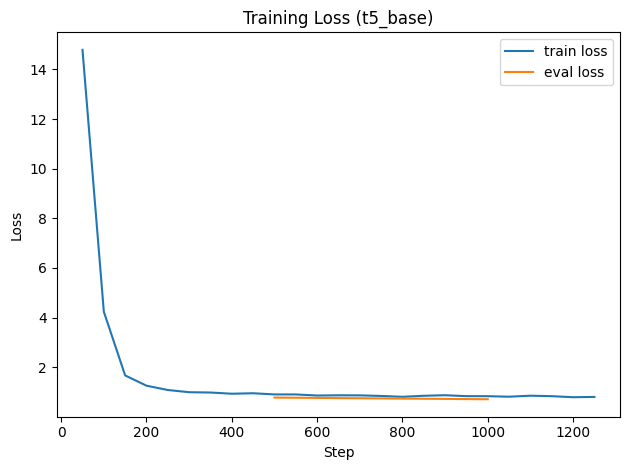

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_steps, eval_losses = [], []

for row in log_history:
    if "loss" in row and "step" in row:
        train_steps.append(row["step"])
        train_losses.append(row["loss"])
    if "eval_loss" in row and "step" in row:
        eval_steps.append(row["step"])
        eval_losses.append(row["eval_loss"])

plt.figure()
if train_steps:
    plt.plot(train_steps, train_losses, label="train loss")
if eval_steps:
    plt.plot(eval_steps, eval_losses, label="eval loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title(f"Training Loss ({run_key})")
plt.legend()
plt.tight_layout()
plt.savefig(f"training_loss_{run_key}.png", dpi=200)
plt.show()


In [ ]:
import json, os, time

repo_id = "UlyssesLynne/urban-planning-llm-model-zoo"
subdir  = "t5-base"  # you requested this folder name

run_stamp = time.strftime("%Y%m%d-%H%M%S")
local_run_dir = f"./hub_upload/{subdir}/{run_stamp}"
os.makedirs(local_run_dir, exist_ok=True)

# 1) trainer_stats
stats_path = os.path.join(local_run_dir, "trainer_stats.json")
with open(stats_path, "w") as f:
    json.dump(getattr(trainer_stats, "metrics", {}), f, indent=2)

# 2) store training args + your cfg snapshot (VERY useful later)
with open(os.path.join(local_run_dir, "training_args.json"), "w") as f:
    json.dump(trainer.args.to_dict(), f, indent=2)

# If you have cfg / EXPERIMENT dicts in memory, save them too:
# with open(os.path.join(local_run_dir, "experiment_config.json"), "w") as f:
#     json.dump(EXPERIMENT, f, indent=2, default=str)

print("Saved stats + args to:", local_run_dir)


Saved stats + args to: ./hub_upload/t5-base/20260317-192625


In [ ]:
teacher_metadata = {
    "teacher_model": teacher_base_model,
    "load_in_4bit": True,
    "max_seq_length": 512,
    "generation": {
        "do_sample": True,
        "temperature": 0,
        "top_p": 0.9,
        "repetition_penalty": 1.05,
        "max_new_tokens": 512
    }
}

with open(f"{local_run_dir}/teacher_metadata.json", "w") as f:
    json.dump(teacher_metadata, f, indent=2)


In [ ]:
# Save adapter + tokenizer
adapter_dir = os.path.join(local_run_dir, "adapter")
os.makedirs(adapter_dir, exist_ok=True)

model.save_pretrained(adapter_dir)      # saves adapter_model.safetensors + adapter_config.json (PEFT)
tokenizer.save_pretrained(adapter_dir)  # tokenizer files

print("Saved adapter to:", adapter_dir)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved adapter to: ./hub_upload/t5-base/20260317-192625/adapter


In [ ]:
from huggingface_hub import HfApi

DATASET_REPO = "UlyssesLynne/urban-planning-llm-teacher-paraphrases"

api = HfApi()
api.create_repo(DATASET_REPO, repo_type="dataset", exist_ok=True)


RepoUrl('https://huggingface.co/datasets/UlyssesLynne/urban-planning-llm-teacher-paraphrases', endpoint='https://huggingface.co', repo_type='dataset', repo_id='UlyssesLynne/urban-planning-llm-teacher-paraphrases')

In [ ]:
# =========================
# 0) Imports + paths
# =========================
import os, json, hashlib, shutil
from datasets import Dataset, DatasetDict, load_from_disk

BASE_DIR = "/content/data_cache"
RAW_DIR  = os.path.join(BASE_DIR, "splits_raw")
SFT_DIR  = os.path.join(BASE_DIR, "splits_with_sft_text")
TOK_DIR  = os.path.join(BASE_DIR, "tokenized_qwen_14b_MAXLEN512")  # optional
os.makedirs(BASE_DIR, exist_ok=True)


In [ ]:
import shutil

output_dir = trainer.args.output_dir
copy_out_dir = os.path.join(local_run_dir, "trainer_output_dir")

# Copy the directory (optional, can be big)
if os.path.isdir(output_dir):
    shutil.copytree(output_dir, copy_out_dir, dirs_exist_ok=True)
    print("Copied trainer output_dir to:", copy_out_dir)


Copied trainer output_dir to: ./hub_upload/qwen-14b/20260310-144340/trainer_output_dir


In [ ]:
from huggingface_hub import HfApi

api = HfApi()

api.upload_folder(
    repo_id=repo_id,
    folder_path=local_run_dir,
    path_in_repo=f"{subdir}/{run_stamp}",
    repo_type="model",
)

print(f"Uploaded to: {repo_id}/tree/main/{subdir}/{run_stamp}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter/model.safetensors:   0%|          |  553kB /  892MB            

Uploaded to: UlyssesLynne/urban-planning-llm-model-zoo/tree/main/t5-base/20260317-192625


In [ ]:
# =========================
# 1) Add stable IDs (recommended)
#    - ensures consistent tracking and merges later
# =========================
def add_stable_id(ds: Dataset, text_col: str = "prompt", id_col: str = "id") -> Dataset:
    def _add(batch):
        ids = []
        for t in batch[text_col]:
            t = "" if t is None else str(t)
            h = hashlib.sha1(t.encode("utf-8")).hexdigest()  # stable across sessions
            ids.append(h)
        return {id_col: ids}
    # avoid overwriting if already exists
    if id_col in ds.column_names:
        return ds
    return ds.map(_add, batched=True, desc=f"Adding {id_col}")

dataset_train = add_stable_id(dataset_train, "prompt", "id")
dataset_eval  = add_stable_id(dataset_eval,  "prompt", "id")
print(dataset_train.column_names)


Adding id:   0%|          | 0/10044 [00:00<?, ? examples/s]

Adding id:   0%|          | 0/1116 [00:00<?, ? examples/s]

['prompt', 'sft_text', 'id']


In [ ]:
# =========================
# 2) Save RAW splits (prompt + id only)
#    - model-agnostic, small, future-proof
# =========================
def keep_columns(ds: Dataset, cols):
    cols = [c for c in cols if c in ds.column_names]
    return ds.select_columns(cols)

raw_splits = DatasetDict({
    "train": keep_columns(dataset_train, ["id", "prompt"]),
    "eval":  keep_columns(dataset_eval,  ["id", "prompt"]),
})

# overwrite-safe save
if os.path.exists(RAW_DIR):
    shutil.rmtree(RAW_DIR)
raw_splits.save_to_disk(RAW_DIR)

print("Saved RAW splits to:", RAW_DIR)


Saving the dataset (0/1 shards):   0%|          | 0/10044 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1116 [00:00<?, ? examples/s]

Saved RAW splits to: /content/data_cache/splits_raw


In [ ]:
# =========================
# 3) Save SFT splits (id + prompt + sft_text)
#    - this avoids regenerating teacher paraphrases forever
# =========================
assert "sft_text" in dataset_train.column_names, "dataset_train must include 'sft_text' before saving."
assert "sft_text" in dataset_eval.column_names,  "dataset_eval must include 'sft_text' before saving."

sft_splits = DatasetDict({
    "train": keep_columns(dataset_train, ["id", "prompt", "sft_text"]),
    "eval":  keep_columns(dataset_eval,  ["id", "prompt", "sft_text"]),
})

if os.path.exists(SFT_DIR):
    shutil.rmtree(SFT_DIR)
sft_splits.save_to_disk(SFT_DIR)

print("Saved SFT splits to:", SFT_DIR)


Saving the dataset (0/1 shards):   0%|          | 0/10044 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1116 [00:00<?, ? examples/s]

Saved SFT splits to: /content/data_cache/splits_with_sft_text


In [ ]:
# =========================
# 4) (Optional) Save TOKENIZED splits
#    - only reuse if SAME tokenizer + MAX_LEN + label rules
# =========================
SAVE_TOKENIZED = True  # set False if you will train different model families/tokenizers

if SAVE_TOKENIZED:
    # expects you already created dataset_train_tok / dataset_eval_tok
    tok_splits = DatasetDict({
        "train": dataset_train_tok,
        "eval":  dataset_eval_tok,
    })
    if os.path.exists(TOK_DIR):
        shutil.rmtree(TOK_DIR)
    tok_splits.save_to_disk(TOK_DIR)
    print("Saved TOKENIZED splits to:", TOK_DIR)
else:
    print("Skipping tokenized cache.")


Saving the dataset (0/1 shards):   0%|          | 0/10044 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1116 [00:00<?, ? examples/s]

Saved TOKENIZED splits to: /content/data_cache/tokenized_qwen_14b_MAXLEN512


In [ ]:
# =========================
# 5) Save run metadata (helps reproducibility)
# =========================
META_PATH = os.path.join(BASE_DIR, "cache_metadata.json")

metadata = {
    "created_in": "google_colab",
    "raw_dir": RAW_DIR,
    "sft_dir": SFT_DIR,
    "tokenized_dir": TOK_DIR if SAVE_TOKENIZED else None,
    "max_len": 512,  # change if needed
    "notes": [
        "RAW splits: id+prompt only (model-agnostic).",
        "SFT splits: id+prompt+sft_text (teacher-generated, expensive).",
        "Tokenized splits: only reusable for same tokenizer+MAX_LEN."
    ],
}

with open(META_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print("Wrote metadata to:", META_PATH)


Wrote metadata to: /content/data_cache/cache_metadata.json


In [ ]:
# =========================
# 6) Zip everything for download
# =========================
ZIP_PATH = "/content/data_cache.zip"
if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

shutil.make_archive("/content/data_cache", "zip", BASE_DIR)
print("Created:", ZIP_PATH)


Created: /content/data_cache.zip


In [ ]:
# =========================
# 7) Download in Colab
# =========================
from google.colab import files
files.download(ZIP_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Post Training Testing

In [ ]:
# Test accuracy for short answer + upload predictions/metrics to HF

# --- set these ---
HF_PRED_REPO = "UlyssesLynne/urban-planning-llm-predictions"  # dataset repo
SPLIT_NAME   = "sa_pos"                                      # your split key
MODEL_SUBDIR = "qwen-7b/20260301-173946"                    # e.g. from adapter run
HF_TOKEN     = os.environ.get("HF_TOKEN")

# (optional) run metadata you want to appear in summary.json
EXTRA_SUMMARY = {
    "eval_type": "sa_pos_predict_eval",
    "notes": "SA positive split evaluation",
}

In [ ]:
import torch
from huggingface_hub import list_repo_files
from transformers import (
    AutoConfig,
    AutoTokenizer,
    AutoModel,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    AutoModelForMaskedLM,
)
from peft import PeftConfig, PeftModel

try:
    from unsloth import FastLanguageModel
    HAS_UNSLOTH = True
except Exception:
    HAS_UNSLOTH = False


def infer_family_from_model_type(model_type: str) -> str:
    model_type = (model_type or "").lower()

    if model_type in {"t5", "mt5", "bart", "pegasus"}:
        return "seq2seq"
    if model_type in {"bert", "roberta", "distilbert", "albert", "electra", "deberta", "deberta-v2"}:
        return "encoder_only"
    return "causal_lm"


def folder_file_list(repo_id: str, subfolder: str):
    files = list_repo_files(repo_id=repo_id, repo_type="model")
    return [f for f in files if f.startswith(subfolder + "/")]


def load_model_for_inference(
    repo_id: str,
    subfolder: str,
    *,
    max_seq_len: int = 512,
    load_in_4bit: bool = True,
    bert_mode: str = "mlm",  # "mlm" or "encoder"
):
    files = folder_file_list(repo_id, subfolder)

    has_adapter = any(f.endswith("adapter_config.json") for f in files)
    has_full_model = any(f.endswith("config.json") for f in files) and any(
        f.endswith(".safetensors") or f.endswith(".bin") for f in files
    )

    if not has_adapter and not has_full_model:
        raise ValueError(f"No loadable model files found under {repo_id}/{subfolder}")

    # -------------------------------------------------
    # Case 1: PEFT adapter folder
    # -------------------------------------------------
    if has_adapter:
        peft_cfg = PeftConfig.from_pretrained(repo_id, subfolder=subfolder)
        base_model_name = peft_cfg.base_model_name_or_path

        base_cfg = AutoConfig.from_pretrained(base_model_name)
        family = infer_family_from_model_type(base_cfg.model_type)

        tokenizer = AutoTokenizer.from_pretrained(base_model_name)
        if tokenizer.pad_token is None and tokenizer.eos_token is not None:
            tokenizer.pad_token = tokenizer.eos_token

        if family == "causal_lm":
            if HAS_UNSLOTH:
                base_model, tokenizer = FastLanguageModel.from_pretrained(
                    model_name=base_model_name,
                    max_seq_length=max_seq_len,
                    dtype=None,
                    load_in_4bit=load_in_4bit,
                )
                model = PeftModel.from_pretrained(base_model, repo_id, subfolder=subfolder)
                model = FastLanguageModel.for_inference(model)
            else:
                base_model = AutoModelForCausalLM.from_pretrained(base_model_name)
                model = PeftModel.from_pretrained(base_model, repo_id, subfolder=subfolder)

        elif family == "seq2seq":
            base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_name)
            model = PeftModel.from_pretrained(base_model, repo_id, subfolder=subfolder)

        elif family == "encoder_only":
            if bert_mode == "mlm":
                base_model = AutoModelForMaskedLM.from_pretrained(base_model_name)
            else:
                base_model = AutoModel.from_pretrained(base_model_name)
            model = PeftModel.from_pretrained(base_model, repo_id, subfolder=subfolder)

        else:
            raise ValueError(f"Unsupported family: {family}")

        model.eval()
        return model, tokenizer, {
            "load_type": "peft_adapter",
            "family": family,
            "base_model": base_model_name,
            "subfolder": subfolder,
        }

    # -------------------------------------------------
    # Case 2: full saved model folder
    # -------------------------------------------------
    cfg = AutoConfig.from_pretrained(repo_id, subfolder=subfolder)
    family = infer_family_from_model_type(cfg.model_type)

    tokenizer = AutoTokenizer.from_pretrained(repo_id, subfolder=subfolder)
    if tokenizer.pad_token is None and tokenizer.eos_token is not None:
        tokenizer.pad_token = tokenizer.eos_token

    if family == "causal_lm":
        model = AutoModelForCausalLM.from_pretrained(
            repo_id,
            subfolder=subfolder,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        )
    elif family == "seq2seq":
        model = AutoModelForSeq2SeqLM.from_pretrained(
            repo_id,
            subfolder=subfolder,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        )
    elif family == "encoder_only":
        if bert_mode == "mlm":
            model = AutoModelForMaskedLM.from_pretrained(
                repo_id,
                subfolder=subfolder,
                torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            )
        else:
            model = AutoModel.from_pretrained(
                repo_id,
                subfolder=subfolder,
                torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            )
    else:
        raise ValueError(f"Unsupported family: {family}")

    model.eval()
    if torch.cuda.is_available():
        model = model.to("cuda")

    return model, tokenizer, {
        "load_type": "full_model",
        "family": family,
        "base_model": None,
        "subfolder": subfolder,
    }

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

repo_id = "UlyssesLynne/urban-planning-llm-model-zoo"
subfolder = "qwen-7b/20260301-173946/adapter"

tokenizer = AutoTokenizer.from_pretrained(repo_id, subfolder=subfolder)
model = AutoModelForSeq2SeqLM.from_pretrained(
    repo_id,
    subfolder=subfolder,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

model.eval()
if torch.cuda.is_available():
    model = model.to("cuda")

ValueError: Unrecognized model in UlyssesLynne/urban-planning-llm-model-zoo. Should have a `model_type` key in its config.json.

In [ ]:
ZOO_REPO = "UlyssesLynne/urban-planning-llm-model-zoo"
ADAPTER_SUBFOLDER = "qwen-7b/20260301-173946/adapter"

BASE_MODEL = "unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit"
MAX_SEQ_LEN = 512

PRED_REPO_ID = "UlyssesLynne/urban-planning-llm-predictions"

In [ ]:
import torch
from unsloth import FastLanguageModel
from peft import PeftModel

ZOO_REPO = "UlyssesLynne/urban-planning-llm-model-zoo"
ADAPTER_SUBFOLDER = "qwen-7b/20260301-173946/adapter"

BASE_MODEL = "unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit"
MAX_SEQ_LEN = 512

PRED_REPO_ID = "UlyssesLynne/urban-planning-llm-predictions"
# derive folder name from ADAPTER_SUBFOLDER
MODEL_SUBDIR = make_model_subdir_from_adapter(ADAPTER_SUBFOLDER)


# 1) Load base model + tokenizer (must match adapter_config base_model_name_or_path)
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LEN,
    dtype=None,
    load_in_4bit=True,
)

# 2) Attach the LoRA adapter from the zoo repo subfolder
model = PeftModel.from_pretrained(
    base_model,
    ZOO_REPO,
    subfolder=ADAPTER_SUBFOLDER,
)

model.eval()
model = FastLanguageModel.for_inference(model)  # good practice for Unsloth


==((====))==  Unsloth 2026.6.3: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


In [ ]:
prompt = _build_generative_prompt(full_dataset["mc_task_def"], full_dataset["mc_pos"][0],"t5")

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
out = model.generate(
    **inputs,
    max_new_tokens=10,
    do_sample=False,
)

decoded = tokenizer.decode(out[0], skip_special_tokens=True).strip()
print(decoded)

Please select the correct option. Your answer must be a single letter (A, B, C, or D).
Fact: The highD dataset is collected from six drone-monitored German highways.
Question: Where was the highD dataset collected?
Options: (A) Urban streets in New York City (B) Six highway locations in Germany (C) Rural roads in France (D) Freeways in California
Answer: B
The correct answer is B because the fact


In [ ]:
mc_examples = full_dataset["mc_pos"][:10]
predictions = _predict_batch_generative(
    task_def=full_dataset["mc_task_def"],
    model=model,
    tokenizer=tokenizer,
    examples=mc_examples,
    max_new_tokens=128
)

print("First 10 Multiple Choice Predictions:")
for i, (example, pred) in enumerate(zip(mc_examples, predictions)):
    print(f"\n--- Example {i+1} ---")
    print(f"Question: {example['Question']}")
    print(f"Correct Output: {example['Output']}")
    print(f"Model Prediction: {pred}")

First 10 Multiple Choice Predictions:

--- Example 1 ---
Question: Where was the highD dataset collected?
Correct Output: B
Model Prediction: B

--- Example 2 ---
Question: How long is the total video footage in the highD dataset?
Correct Output: C
Model Prediction: C

--- Example 3 ---
Question: How many vehicle trajectories does the highD dataset contain?
Correct Output: D
Model Prediction: D

--- Example 4 ---
Question: What does a 25 Hz sampling rate mean for the highD dataset?
Correct Output: B
Model Prediction: B

--- Example 5 ---
Question: Which of the following is included in the highD dataset?
Correct Output: B
Model Prediction: B

--- Example 6 ---
Question: How was the highD dataset recorded?
Correct Output: C
Model Prediction: C

--- Example 7 ---
Question: For what type of road is the highD dataset most suitable?
Correct Output: C
Model Prediction: C

--- Example 8 ---
Question: What is the licensing model for the highD dataset?
Correct Output: B
Model Prediction: B

--- 

In [ ]:
# Test accuracy for multiple choice
total_accuracy, l1_accuracy, l2_accuracy = predict_all(model, tokenizer, full_dataset["mc_task_def"], full_dataset["mc_pos"], batch_size=64, max_new_tokens=64)
print(f"Total Accuracy: {total_accuracy * 100:.2f}%")
print(f"L1 Accuracy: {l1_accuracy * 100:.2f}%")
print(f"L2 Accuracy: {l2_accuracy * 100:.2f}%")

Total Accuracy: 95.71%
L1 Accuracy: 95.64%
L2 Accuracy: 95.93%


In [ ]:
res = predict_all_sa_and_upload(
    model,
    tokenizer,
    task_def=full_dataset["sa_task_def"],
    instructions=full_dataset["sa_pos"],
    split_name="sa_pos",
    hf_repo_id=HF_PRED_REPO,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=64,        # adjust if needed
    max_input_tokens=2048,    # adjust if needed
    bert_lang="en",
    bertscore_model_type=None,
    use_cache=True,
    hf_token=HF_TOKEN,
    commit_message=f"Add SA eval for {MODEL_SUBDIR}/{SPLIT_NAME}",
    extra_summary=EXTRA_SUMMARY,
    save_prompt_text=True,    # set False if you want smaller files
)

print(res["overall"])
print(res.get("level_1", {}))
print(res.get("level_2", {}))
print(res.get("level_3", {}))


Generating SA (sa_pos):   0%|          | 0/72 [00:00<?, ?it/s]

{'count': 4585, 'rouge': {'rouge1': 0.34624625886042804, 'rouge2': 0.1524839409688799, 'rougeL': 0.31962314906880945, 'rougeLsum': 0.3198793825464465}, 'bert_f1_avg': 0.8932446175209179}
{'count': 2550, 'rouge': {'rouge1': 0.46805335425636085, 'rouge2': 0.24084488750518968, 'rougeL': 0.4548987801512904, 'rougeLsum': 0.45493449114885937}, 'bert_f1_avg': 0.9134117180225896}
{'count': 1025, 'rouge': {'rouge1': 0.19033712538364977, 'rouge2': 0.040557350972861644, 'rougeL': 0.15642527274756396, 'rougeLsum': 0.1562482395328358}, 'bert_f1_avg': 0.8772729792827513}
{'count': 1010, 'rouge': {'rouge1': 0.19683346816171526, 'rouge2': 0.04429561872758178, 'rougeL': 0.14504606747090945, 'rougeLsum': 0.14518693567040855}, 'bert_f1_avg': 0.8585365275345226}


In [ ]:
res = predict_all_sa_and_upload(
    model,
    tokenizer,
    task_def=full_dataset["sa_task_def"],
    instructions=full_dataset["sa_neg"],
    split_name="sa_neg",
    hf_repo_id=HF_PRED_REPO,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=64,        # adjust if needed
    max_input_tokens=2048,    # adjust if needed
    bert_lang="en",
    bertscore_model_type=None,
    use_cache=True,
    hf_token=HF_TOKEN,
    commit_message=f"Add SA eval for {MODEL_SUBDIR}/{SPLIT_NAME}",
    extra_summary=EXTRA_SUMMARY,
    save_prompt_text=True,    # set False if you want smaller files
)

print(res["overall"])
print(res.get("level_1", {}))
print(res.get("level_2", {}))
print(res.get("level_3", {}))


Generating SA (sa_neg):   0%|          | 0/71 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rmbf4/predictions.parquet:  20%|##        |  126kB /  627kB            

{'count': 4500, 'rouge': {'rouge1': 0.012097277599420048, 'rouge2': 0.000709931413669361, 'rougeL': 0.010347016077346867, 'rougeLsum': 0.010391386692311374}, 'bert_f1_avg': 0.8115298702849282}
{'count': 2500, 'rouge': {'rouge1': 0.004288455832312573, 'rouge2': 6.902255639097744e-05, 'rougeL': 0.004119294162501845, 'rougeLsum': 0.004115034105957813}, 'bert_f1_avg': 0.8139251161813736}
{'count': 1000, 'rouge': {'rouge1': 0.016472863934343038, 'rouge2': 0.0008797895179563965, 'rougeL': 0.014397318436243811, 'rougeLsum': 0.014359361684734739}, 'bert_f1_avg': 0.8094455408453941}
{'count': 1000, 'rouge': {'rouge1': 0.02724334080915074, 'rouge2': 0.0021228516863167676, 'rougeL': 0.022005092777036748, 'rougeLsum': 0.02196086761164303}, 'bert_f1_avg': 0.807626072883606}


In [ ]:
res = predict_all_mc_explanation_paraphrases_and_upload(
    model,
    tokenizer,
    instructions=full_dataset["mc_pos"] + full_dataset["mc_neg"],
    task_definition=full_dataset["mc_task_def"],
    split_name="mc_all",
    hf_repo_id=HF_PRED_REPO,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=128,
    bert_lang="en",
    bertscore_device="cpu",
    use_cache=True,
    hf_token=HF_TOKEN,
    commit_message=f"MC explanation paraphrase eval: {MODEL_SUBDIR}/{SPLIT_NAME}",
    extra_summary={
        "run_kind": "fine_tuned_model",
        "split_source": "mc_pos + mc_neg",
    },
    save_prompt_text=True,
)

print(res["overall"])
print(res.get("level_1", {}))
print(res.get("level_2", {}))

print(f"Uploaded to: {HF_PRED_REPO} -> {MODEL_SUBDIR}/{SPLIT_NAME}/")

[DEBUG entry] split=mc_all
[DEBUG entry] model: T5ForConditionalGeneration device= cuda:0
[DEBUG entry] mode: seq2seq family: t5
[DEBUG entry] tokenizer: {'type': 'T5Tokenizer', 'name_or_path': 'UlyssesLynne/urban-planning-llm-model-zoo', 'id': 134379603703664}


Generating MC-Expl (mc_all):   0%|          | 0/205 [00:00<?, ?it/s]

[DEBUG batch 0/205] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 'UlyssesLynne/urban-planning-llm-model-zoo', 'id': 134379603703664}
[DEBUG batch 50/205] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 'UlyssesLynne/urban-planning-llm-model-zoo', 'id': 134379603703664}
[DEBUG batch 100/205] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 'UlyssesLynne/urban-planning-llm-model-zoo', 'id': 134379603703664}
[DEBUG batch 150/205] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 'UlyssesLynne/urban-planning-llm-model-zoo', 'id': 134379603703664}
[DEBUG batch 200/205] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 'UlyssesLynne/urban-planning-llm-model-zoo', 'id': 134379603703664}


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

  ...81pm6/predictions.parquet:   6%|6         | 95.1kB / 1.58MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ur81pm6/predictions.jsonl:  58%|#####7    | 18.2MB / 31.5MB            

[DEBUG done] tokenizer still: {'type': 'T5Tokenizer', 'name_or_path': 'UlyssesLynne/urban-planning-llm-model-zoo', 'id': 134379603703664}
{'count': 13075, 'rouge': {'rouge1': 0.15993100616200592, 'rouge2': 0.07080064773712513, 'rougeL': 0.12701220861924056, 'rougeLsum': 0.12696733188009998}, 'bert_f1_avg': 0.8559405962550162, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
{'count': 10050, 'rouge': {'rouge1': 0.15850042276949244, 'rouge2': 0.07883285751484043, 'rougeL': 0.12943805685002446, 'rougeLsum': 0.12948143280857688}, 'bert_f1_avg': 0.856706404626666, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
{'count': 3025, 'rouge': {'rouge1': 0.16476486652853234, 'rouge2': 0.044264172043331454, 'rougeL': 0.11884852644271718, 'rougeLsum': 0.11886446884796201}, 'bert_f1_avg': 0.853396344835108, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
Uploaded to: UlyssesLynne/urban-planning-llm-predictions -> t5-base/20260317-192625/sa_pos/


In [ ]:
PRED_REPO_ID = "UlyssesLynne/urban-planning-llm-predictions"
extra_meta = {
    "zoo_repo": ZOO_REPO,
    "adapter_subfolder": ADAPTER_SUBFOLDER,
    "base_model": BASE_MODEL,
    "max_seq_len": MAX_SEQ_LEN,
}

In [ ]:
res_pos = paraphrase_block_eval_batch_and_upload(
    model,
    tokenizer,
    reference_blocks=full_dataset["sa_pos"],
    split_name="sa_pos",
    split_type="sa_pos",
    hf_repo_id=PRED_REPO_ID,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=512,
    bert_lang="en",
    hf_token=HF_TOKEN,  # ok if None and you're already logged in
    extra_summary=extra_meta,
)
print("POS overall:", res_pos["overall"])
print("POS level_1:", res_pos.get("level_1"))
print("POS level_2:", res_pos.get("level_2"))
print("POS level_3:", res_pos.get("level_3"))

Generating (sa_pos):   0%|          | 0/72 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...4oocv/predictions.parquet:   6%|6         |  131kB / 2.10MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...xw4oocv/predictions.jsonl:  97%|#########6| 18.6MB / 19.2MB            

POS overall: {'count': 4585, 'rouge': {'rouge1': 0.4827907878964244, 'rouge2': 0.4493332490483084, 'rougeL': 0.47624398047975003, 'rougeLsum': 0.47998979166554623}, 'bert_f1_avg': 0.9017810313366231, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_1: {'count': 2550, 'rouge': {'rouge1': 0.39133903822395355, 'rouge2': 0.3609594793465454, 'rougeL': 0.3859189190641501, 'rougeLsum': 0.3890673079176666}, 'bert_f1_avg': 0.8855882153090309, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_2: {'count': 1025, 'rouge': {'rouge1': 0.5830579512881291, 'rouge2': 0.542275187464184, 'rougeL': 0.5759327879832409, 'rougeLsum': 0.5792440377965313}, 'bert_f1_avg': 0.9230130300289248, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_3: {'count': 1010, 'rouge': {'rouge1': 0.6125007717440688, 'rouge2': 0.5779202762398441, 'rougeL': 0.6030235529796815, 'rougeLsum': 0.608626326025767}, 'bert_f1_avg': 0.9211165535568011, 'bertscore_sanitize': {'empty_

In [ ]:
# NEGATIVE
res_neg = paraphrase_block_eval_batch_and_upload(
    model,
    tokenizer,
    reference_blocks=full_dataset["sa_neg"],
    split_name="sa_neg",
    split_type="sa_neg",
    hf_repo_id=PRED_REPO_ID,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=512,
    bert_lang="en",
    hf_token=HF_TOKEN,
    extra_summary=extra_meta,
)
print("NEG overall:", res_neg["overall"])
print("NEG level_1:", res_neg["level_1"])
print("NEG level_2:", res_neg["level_2"])
print("NEG level_3:", res_neg["level_3"])

Generating (sa_neg):   0%|          | 0/71 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...oxbyd/predictions.parquet:   8%|8         |  192kB / 2.29MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...06oxbyd/predictions.jsonl:  88%|########7 | 16.2MB / 18.4MB            

NEG overall: {'count': 4500, 'rouge': {'rouge1': 0.5135096567091274, 'rouge2': 0.4784547982167911, 'rougeL': 0.5074831239542696, 'rougeLsum': 0.5107588346365968}, 'bert_f1_avg': 0.9058396136363347, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
NEG level_1: {'count': 2500, 'rouge': {'rouge1': 0.4178974464055954, 'rouge2': 0.38452250887436124, 'rougeL': 0.41248025824391665, 'rougeLsum': 0.4157882172591947}, 'bert_f1_avg': 0.8880470810651779, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
NEG level_2: {'count': 1000, 'rouge': {'rouge1': 0.6169788713867344, 'rouge2': 0.5750961581551959, 'rougeL': 0.6113235629574844, 'rougeLsum': 0.6137118827449095}, 'bert_f1_avg': 0.9274048041701317, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
NEG level_3: {'count': 1000, 'rouge': {'rouge1': 0.6486843903487072, 'rouge2': 0.6153549467030982, 'rougeL': 0.6411625215768797, 'rougeLsum': 0.6455365144915375}, 'bert_f1_avg': 0.9287557546496391, 'bertscore_sanitize': {'empty

In [ ]:
# MC
res_neg = paraphrase_block_eval_batch_and_upload(
    model,
    tokenizer,
    reference_blocks=full_dataset["mc_pos"],
    split_name="mc_pos",
    split_type="mc_pos",
    hf_repo_id=PRED_REPO_ID,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=512,
    bert_lang="en",
    hf_token=HF_TOKEN,
    extra_summary=extra_meta,
)
print("MC overall:", res_neg["overall"])

Generating (mc_pos):   0%|          | 0/103 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...chlbp/predictions.parquet:  17%|#7        |  253kB / 1.48MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...archlbp/predictions.jsonl:  83%|########3 | 18.4MB / 22.1MB            

MC overall: {'count': 6575, 'rouge': {'rouge1': 0.5298755446389158, 'rouge2': 0.4809842416759663, 'rougeL': 0.509315673963934, 'rougeLsum': 0.5232302352434366}, 'bert_f1_avg': 0.912035250418993, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}


In [ ]:
print("MC Level1:", res_neg["level_1"])
print("MC Level2:", res_neg["level_2"])

MC Level1: {'count': 5050, 'rouge': {'rouge1': 0.5068625821449311, 'rouge2': 0.4569832876233597, 'rougeL': 0.48497931695739177, 'rougeLsum': 0.49997660360412643}, 'bert_f1_avg': 0.9077813656731407, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
MC Level2: {'count': 1525, 'rouge': {'rouge1': 0.6059996069436009, 'rouge2': 0.5608663861768683, 'rougeL': 0.5900507903775913, 'rougeLsum': 0.6006272546558563}, 'bert_f1_avg': 0.9261218855810948, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}


# Cross Regional

## Load Dataset

In [ ]:
import pandas as pd
# Metadata
data_folder = "/content/urban_planning_llm"
datasets = {
    "france_mobility_instructions": "france_mobility_instructions_final.json",
    "japan_mlit_instructions": "japan_mlit_instructions_final.json",
}
MODEL_REGISTRY = {
    "llama3": {
        "8b":  "meta-llama/Meta-Llama-3.1-8B-Instruct",
        "70b": "meta-llama/Meta-Llama-3.1-70B-Instruct",
    },
    "qwen": {
        "7b":  "Qwen/Qwen2.5-7B-Instruct",
        "14b": "Qwen/Qwen2.5-14B-Instruct",
    },
    "t5": {
        "base":  "t5-base",
        "large": "t5-large",
    },
    "bert": {
        "base":  "google-bert/bert-base-uncased",
        "large": "google-bert/bert-large-uncased",
    },
}

In [ ]:
# Read Instructions
import json

def read_instructions(file_path):
    with open(file_path, 'r') as file:
        instructions = json.load(file)
    return instructions["instructions"]

def get_instruction_list(file_path):
  instruction_list = read_instructions(file_path)
  mc_def = read_instructions(f"{data_folder}/{datasets['france_mobility_instructions']}")[0]["Task_Definition"]
  mc_pos = instruction_list[0]["Positive Example"]
  mc_neg = instruction_list[0]["Negative Example"]
  sa_def = read_instructions(f"{data_folder}/{datasets['france_mobility_instructions']}")[1]["Task_Definition"]
  sa_pos = instruction_list[1]["Positive Example"]
  sa_neg = instruction_list[1]["Negative Example"]

  return {"mc_task_def": mc_def, "mc_pos": mc_pos, "mc_neg": mc_neg, "sa_task_def": sa_def, "sa_pos":sa_pos, "sa_neg":sa_neg}

def read_all_instructions():
  result = []
  for i in datasets:
    result.append(get_instruction_list(f"{data_folder}/{datasets[i]}"))
  return result

def merge_instructions(json_list):
  mc_task_def = json_list[0]["mc_task_def"]
  sa_task_def = json_list[0]["sa_task_def"]

  mc_pos = []
  mc_neg = []
  sa_pos = []
  sa_neg = []

  for i in range(len(json_list)):
    mc_pos += json_list[i]["mc_pos"]
    mc_neg += json_list[i]["mc_neg"]
    sa_pos += json_list[i]["sa_pos"]
    sa_neg += json_list[i]["sa_neg"]
  return {
      "mc_task_def": mc_task_def,
      "sa_task_def": sa_task_def,
      "mc_pos": mc_pos,
      "mc_neg": mc_neg,
      "sa_pos": sa_pos,
      "sa_neg": sa_neg
  }


In [ ]:
json_list = read_all_instructions()
full_dataset = merge_instructions(json_list)

## Load Model

In [ ]:
# Test accuracy for short answer + upload predictions/metrics to HF

# --- set these ---
HF_PRED_REPO = "UlyssesLynne/urban-planning-llm-predictions"  # dataset repo
SPLIT_NAME   = "sa_pos"                                      # your split key
MODEL_SUBDIR = "llama3-8b/20260203-205511"                    # e.g. from adapter run
HF_TOKEN     = os.environ.get("HF_TOKEN")

# (optional) run metadata you want to appear in summary.json
EXTRA_SUMMARY = {
    "eval_type": "sa_pos_predict_eval",
    "notes": "SA positive split evaluation",
}

In [ ]:
import torch
from huggingface_hub import list_repo_files
from transformers import (
    AutoConfig,
    AutoTokenizer,
    AutoModel,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    AutoModelForMaskedLM,
)
from peft import PeftConfig, PeftModel

try:
    from unsloth import FastLanguageModel
    HAS_UNSLOTH = True
except Exception:
    HAS_UNSLOTH = False


def infer_family_from_model_type(model_type: str) -> str:
    model_type = (model_type or "").lower()

    if model_type in {"t5", "mt5", "bart", "pegasus"}:
        return "seq2seq"
    if model_type in {"bert", "roberta", "distilbert", "albert", "electra", "deberta", "deberta-v2"}:
        return "encoder_only"
    return "causal_lm"


def folder_file_list(repo_id: str, subfolder: str):
    files = list_repo_files(repo_id=repo_id, repo_type="model")
    return [f for f in files if f.startswith(subfolder + "/")]


def load_model_for_inference(
    repo_id: str,
    subfolder: str,
    *,
    max_seq_len: int = 512,
    load_in_4bit: bool = True,
    bert_mode: str = "mlm",  # "mlm" or "encoder"
):
    files = folder_file_list(repo_id, subfolder)

    has_adapter = any(f.endswith("adapter_config.json") for f in files)
    has_full_model = any(f.endswith("config.json") for f in files) and any(
        f.endswith(".safetensors") or f.endswith(".bin") for f in files
    )

    if not has_adapter and not has_full_model:
        raise ValueError(f"No loadable model files found under {repo_id}/{subfolder}")

    # -------------------------------------------------
    # Case 1: PEFT adapter folder
    # -------------------------------------------------
    if has_adapter:
        peft_cfg = PeftConfig.from_pretrained(repo_id, subfolder=subfolder)
        base_model_name = peft_cfg.base_model_name_or_path

        base_cfg = AutoConfig.from_pretrained(base_model_name)
        family = infer_family_from_model_type(base_cfg.model_type)

        tokenizer = AutoTokenizer.from_pretrained(base_model_name)
        if tokenizer.pad_token is None and tokenizer.eos_token is not None:
            tokenizer.pad_token = tokenizer.eos_token

        if family == "causal_lm":
            if HAS_UNSLOTH:
                base_model, tokenizer = FastLanguageModel.from_pretrained(
                    model_name=base_model_name,
                    max_seq_length=max_seq_len,
                    dtype=None,
                    load_in_4bit=load_in_4bit,
                )
                model = PeftModel.from_pretrained(base_model, repo_id, subfolder=subfolder)
                model = FastLanguageModel.for_inference(model)
            else:
                base_model = AutoModelForCausalLM.from_pretrained(base_model_name)
                model = PeftModel.from_pretrained(base_model, repo_id, subfolder=subfolder)

        elif family == "seq2seq":
            base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_name)
            model = PeftModel.from_pretrained(base_model, repo_id, subfolder=subfolder)

        elif family == "encoder_only":
            if bert_mode == "mlm":
                base_model = AutoModelForMaskedLM.from_pretrained(base_model_name)
            else:
                base_model = AutoModel.from_pretrained(base_model_name)
            model = PeftModel.from_pretrained(base_model, repo_id, subfolder=subfolder)

        else:
            raise ValueError(f"Unsupported family: {family}")

        model.eval()
        return model, tokenizer, {
            "load_type": "peft_adapter",
            "family": family,
            "base_model": base_model_name,
            "subfolder": subfolder,
        }

    # -------------------------------------------------
    # Case 2: full saved model folder
    # -------------------------------------------------
    cfg = AutoConfig.from_pretrained(repo_id, subfolder=subfolder)
    family = infer_family_from_model_type(cfg.model_type)

    tokenizer = AutoTokenizer.from_pretrained(repo_id, subfolder=subfolder)
    if tokenizer.pad_token is None and tokenizer.eos_token is not None:
        tokenizer.pad_token = tokenizer.eos_token

    if family == "causal_lm":
        model = AutoModelForCausalLM.from_pretrained(
            repo_id,
            subfolder=subfolder,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        )
    elif family == "seq2seq":
        model = AutoModelForSeq2SeqLM.from_pretrained(
            repo_id,
            subfolder=subfolder,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        )
    elif family == "encoder_only":
        if bert_mode == "mlm":
            model = AutoModelForMaskedLM.from_pretrained(
                repo_id,
                subfolder=subfolder,
                torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            )
        else:
            model = AutoModel.from_pretrained(
                repo_id,
                subfolder=subfolder,
                torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            )
    else:
        raise ValueError(f"Unsupported family: {family}")

    model.eval()
    if torch.cuda.is_available():
        model = model.to("cuda")

    return model, tokenizer, {
        "load_type": "full_model",
        "family": family,
        "base_model": None,
        "subfolder": subfolder,
    }

In [ ]:
# @title
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

repo_id = "UlyssesLynne/urban-planning-llm-model-zoo"
subfolder = "t5-base/20260317-192625/adapter"

tokenizer = AutoTokenizer.from_pretrained(repo_id, subfolder=subfolder)
model = AutoModelForSeq2SeqLM.from_pretrained(
    repo_id,
    subfolder=subfolder,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

model.eval()
if torch.cuda.is_available():
    model = model.to("cuda")

config.json:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.35k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

t5-base/20260317-192625/adapter/model.sa(…):   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/151 [00:00<?, ?B/s]

In [ ]:
ZOO_REPO = "UlyssesLynne/urban-planning-llm-model-zoo"
ADAPTER_SUBFOLDER = "llama3-8b/20260203-205511/adapter"

BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B-Instruct"
MAX_SEQ_LEN = 512

PRED_REPO_ID = "UlyssesLynne/urban-planning-llm-predictions"

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B-Instruct"
ZOO_REPO = "UlyssesLynne/urban-planning-llm-model-zoo"
ADAPTER_SUBFOLDER = "llama3-8b/20260203-205511/adapter"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
)

model = PeftModel.from_pretrained(
    base_model,
    ZOO_REPO,
    subfolder=ADAPTER_SUBFOLDER,
)

model.eval()

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

adapter_config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


llama3-8b/20260203-205511/adapter/adapte(…):   0%|          | 0.00/2.27G [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): ModulesToSaveWrapper(
          (original_module): Embedding(128256, 4096)
          (modules_to_save): ModuleDict(
            (default): Embedding(128256, 4096)
          )
        )
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): Para

In [ ]:
prompt = _build_generative_prompt(
    full_dataset["mc_task_def"],
    full_dataset["mc_pos"][0],
    "llama3"
)

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False,
        use_cache=True,
        pad_token_id=tokenizer.eos_token_id,
    )

decoded = tokenizer.decode(out[0], skip_special_tokens=True)
print(decoded)

Task definition:
You are given 4 answer options (associated with 'A', 'B', 'C', 'D'), out of which only one is correct. You need to answer the question by selecting the correct option. You should only answer with the choice letter, not the whole answer.
Fact: The Île-de-France Mobilités dataset is provided by the regional transportation authority in Paris.

Question: Who provides the dataset?
Choices: (A) Private company (B) Regional transportation authority in Paris (C) US government (D) University lab

Answer:
The best answer is B. (The regional transportation


In [ ]:
# @title
import torch
from unsloth import FastLanguageModel
from peft import PeftModel

ZOO_REPO = "UlyssesLynne/urban-planning-llm-model-zoo"
ADAPTER_SUBFOLDER = "llama3-8b/20260203-205511/adapter"

BASE_MODEL = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"
MAX_SEQ_LEN = 512

PRED_REPO_ID = "UlyssesLynne/urban-planning-llm-predictions"
# derive folder name from ADAPTER_SUBFOLDER
MODEL_SUBDIR = make_model_subdir_from_adapter(ADAPTER_SUBFOLDER)


# 1) Load base model + tokenizer (must match adapter_config base_model_name_or_path)
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LEN,
    dtype=None,
    load_in_4bit=True,
)

# 2) Attach the LoRA adapter from the zoo repo subfolder
model = PeftModel.from_pretrained(
    base_model,
    ZOO_REPO,
    subfolder=ADAPTER_SUBFOLDER,
)

model.eval()
model = FastLanguageModel.for_inference(model)  # good practice for Unsloth


==((====))==  Unsloth 2026.6.7: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


## Test

In [ ]:
prompt = _build_generative_prompt(full_dataset["mc_task_def"], full_dataset["mc_pos"][0],"llama3")

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
out = model.generate(
    **inputs,
    max_new_tokens=10,
    do_sample=False,
)

decoded = tokenizer.decode(out[0], skip_special_tokens=True).strip()
print(decoded)

Task definition:
You are given 4 answer options (associated with 'A', 'B', 'C', 'D'), out of which only one is correct. You need to answer the question by selecting the correct option. You should only answer with the choice letter, not the whole answer.
Fact: The Île-de-France Mobilités dataset is provided by the regional transportation authority in Paris.

Question: Who provides the dataset?
Choices: (A) Private company (B) Regional transportation authority in Paris (C) US government (D) University lab

Answer:
The best answer is B. I am the regional


In [ ]:
total_accuracy, l1_accuracy, l2_accuracy = predict_all(model, tokenizer, full_dataset["mc_task_def"], full_dataset["mc_pos"], batch_size=64, max_new_tokens=64)
print(f"Total Accuracy: {total_accuracy * 100:.2f}%")
print(f"L1 Accuracy: {l1_accuracy * 100:.2f}%")
print(f"L2 Accuracy: {l2_accuracy * 100:.2f}%")

Total Accuracy: 96.73%
L1 Accuracy: 96.73%
L2 Accuracy: 96.73%


In [ ]:
mc_examples = full_dataset["mc_pos"][:30]
predictions = _predict_batch_generative(
    task_def=full_dataset["mc_task_def"],
    model=model,
    tokenizer=tokenizer,
    examples=mc_examples,
    max_new_tokens=128, # Use a reasonable max_new_tokens for predictions
    verbose=True # Set verbose to True to see raw model outputs and extracted letters
)

print("First 10 Multiple Choice Predictions:")
for i, (example, pred) in enumerate(zip(mc_examples, predictions)):
    print(f"\n--- Example {i+1} ---")
    print(f"Question: {example['Question']}")
    print(f"Correct Output: {example['Output']}")
    print(f"Model Prediction: {pred}")

Input Prompt: 'Task definition:
You are given 4 answer options (associated with 'A', 'B', 'C', 'D'), out of which only one is correct. You need to answer the question by selecting the correct option. You should only answer with the choice letter, not the whole answer.
Fact: The Île-de-France Mobilités dataset is provided by the regional transportation authority in Paris.

Question: Who provides the dataset?
Choices: (A) Private company (B) Regional transportation authority in Paris (C) US government (D) University lab

Answer:
'
Raw output: 'The best answer is B. I am the regional transportation authority in Paris. I provide the dataset. I am the one who provides the data. I am the regional transportation agency in Paris. I provide the data. I am the transportation agency in Paris. I provide the data. I am the transportation agency in Paris. I provide the data. I am the transportation agency in Paris. I provide the data. I am the transportation agency in Paris. I provide the data. I am

In [ ]:
sa_examples = full_dataset["sa_pos"][:10]
predictions_sa = _predict_batch_generative(
    task_def=full_dataset["sa_task_def"],
    model=model,
    tokenizer=tokenizer,
    examples=sa_examples,
    max_new_tokens=128, # Use a reasonable max_new_tokens for predictions
    verbose=True # Set verbose to True to see raw model outputs and extracted letters
)

print("\nFirst 10 Short Answer Predictions:")
for i, (example, pred) in enumerate(zip(sa_examples, predictions_sa)):
    print(f"\n--- Example {i+1} ---")
    print(f"Question: {example['Question']}")
    print(f"Correct Output: {example['Output']}")
    print(f"Model Prediction: {pred}")

KeyError: 'Selections'

In [ ]:
PRED_REPO_ID = "UlyssesLynne/urban-planning-llm-predictions"
extra_meta = {
    "zoo_repo": ZOO_REPO,
    "adapter_subfolder": ADAPTER_SUBFOLDER,
    "base_model": BASE_MODEL,
    "max_seq_len": 512,
}

In [ ]:
extra_meta

{'zoo_repo': 'UlyssesLynne/urban-planning-llm-model-zoo',
 'adapter_subfolder': 'llama3-8b/20260203-205511/adapter',
 'base_model': 'unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit',
 'max_seq_len': 512}

In [ ]:
res_pos = paraphrase_block_eval_batch_and_upload(
    model,
    tokenizer,
    reference_blocks=full_dataset["sa_pos"],
    split_name="sa_pos_cross_regional",
    split_type="sa_pos_cross_regional",
    hf_repo_id=PRED_REPO_ID,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=512,
    bert_lang="en",
    hf_token=HF_TOKEN,  # ok if None and you're already logged in
    extra_summary=extra_meta,
)
print("POS overall:", res_pos["overall"])
print("POS level_1:", res_pos.get("level_1"))
print("POS level_2:", res_pos.get("level_2"))
print("POS level_3:", res_pos.get("level_3"))

Generating (sa_pos_cross_regional):   0%|          | 0/23 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...c276x/predictions.parquet:  18%|#7        | 92.9kB /  521kB            

POS overall: {'count': 1438, 'rouge': {'rouge1': 0.07334270137691487, 'rouge2': 0.03132862085806683, 'rougeL': 0.0627202498609437, 'rougeLsum': 0.07025875750245697}, 'bert_f1_avg': 0.7793177889351719, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_1: {'count': 1018, 'rouge': {'rouge1': 0.06648590838293, 'rouge2': 0.02716868535545614, 'rougeL': 0.05704065564631482, 'rougeLsum': 0.06375612866094697}, 'bert_f1_avg': 0.7751095595903154, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_2: {'count': 410, 'rouge': {'rouge1': 0.09123121971296339, 'rouge2': 0.04224110360762911, 'rougeL': 0.07762056771893194, 'rougeLsum': 0.08789437331690575}, 'bert_f1_avg': 0.7903073637950712, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
POS level_3: {'count': 10, 'rouge': {'rouge1': 0.020207789690675673, 'rouge2': 0.0057007913667953426, 'rougeL': 0.016905329442907464, 'rougeLsum': 0.018482933168456207}, 'bert_f1_avg': 0.7571429669857025, 'bertscore_saniti

In [ ]:
# MC
res_neg = paraphrase_block_eval_batch_and_upload(
    model,
    tokenizer,
    reference_blocks=full_dataset["mc_pos"],
    split_name="mc_pos_cross_regional",
    split_type="mc_pos_cross_regional",
    hf_repo_id=PRED_REPO_ID,
    model_subdir=MODEL_SUBDIR,
    batch_size=64,
    max_new_tokens=512,
    bert_lang="en",
    hf_token=HF_TOKEN,
    extra_summary=extra_meta,
)
print("MC overall:", res_neg["overall"])
print("MC Level1:", res_neg["level_1"])
print("MC Level2:", res_neg["level_2"])

Generating (mc_pos_cross_regional):   0%|          | 0/40 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...cvegu/predictions.parquet:   4%|4         | 46.5kB / 1.14MB            

MC overall: {'count': 2508, 'rouge': {'rouge1': 0.16923052614414466, 'rouge2': 0.10396582464882882, 'rougeL': 0.1487677131841426, 'rougeLsum': 0.1633140133469015}, 'bert_f1_avg': 0.8291613694393274, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
MC Level1: {'count': 2018, 'rouge': {'rouge1': 0.16912528563655296, 'rouge2': 0.10542263738021684, 'rougeL': 0.14904563125655698, 'rougeLsum': 0.16294868205490443}, 'bert_f1_avg': 0.828692173845586, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}
MC Level2: {'count': 490, 'rouge': {'rouge1': 0.16956416132082563, 'rouge2': 0.09772161193697179, 'rougeL': 0.1475891263007667, 'rougeLsum': 0.16469977772068908}, 'bert_f1_avg': 0.8310936890086349, 'bertscore_sanitize': {'empty_preds': 0, 'empty_refs': 0}}


# Check resuls

In [ ]:
import pandas as pd
from huggingface_hub import hf_hub_download
from typing import Optional, Dict, Any


def load_predictions_parquet_from_hf(
    *,
    repo_id: str,
    model_subdir: str,
    run_id: str,
    split_name: str,
    hf_token: Optional[str] = None,
) -> pd.DataFrame:
    """
    Loads:
      llama3-8b/20260203-205511/mc_all/predictions.parquet
    """
    path_in_repo = (
        f"{model_subdir.strip('/')}/"
        f"{run_id.strip('/')}/"
        f"{split_name.strip('/')}/"
        f"predictions.parquet"
    )

    local_path = hf_hub_download(
        repo_id=repo_id,
        filename=path_in_repo,
        repo_type="dataset",
        token=hf_token,
    )

    return pd.read_parquet(local_path)



In [ ]:
df = load_predictions_parquet_from_hf(
    repo_id="UlyssesLynne/urban-planning-llm-predictions",
    model_subdir="qwen-14b",
    run_id="20260310-144340",
    split_name="mc_pos_cross_regional",
)

print(df.shape)
print(df.columns)


qwen-14b/20260310-144340/mc_pos_cross_re(…):   0%|          | 0.00/1.14M [00:00<?, ?B/s]

(2508, 16)
Index(['i', 'Level', 'Fact', 'Question', 'Output', 'Explanation',
       'reference_block', 'prompt', 'prediction', 'rouge1', 'rouge2', 'rougeL',
       'rougeLsum', 'bert_precision', 'bert_recall', 'bert_f1'],
      dtype='object')


In [ ]:
df.head()

,i,Level,Fact,Question,Output,Explanation,reference_block,prompt,prediction,rouge1,rouge2,rougeL,rougeLsum,bert_precision,bert_recall,bert_f1
0,0,1,The Île-de-France Mobilités dataset is provide...,Who provides the dataset?,B,The dataset is released by the regional transp...,Fact: The Île-de-France Mobilités dataset is p...,Paraphrase the following instruction block.\nP...,Fact: The dataset for transportation in the re...,0.177778,0.138393,0.168889,0.177778,0.812988,0.858229,0.834996
1,1,1,The dataset covers the Paris metropolitan region.,What is the spatial coverage of the dataset?,B,It focuses on the Paris region.,Fact: The dataset covers the Paris metropolita...,Paraphrase the following instruction block.\nP...,Fact: The dataset encompasses the area around ...,0.161137,0.076190,0.146919,0.156398,0.800390,0.851566,0.825185
2,2,1,The dataset includes daily and hourly passenge...,What is the temporal coverage of the dataset?,B,It includes temporal records at multiple granu...,Fact: The dataset includes daily and hourly pa...,Paraphrase the following instruction block.\nP...,Fact: The dataset contains details on passenge...,0.143498,0.054054,0.125561,0.130045,0.797712,0.845849,0.821075
3,3,1,Passenger counts are recorded per station and ...,What is the measurement resolution?,B,Data is measured at station-level resolution.,Fact: Passenger counts are recorded per statio...,Paraphrase the following instruction block.\nP...,Fact: The number of passengers is tracked for ...,0.114537,0.030973,0.092511,0.114537,0.764130,0.897623,0.825515
4,4,1,The dataset defines variables such as passenge...,Which variable is included?,B,Passenger count is a core variable.,Fact: The dataset defines variables such as pa...,Paraphrase the following instruction block.\nP...,The dataset contains variables like passenger ...,0.148796,0.092308,0.131291,0.144420,0.782375,0.898967,0.836628


In [ ]:
metrics_cols = ['rouge1', 'rouge2', 'rougeL', 'rougeLsum', 'bert_precision', 'bert_recall', 'bert_f1']
df_grouped = df.groupby('Level')[metrics_cols].mean().reset_index()
display(df_grouped)

print("\nOverall Averages:")
df_overall_avg = df[metrics_cols].mean().to_frame().T
display(df_overall_avg)

,Level,rouge1,rouge2,rougeL,rougeLsum,bert_precision,bert_recall,bert_f1
0,1,0.236272,0.177923,0.218330,0.231193,0.790604,0.890718,0.837462
1,2,0.226235,0.141923,0.197285,0.219000,0.792049,0.883332,0.835003



Overall Averages:


,rouge1,rouge2,rougeL,rougeLsum,bert_precision,bert_recall,bert_f1
0,0.234311,0.17089,0.214218,0.228811,0.790887,0.889275,0.836982


In [ ]:
df.iloc[0]["prediction"]

'Fact: The dataset for transportation in the region of Paris is supplied by the local transportation management.\nQuestion: Which organization offers this dataset?\nChoices: \nA. Private company\nB. Local transportation management in the Paris area\nC. US government\nD. University lab\nAnswer: B\nExplanation: This dataset originates from the regional transportation authority. \n\nNote: I\'ve made minor adjustments to the wording while keeping the core message intact. The choices have been slightly rephrased but maintain their original intent. The answer remains as "B" in both cases. The explanation has been altered to match the new phrasing used in the question. However, it still accurately reflects the source of the dataset. Please let me know if you would like me to modify anything further! \n\nPlease note that the original answer "B" corresponds to "Regional transportation authority in Paris", so I kept it consistent with the original choices provided. If you prefer a more precise m

In [ ]:
import math
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification


def add_bert_classifier_scores(
    df: pd.DataFrame,
    reference_col: str = "reference_block",
    prediction_col: str = "prediction",
    model_name: str = "roberta-large-mnli",
    batch_size: int = 8,
    max_length: int = 512,
):
    """
    Compare df[reference_col] vs df[prediction_col] row by row using a
    sentence-pair classifier, and add a new column:
        - bert_cls_score

    Score = entailment probability from roberta-large-mnli.

    Returns:
        df_out: dataframe with bert_cls_score column
        overall_avg: float
    """

    # Basic checks
    if reference_col not in df.columns:
        raise ValueError(f"Missing column: {reference_col}")
    if prediction_col not in df.columns:
        raise ValueError(f"Missing column: {prediction_col}")

    # Device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Load model/tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.to(device)
    model.eval()

    # Convert to safe strings
    refs = df[reference_col].fillna("").astype(str).tolist()
    preds = df[prediction_col].fillna("").astype(str).tolist()

    all_scores = []

    # Batch inference
    num_batches = math.ceil(len(df) / batch_size)

    for batch_idx in range(num_batches):
        start = batch_idx * batch_size
        end = min(start + batch_size, len(df))

        batch_refs = refs[start:end]
        batch_preds = preds[start:end]

        inputs = tokenizer(
            batch_refs,
            batch_preds,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        ).to(device)

        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1)

        # roberta-large-mnli label order:
        # 0 = contradiction
        # 1 = neutral
        # 2 = entailment
        entailment_scores = probs[:, 2].detach().cpu().tolist()
        all_scores.extend(entailment_scores)

        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == num_batches:
            print(f"Processed {end}/{len(df)} rows")

    # Attach results
    df_out = df.copy()
    df_out["bert_cls_score"] = all_scores

    # Overall average
    overall_avg = float(sum(all_scores) / max(len(all_scores), 1))

    print(f"\nOverall average bert_cls_score: {overall_avg:.6f}")

    return df_out, overall_avg

In [ ]:
df_scored, bert_cls_avg = add_bert_classifier_scores(
    df,
    reference_col="reference_block",
    prediction_col="prediction",
    model_name="roberta-large-mnli",
    batch_size=8,
    max_length=512,
)

print(df_scored[["reference_block", "prediction", "bert_cls_score"]].head())
print("Overall average:", bert_cls_avg)

Using device: cuda


config.json:   0%|          | 0.00/688 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Processed 80/13075 rows
Processed 160/13075 rows
Processed 240/13075 rows
Processed 320/13075 rows
Processed 400/13075 rows
Processed 480/13075 rows
Processed 560/13075 rows
Processed 640/13075 rows
Processed 720/13075 rows
Processed 800/13075 rows
Processed 880/13075 rows
Processed 960/13075 rows
Processed 1040/13075 rows
Processed 1120/13075 rows
Processed 1200/13075 rows
Processed 1280/13075 rows
Processed 1360/13075 rows
Processed 1440/13075 rows
Processed 1520/13075 rows
Processed 1600/13075 rows
Processed 1680/13075 rows
Processed 1760/13075 rows
Processed 1840/13075 rows
Processed 1920/13075 rows
Processed 2000/13075 rows
Processed 2080/13075 rows
Processed 2160/13075 rows
Processed 2240/13075 rows
Processed 2320/13075 rows
Processed 2400/13075 rows
Processed 2480/13075 rows
Processed 2560/13075 rows
Processed 2640/13075 rows
Processed 2720/13075 rows
Processed 2800/13075 rows
Processed 2880/13075 rows
Processed 2960/13075 rows
Processed 3040/13075 rows
Processed 3120/13075 rows

In [ ]:
print(df["reference_block"][0])

Fact: The highD dataset is collected from six drone-monitored German highways.
Question: Where was the highD dataset collected?
Choices: {'A': 'Urban streets in New York City', 'B': 'Six highway locations in Germany', 'C': 'Rural roads in France', 'D': 'Freeways in California'}
Output: B
Explanation: The highD dataset was collected from six drone-monitored German highways.



In [ ]:
from typing import Optional, Tuple
def high_bert_low_rouge(
    df: pd.DataFrame,
    *,
    bert_key: str = "bert_f1",
    rouge_key: str = "rougeLsum",
    bert_min: float = 0.90,
    rouge_max: float = 0.25,
    level_col: str = "Level",
    top_k: int = 50,
    sort_by: Tuple[str, str] = ("bert_f1", "rougeLsum"),
) -> pd.DataFrame:
    """
    Returns examples with:
      bert_key >= bert_min AND rouge_key <= rouge_max
    Sorted by (high bert, low rouge) by default.
    """
    for col in [bert_key, rouge_key]:
        if col not in df.columns:
            raise KeyError(f"Missing column '{col}' in df")

    sub = df[
        (df[bert_key].astype(float) >= float(bert_min))
        & (df[rouge_key].astype(float) <= float(rouge_max))
    ].copy()

    # default: highest bert first, lowest rouge first
    sub = sub.sort_values(list(sort_by), ascending=[False, True])

    # helpful derived columns
    sub["bert_minus_rouge"] = sub[bert_key].astype(float) - sub[rouge_key].astype(float)

    # keep a compact view (keep extra cols if you want)
    cols = [c for c in [
        "i", level_col, bert_key, rouge_key, "bert_minus_rouge",
        "Question", "Fact", "Output", "Explanation",
        "reference_block", "reference_explanation",
        "prediction", "prompt",
    ] if c in sub.columns]

    return sub[cols].head(int(top_k))

In [ ]:
view = high_bert_low_rouge(
    df,
    bert_min=0.80,
    rouge_max=0.10,
    top_k=30,
)

view.head()

,i,Level,bert_f1,rougeLsum,bert_minus_rouge,Question,Fact,Output,Explanation,reference_block,prediction,prompt
6811,6811,1,0.812323,0.091533,0.720790,The highD dataset consists of how many recorde...,"The highD dataset contains over 110,000 vehicl...",B,"The highD dataset contains in excess of 110,00...","Fact: The highD dataset contains over 110,000 ...","The highD dataset contains more than 110,000 d...",Paraphrase the following instruction block.\nP...
6812,6812,1,0.812323,0.091533,0.720790,The highD dataset consists of how many recorde...,"The highD dataset contains over 110,000 vehicl...",B,"The highD dataset contains in excess of 110,00...","Fact: The highD dataset contains over 110,000 ...","The highD dataset contains more than 110,000 d...",Paraphrase the following instruction block.\nP...
1704,1704,1,0.806284,0.090909,0.715375,The NGSIM data fields contain which of the fol...,"The NGSIM dataset includes vehicle positions, ...",C,NGSIM primarily contains detailed data on vehi...,Fact: The NGSIM dataset includes vehicle posit...,The NGSIM dataset contains detailed informatio...,Paraphrase the following instruction block.\nP...
1705,1705,1,0.806284,0.090909,0.715375,The NGSIM data fields contain which of the fol...,"The NGSIM dataset includes vehicle positions, ...",C,NGSIM primarily contains detailed data on vehi...,Fact: The NGSIM dataset includes vehicle posit...,The NGSIM dataset contains detailed informatio...,Paraphrase the following instruction block.\nP...
1694,1694,1,0.804870,0.095238,0.709632,The NGSIM data fields contain which of the fol...,"The NGSIM dataset includes vehicle positions, ...",C,NGSIM is centered on precise vehicle trajector...,Fact: The NGSIM dataset includes vehicle posit...,The NGSIM dataset contains information about t...,Paraphrase the following instruction block.\nP...


In [ ]:
view.iloc[3]["prediction"]

'The NGSIM dataset contains detailed information about the vehicles, including the lane each vehicle is in.\nThe best answer is C. I believe the following is true about the NGSIM dataset.\nThe best answer is C. The NGSIM dataset contains detailed information about the vehicles, including the lane each vehicle is in.\nThe best answer is C. The NGSIM dataset contains detailed information about the vehicles, including the lane each vehicle is in.\nThe best answer is C. The NGSIM dataset contains detailed information about the vehicles, including the lane each vehicle is in.\nThe best answer is C. The NGSIM dataset contains detailed information about the vehicles, including the lane each vehicle is in.\nThe best answer is C. The NGSIM dataset contains detailed information about the vehicles, including the lane each vehicle is in.\nThe best answer is C. The NGSIM dataset contains detailed information about the vehicles, including the lane each vehicle is in.\nThe best answer is C. The NGSIM

In [ ]:
from google.colab import files
uploaded = files.upload()  # choose your zip file, e.g. llama3_8b_run.zip


Saving data_cache.zip to data_cache.zip


In [ ]:
import os, zipfile

# Change this to the uploaded filename if needed
ZIP_NAME = next(iter(uploaded.keys()))
UNZIP_DIR = "/content/unzipped_run"

os.makedirs(UNZIP_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_NAME, "r") as z:
    z.extractall(UNZIP_DIR)

print("Unzipped to:", UNZIP_DIR)

# Quick peek
for root, dirs, files_ in os.walk(UNZIP_DIR):
    if "adapter_config.json" in files_:
        print("Found adapter here:", root)
        break


Unzipped to: /content/unzipped_run


In [ ]:
import os

def find_adapter_dir(root: str) -> str:
    for r, d, f in os.walk(root):
        if "adapter_config.json" in f:
            return r
    raise FileNotFoundError("Could not find adapter_config.json in the unzipped directory.")

ADAPTER_DIR = find_adapter_dir(UNZIP_DIR)
print("ADAPTER_DIR =", ADAPTER_DIR)

# sanity check
print("Files in adapter dir:", os.listdir(ADAPTER_DIR)[:20])


FileNotFoundError: Could not find adapter_config.json in the unzipped directory.

In [ ]:
import os

os.makedirs("graphs", exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np

models = ["T5-base", "Qwen2.5-7B", "Qwen2.5-14B", "LLaMA3-8B", "LLaMA3-70B"]

# ------------------------
# Figure 1: MC Accuracy
# ------------------------
mc_pre  = [0.00, 99.97, 100.00, 90.34, 93.03]
mc_post = [0.00, 100.00, 100.00, 95.71, 97.34]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, mc_pre, width, label="Pre")
plt.bar(x + width/2, mc_post, width, label="Post")

plt.ylabel("Accuracy (%)")
plt.xticks(x, models, rotation=15)
plt.legend()
plt.tight_layout()

# Optional: zoomed axis so improvements are visible
plt.ylim(85, 101)

plt.savefig("graphs/mc_accuracy_1.png", dpi=300, bbox_inches="tight")
plt.close()


# ------------------------
# Figure 2: SA BERTScore
# ------------------------
sa_pre  = [0.82, 0.88, 0.90, 0.85, 0.93]
sa_post = [0.90, 0.90, 0.91, 0.90, 0.90]

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, sa_pre, width, label="Pre")
plt.bar(x + width/2, sa_post, width, label="Post")

plt.ylabel("BERTScore F1")
plt.xticks(x, models, rotation=15)
plt.legend()
plt.tight_layout()

# Optional: zoomed axis for visibility
plt.ylim(0.75, 0.95)

plt.savefig("graphs/sa_bert_1.png", dpi=300, bbox_inches="tight")
plt.close()